In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# PROJECT PATHS
# ------------------------------------------------------------

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data" / "raw"
TABLES_DIR = PROJECT_ROOT / "tables1"
FIGURES_DIR = PROJECT_ROOT / "figures1"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root :", PROJECT_ROOT)
print("Data dir     :", DATA_DIR)
print("Tables dir   :", TABLES_DIR)
print("Figures dir  :", FIGURES_DIR)

Project root : C:\Users\shafi\number-simplex-reproduction
Data dir     : C:\Users\shafi\number-simplex-reproduction\data\raw
Tables dir   : C:\Users\shafi\number-simplex-reproduction\tables1
Figures dir  : C:\Users\shafi\number-simplex-reproduction\figures1


In [3]:
# ------------------------------------------------------------
# LOAD EXISTING SINGLE-NEURON RESULTS
# ------------------------------------------------------------

single = pd.read_csv(
    TABLES_DIR / "figure1M_all_neuron_permutations.csv"
)

print("Shape:", single.shape)
print()
print(single.columns.tolist())
print()
display(single.head())

Shape: (552, 16)

['subject', 'neuron', 'region', 'FR_accuracy', 'TC_accuracy', 'best_bin_ms', 'best_gamma', 'n_presentations', 'n_splits', 'FR_null_mean', 'FR_p', 'FR_coding', 'TC_null_mean', 'TC_p', 'TC_coding', 'elapsed_seconds']



,subject,neuron,region,FR_accuracy,TC_accuracy,best_bin_ms,best_gamma,n_presentations,n_splits,FR_null_mean,FR_p,FR_coding,TC_null_mean,TC_p,TC_coding,elapsed_seconds
0,YFF,9,ent,0.100917,0.165138,180,0.2,109,7,0.106376,0.646766,False,0.105092,0.059701,False,12.667940
1,YFF,10,hpc,0.091743,0.155963,90,0.2,109,7,0.106881,0.731343,False,0.109266,0.094527,False,11.077304
2,YFF,11,hpc,0.110092,0.201835,100,0.5,109,7,0.109404,0.532338,False,0.107248,0.019900,True,10.417088
3,YFF,12,hpc,0.100917,0.174312,300,0.5,109,7,0.110459,0.641791,False,0.108165,0.049751,True,11.636312
4,YFF,13,hpc,0.146789,0.155963,100,0.8,109,7,0.104771,0.159204,False,0.113257,0.139303,False,11.468347


In [4]:
from itertools import combinations

# ------------------------------------------------------------
# SELECT ONE SUBJECT
# ------------------------------------------------------------

subject = "YFF"

subject_neurons = (
    single.loc[single["subject"] == subject, "neuron"]
    .astype(int)
    .sort_values()
    .to_list()
)

n_neurons = len(subject_neurons)

print("Subject:", subject)
print("Number of neurons:", n_neurons)
print("Neuron IDs:")
print(subject_neurons)

# ------------------------------------------------------------
# ALL UNIQUE UNORDERED PAIRS
# ------------------------------------------------------------

pairs = list(combinations(subject_neurons, 2))

print()
print("Number of unique pairs:", len(pairs))
print("Expected:", n_neurons * (n_neurons - 1) // 2)

print()
print("First 10 pairs:")
print(pairs[:10])

Subject: YFF
Number of neurons: 37
Neuron IDs:
[9, 10, 11, 12, 13, 14, 15, 16, 17, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54]

Number of unique pairs: 666
Expected: 666

First 10 pairs:
[(9, 10), (9, 11), (9, 12), (9, 13), (9, 14), (9, 15), (9, 16), (9, 17), (9, 27), (9, 28)]


In [5]:
37*36


1332

In [6]:
1332/2

666.0

In [5]:
pair_df = pd.DataFrame(
    pairs,
    columns=["neuron_1", "neuron_2"]
)

pair_df.insert(0, "subject", subject)

print("Pair table shape:", pair_df.shape)

display(pair_df.head(10))
display(pair_df.tail(10))

Pair table shape: (666, 3)


,subject,neuron_1,neuron_2
0,YFF,9,10
1,YFF,9,11
2,YFF,9,12
3,YFF,9,13
4,YFF,9,14
5,YFF,9,15
6,YFF,9,16
7,YFF,9,17
8,YFF,9,27
9,YFF,9,28


,subject,neuron_1,neuron_2
656,YFF,50,51
657,YFF,50,52
658,YFF,50,53
659,YFF,50,54
660,YFF,51,52
661,YFF,51,53
662,YFF,51,54
663,YFF,52,53
664,YFF,52,54
665,YFF,53,54


In [6]:
import inspect
import src.number_decoding_analysis as nda

print([
    name for name, obj in inspect.getmembers(nda, inspect.isfunction)
    if not name.startswith("_")
])

['analyze_neuron', 'analyze_number_decoding', 'cv_lda_accuracy', 'cv_lda_per_number_accuracy', 'fit_temporal_components', 'make_firing_rate_features', 'make_temporal_features', 'permutation_test', 'permutation_test_decoding', 'plot_figure_g', 'plot_figure_h', 'plot_null_distribution', 'temporal_grid_search']


In [7]:
import inspect
from src.number_decoding_analysis import (
    make_firing_rate_features,
    make_temporal_features
)

print("========== FIRING RATE ==========")
print(inspect.signature(make_firing_rate_features))
print(inspect.getsource(make_firing_rate_features))

print("\n========== TEMPORAL ==========")
print(inspect.signature(make_temporal_features))
print(inspect.getsource(make_temporal_features))

========== FIRING RATE ==========
(presentations, spike_times, window_start=50, window_end=950)
def make_firing_rate_features(
    presentations,
    spike_times,
    window_start=ARITH_START_MS,
    window_end=ARITH_END_MS,
):
    """
    One whole-window spike-count feature per presentation.

    X shape:
        n_presentations x 1

    Dividing by 0.9 s would convert this to Hz, but that constant
    scaling does not change LDA classification.
    """

    X = []
    y = []

    for _, row in presentations.iterrows():

        onset = float(row["onset"])
        number = int(row["number"])

        relative_spikes = spike_times - onset

        count = np.sum(
            (relative_spikes >= window_start)
            &
            (relative_spikes < window_end)
        )

        X.append([count])
        y.append(number)

    return (
        np.asarray(X, dtype=float),
        np.asarray(y, dtype=int),
    )


========== TEMPORAL ==========
(presentations, spike_times, bin_size, 

In [8]:
from src.number_decoding_analysis import analyze_neuron

subject = "YFF"
neuron_1 = 9
neuron_2 = 10

# Load both neurons using our existing validated pipeline
result_1 = analyze_neuron(
    subject,
    neuron_1,
    root=PROJECT_ROOT,
    plot=False,
    verbose=False
)

result_2 = analyze_neuron(
    subject,
    neuron_2,
    root=PROJECT_ROOT,
    plot=False,
    verbose=False
)

print("Neuron 1 keys:")
print(result_1.keys())

print()
print("Neuron 2 keys:")
print(result_2.keys())

Neuron 1 keys:
dict_keys(['subject', 'matlab_row', 'python_row', 'region', 'total_neurons', 'total_mtl_neurons', 'region_counts', 'mtl_region_counts', 'presentations', 'tuning', 'spike_times', 'figure', 'axis'])

Neuron 2 keys:
dict_keys(['subject', 'matlab_row', 'python_row', 'region', 'total_neurons', 'total_mtl_neurons', 'region_counts', 'mtl_region_counts', 'presentations', 'tuning', 'spike_times', 'figure', 'axis'])


In [9]:
presentations_1 = result_1["presentations"]
presentations_2 = result_2["presentations"]

spike_times_1 = result_1["spike_times"]
spike_times_2 = result_2["spike_times"]

print("Neuron 9 presentations :", len(presentations_1))
print("Neuron 10 presentations:", len(presentations_2))

print("Neuron 9 spikes :", len(spike_times_1))
print("Neuron 10 spikes:", len(spike_times_2))

display(presentations_1.head())

Neuron 9 presentations : 109
Neuron 10 presentations: 109
Neuron 9 spikes : 3350
Neuron 10 spikes: 11873


,trial,number,onset,operand,spike_count,firing_rate
0,1,5,6089.466667,1,1,1.111111
1,2,2,15882.233333,1,1,1.111111
2,3,6,23189.233333,1,9,10.000000
5,6,9,43108.400000,1,4,4.444444
6,7,5,49998.333333,1,4,4.444444


In [12]:
same_presentations = presentations_1.equals(
    presentations_2
)

print(
    "Presentation tables identical:",
    same_presentations
)

Presentation tables identical: False


In [13]:
print("Shape neuron 9 :", presentations_1.shape)
print("Shape neuron 10:", presentations_2.shape)

print("\nColumns neuron 9:")
print(presentations_1.columns.tolist())

print("\nColumns neuron 10:")
print(presentations_2.columns.tolist())

print("\nIndices identical:")
print(presentations_1.index.equals(presentations_2.index))

print("\nDtypes neuron 9:")
print(presentations_1.dtypes)

print("\nDtypes neuron 10:")
print(presentations_2.dtypes)

# ------------------------------------------------------------
# Compare the variables that ACTUALLY determine our features
# ------------------------------------------------------------

for col in ["number", "onset"]:
    a = presentations_1[col].to_numpy()
    b = presentations_2[col].to_numpy()

    if np.issubdtype(a.dtype, np.number):
        same = np.allclose(a, b, equal_nan=True)
        max_diff = np.nanmax(np.abs(a.astype(float) - b.astype(float)))
    else:
        same = np.array_equal(a, b)
        max_diff = None

    print(f"\n{col}:")
    print("  Same:", same)

    if max_diff is not None:
        print("  Maximum difference:", max_diff)

# ------------------------------------------------------------
# Show rows that differ in number or onset
# ------------------------------------------------------------

number_diff = (
    presentations_1["number"].to_numpy()
    !=
    presentations_2["number"].to_numpy()
)

onset_diff = ~np.isclose(
    presentations_1["onset"].to_numpy(dtype=float),
    presentations_2["onset"].to_numpy(dtype=float),
    equal_nan=True
)

bad_rows = np.where(number_diff | onset_diff)[0]

print("\nNumber of mismatched number/onset rows:", len(bad_rows))
print("First mismatched positions:", bad_rows[:10])

Shape neuron 9 : (109, 6)
Shape neuron 10: (109, 6)

Columns neuron 9:
['trial', 'number', 'onset', 'operand', 'spike_count', 'firing_rate']

Columns neuron 10:
['trial', 'number', 'onset', 'operand', 'spike_count', 'firing_rate']

Indices identical:
True

Dtypes neuron 9:
trial            int64
number           int64
onset          float64
operand          int64
spike_count      int64
firing_rate    float64
dtype: object

Dtypes neuron 10:
trial            int64
number           int64
onset          float64
operand          int64
spike_count      int64
firing_rate    float64
dtype: object

number:
  Same: True
  Maximum difference: 0.0

onset:
  Same: True
  Maximum difference: 0.0

Number of mismatched number/onset rows: 0
First mismatched positions: []


In [14]:
from src.number_decoding_analysis import (
    make_firing_rate_features,
    make_temporal_features
)

# Common behavioral presentation table
presentations = presentations_1

# ============================================================
# FIRING-RATE FEATURES
# ============================================================

X_fr_1, y_1 = make_firing_rate_features(
    presentations,
    spike_times_1
)

X_fr_2, y_2 = make_firing_rate_features(
    presentations,
    spike_times_2
)

# Verify labels are identical
assert np.array_equal(y_1, y_2)

# Concatenate the two neurons column-wise
X_fr_pair = np.hstack([
    X_fr_1,
    X_fr_2
])

y = y_1


# ============================================================
# TEMPORAL FEATURES
# Example: 150-ms bins
# ============================================================

bin_size = 150

X_tc_1, y_tc_1, bin_edges_1 = make_temporal_features(
    presentations,
    spike_times_1,
    bin_size=bin_size
)

X_tc_2, y_tc_2, bin_edges_2 = make_temporal_features(
    presentations,
    spike_times_2,
    bin_size=bin_size
)

# Verify alignment again
assert np.array_equal(y_tc_1, y_tc_2)
assert np.array_equal(y, y_tc_1)
assert np.array_equal(bin_edges_1, bin_edges_2)

# Concatenate temporal features
X_tc_pair = np.hstack([
    X_tc_1,
    X_tc_2
])


# ============================================================
# PRINT RESULTS
# ============================================================

print("PAIR:", neuron_1, neuron_2)

print("\nFiring-rate representation")
print("X shape:", X_fr_pair.shape)
print("y shape:", y.shape)

print("\nTemporal representation")
print("Bin size:", bin_size, "ms")
print("Bin edges:", bin_edges_1)
print("X shape:", X_tc_pair.shape)
print("y shape:", y.shape)

print("\nFirst 5 firing-rate rows:")
print(X_fr_pair[:5])

print("\nFirst 5 temporal rows:")
print(X_tc_pair[:5])

print("\nFirst 5 number labels:")
print(y[:5])

PAIR: 9 10

Firing-rate representation
X shape: (109, 2)
y shape: (109,)

Temporal representation
Bin size: 150 ms
Bin edges: [ 50. 200. 350. 500. 650. 800. 950.]
X shape: (109, 12)
y shape: (109,)

First 5 firing-rate rows:
[[ 1. 16.]
 [ 1. 19.]
 [ 9. 15.]
 [ 4. 11.]
 [ 4. 17.]]

First 5 temporal rows:
[[1. 0. 0. 0. 0. 0. 1. 2. 3. 4. 2. 4.]
 [0. 0. 0. 0. 1. 0. 7. 5. 2. 2. 1. 2.]
 [2. 1. 1. 1. 2. 2. 3. 3. 3. 3. 0. 3.]
 [0. 1. 1. 0. 2. 0. 3. 1. 2. 1. 2. 2.]
 [0. 1. 0. 0. 2. 1. 5. 2. 2. 3. 2. 3.]]

First 5 number labels:
[5 2 6 9 5]


In [15]:
import inspect
from src.number_decoding_analysis import (
    cv_lda_accuracy,
    temporal_grid_search
)

print("cv_lda_accuracy:")
print(inspect.signature(cv_lda_accuracy))

print("\ntemporal_grid_search:")
print(inspect.signature(temporal_grid_search))

cv_lda_accuracy:
(X, y, gamma, n_splits=10, random_state=42, return_folds=False)

temporal_grid_search:
(presentations, spike_times, bin_sizes=[60, 75, 90, 100, 150, 180, 225, 300, 450, 900], gammas=[0.2, 0.5, 0.8], n_splits=10, random_state=42)


In [16]:
from src.number_decoding_analysis import cv_lda_accuracy

BIN_SIZES = [60, 75, 90, 100, 150, 180, 225, 300, 450, 900]
GAMMAS = [0.2, 0.5, 0.8]

# ============================================================
# FIRING-RATE PAIR
# ============================================================

fr_results = []

for gamma in GAMMAS:

    accuracy = cv_lda_accuracy(
        X_fr_pair,
        y,
        gamma=gamma,
        n_splits=10,
        random_state=42
    )

    fr_results.append({
        "gamma": gamma,
        "accuracy": accuracy
    })

fr_results = pd.DataFrame(fr_results)

best_fr_row = fr_results.loc[
    fr_results["accuracy"].idxmax()
]

best_fr_gamma = float(best_fr_row["gamma"])
best_fr_accuracy = float(best_fr_row["accuracy"])


# ============================================================
# TEMPORAL PAIR
# ============================================================

tc_results = []

for bin_size in BIN_SIZES:

    # Neuron 9
    X1, y1, edges1 = make_temporal_features(
        presentations,
        spike_times_1,
        bin_size=bin_size
    )

    # Neuron 10
    X2, y2, edges2 = make_temporal_features(
        presentations,
        spike_times_2,
        bin_size=bin_size
    )

    # Safety checks
    assert np.array_equal(y1, y2)
    assert np.array_equal(y, y1)
    assert np.array_equal(edges1, edges2)

    # Pair the neurons
    X_pair = np.hstack([
        X1,
        X2
    ])

    for gamma in GAMMAS:

        accuracy = cv_lda_accuracy(
            X_pair,
            y,
            gamma=gamma,
            n_splits=10,
            random_state=42
        )

        tc_results.append({
            "bin_size_ms": bin_size,
            "gamma": gamma,
            "n_features": X_pair.shape[1],
            "accuracy": accuracy
        })


tc_results = pd.DataFrame(tc_results)

best_tc_row = tc_results.loc[
    tc_results["accuracy"].idxmax()
]

best_tc_bin = int(best_tc_row["bin_size_ms"])
best_tc_gamma = float(best_tc_row["gamma"])
best_tc_accuracy = float(best_tc_row["accuracy"])


# ============================================================
# RESULTS
# ============================================================

print("PAIR:", neuron_1, neuron_2)

print("\nFIRING RATE")
display(fr_results)

print(
    f"Best FR accuracy: {100*best_fr_accuracy:.2f}%"
)
print(
    f"Best FR gamma: {best_fr_gamma}"
)

print("\nTEMPORAL")
display(
    tc_results.sort_values(
        "accuracy",
        ascending=False
    ).head(10)
)

print(
    f"Best temporal accuracy: "
    f"{100*best_tc_accuracy:.2f}%"
)

print(
    f"Best temporal bin: "
    f"{best_tc_bin} ms"
)

print(
    f"Best temporal gamma: "
    f"{best_tc_gamma}"
)

print(
    f"\nTemporal advantage over FR: "
    f"{100*(best_tc_accuracy-best_fr_accuracy):+.2f} percentage points"
)

c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The l

PAIR: 9 10

FIRING RATE


c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(


,gamma,accuracy
0,0.2,0.091743
1,0.5,0.091743
2,0.8,0.100917


Best FR accuracy: 10.09%
Best FR gamma: 0.8

TEMPORAL


,bin_size_ms,gamma,n_features,accuracy
9,100,0.2,18,0.183486
10,100,0.5,18,0.174312
11,100,0.8,18,0.174312
14,150,0.8,12,0.155963
7,90,0.5,20,0.146789
6,90,0.2,20,0.146789
25,450,0.5,4,0.137615
24,450,0.2,4,0.137615
13,150,0.5,12,0.128440
8,90,0.8,20,0.128440


Best temporal accuracy: 18.35%
Best temporal bin: 100 ms
Best temporal gamma: 0.2

Temporal advantage over FR: +8.26 percentage points


In [17]:
# ------------------------------------------------------------
# GET EXISTING SINGLE-NEURON RESULTS
# ------------------------------------------------------------

individual = single[
    (single["subject"] == subject)
    &
    (single["neuron"].isin([neuron_1, neuron_2]))
][
    [
        "neuron",
        "FR_accuracy",
        "TC_accuracy",
        "best_bin_ms",
        "best_gamma",
        "FR_p",
        "FR_coding",
        "TC_p",
        "TC_coding"
    ]
].copy()

display(individual)

# ------------------------------------------------------------
# COMPARE PAIR WITH BEST INDIVIDUAL NEURON
# ------------------------------------------------------------

best_single_fr = individual["FR_accuracy"].max()
best_single_tc = individual["TC_accuracy"].max()

pair_gain_fr = best_fr_accuracy - best_single_fr
pair_gain_tc = best_tc_accuracy - best_single_tc

print("PAIR (9, 10)")
print()

print("FIRING RATE")
print(f"Best individual : {100*best_single_fr:.2f}%")
print(f"Pair            : {100*best_fr_accuracy:.2f}%")
print(f"Pair gain       : {100*pair_gain_fr:+.2f} percentage points")

print()

print("TEMPORAL")
print(f"Best individual : {100*best_single_tc:.2f}%")
print(f"Pair            : {100*best_tc_accuracy:.2f}%")
print(f"Pair gain       : {100*pair_gain_tc:+.2f} percentage points")

,neuron,FR_accuracy,TC_accuracy,best_bin_ms,best_gamma,FR_p,FR_coding,TC_p,TC_coding
0,9,0.100917,0.165138,180,0.2,0.646766,False,0.059701,False
1,10,0.091743,0.155963,90,0.2,0.731343,False,0.094527,False


PAIR (9, 10)

FIRING RATE
Best individual : 10.09%
Pair            : 10.09%
Pair gain       : +0.00 percentage points

TEMPORAL
Best individual : 16.51%
Pair            : 18.35%
Pair gain       : +1.83 percentage points


In [18]:
# ============================================================
# BUILD BEST TEMPORAL FEATURE MATRIX
# ============================================================

X_tc_1_best, y1, edges1 = make_temporal_features(
    presentations,
    spike_times_1,
    bin_size=best_tc_bin
)

X_tc_2_best, y2, edges2 = make_temporal_features(
    presentations,
    spike_times_2,
    bin_size=best_tc_bin
)

assert np.array_equal(y1, y2)
assert np.array_equal(y, y1)

X_tc_pair_best = np.hstack([
    X_tc_1_best,
    X_tc_2_best
])

print("FR shape:", X_fr_pair.shape)
print("TC shape:", X_tc_pair_best.shape)

print()
print("Frozen FR gamma:", best_fr_gamma)
print("Frozen TC bin:", best_tc_bin, "ms")
print("Frozen TC gamma:", best_tc_gamma)


# ============================================================
# 200 LABEL PERMUTATIONS
# ============================================================

N_PERMUTATIONS = 200
rng = np.random.default_rng(12345)

fr_null = np.empty(N_PERMUTATIONS)
tc_null = np.empty(N_PERMUTATIONS)

for p in range(N_PERMUTATIONS):

    # SAME shuffled labels for both representations
    y_shuffle = rng.permutation(y)

    fr_null[p] = cv_lda_accuracy(
        X_fr_pair,
        y_shuffle,
        gamma=best_fr_gamma,
        n_splits=10,
        random_state=42
    )

    tc_null[p] = cv_lda_accuracy(
        X_tc_pair_best,
        y_shuffle,
        gamma=best_tc_gamma,
        n_splits=10,
        random_state=42
    )


# ============================================================
# PERMUTATION P-VALUES
# ============================================================

fr_p = (
    1 + np.sum(fr_null >= best_fr_accuracy)
) / (
    1 + N_PERMUTATIONS
)

tc_p = (
    1 + np.sum(tc_null >= best_tc_accuracy)
) / (
    1 + N_PERMUTATIONS
)

fr_coding_pair = fr_p < 0.05
tc_coding_pair = tc_p < 0.05


# ============================================================
# RESULTS
# ============================================================

print("\nPAIR:", neuron_1, neuron_2)

print("\nFIRING RATE")
print(f"Observed accuracy : {100*best_fr_accuracy:.2f}%")
print(f"Null mean         : {100*fr_null.mean():.2f}%")
print(f"Null SD           : {100*fr_null.std(ddof=1):.2f}%")
print(f"Permutation p     : {fr_p:.5f}")
print(f"Number-coding pair: {fr_coding_pair}")

print("\nTEMPORAL")
print(f"Observed accuracy : {100*best_tc_accuracy:.2f}%")
print(f"Null mean         : {100*tc_null.mean():.2f}%")
print(f"Null SD           : {100*tc_null.std(ddof=1):.2f}%")
print(f"Permutation p     : {tc_p:.5f}")
print(f"Number-coding pair: {tc_coding_pair}")

FR shape: (109, 2)
TC shape: (109, 18)

Frozen FR gamma: 0.8
Frozen TC bin: 100 ms
Frozen TC gamma: 0.2


c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The l


PAIR: 9 10

FIRING RATE
Observed accuracy : 10.09%
Null mean         : 10.62%
Null SD           : 3.50%
Permutation p     : 0.57214
Number-coding pair: False

TEMPORAL
Observed accuracy : 18.35%
Null mean         : 11.44%
Null SD           : 3.42%
Permutation p     : 0.05473
Number-coding pair: False


c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(


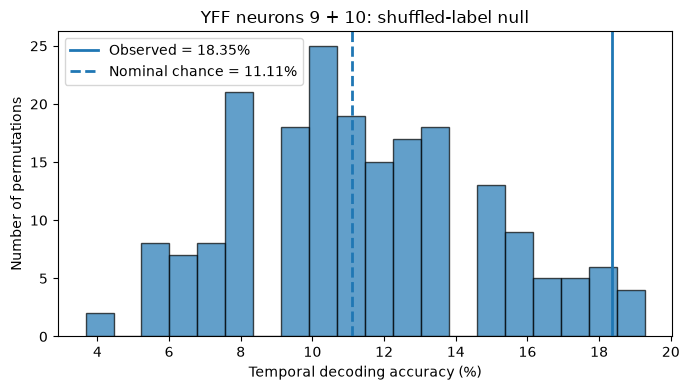

In [19]:
plt.figure(figsize=(7, 4))

plt.hist(
    100 * tc_null,
    bins=20,
    edgecolor="black",
    alpha=0.7
)

plt.axvline(
    100 * best_tc_accuracy,
    linewidth=2,
    label=f"Observed = {100*best_tc_accuracy:.2f}%"
)

plt.axvline(
    100 / 9,
    linestyle="--",
    linewidth=2,
    label="Nominal chance = 11.11%"
)

plt.xlabel("Temporal decoding accuracy (%)")
plt.ylabel("Number of permutations")

plt.title(
    f"YFF neurons {neuron_1} + {neuron_2}: shuffled-label null"
)

plt.legend()
plt.tight_layout()
plt.show()

In [20]:
class_counts = pd.Series(y).value_counts()

min_class_count = class_counts.min()
n_splits_pair = min(10, int(min_class_count))

print("Class counts:")
print(class_counts.sort_index())

print("\nMinimum class count:", min_class_count)
print("CV folds:", n_splits_pair)

Class counts:
1    10
2    15
3    11
4     7
5     7
6    16
7    17
8    12
9    14
Name: count, dtype: int64

Minimum class count: 7
CV folds: 7


In [21]:
# ============================================================
# CORRECT CV FOLD COUNT
# ============================================================

class_counts = pd.Series(y).value_counts()
n_splits_pair = min(10, int(class_counts.min()))

print("Using", n_splits_pair, "CV folds")


# ============================================================
# 1. FIRING-RATE GRID SEARCH
# ============================================================

fr_results = []

for gamma in GAMMAS:

    accuracy = cv_lda_accuracy(
        X_fr_pair,
        y,
        gamma=gamma,
        n_splits=n_splits_pair,
        random_state=42
    )

    fr_results.append({
        "gamma": gamma,
        "accuracy": accuracy
    })

fr_results = pd.DataFrame(fr_results)

best_fr_row = fr_results.loc[fr_results["accuracy"].idxmax()]

best_fr_gamma = float(best_fr_row["gamma"])
best_fr_accuracy = float(best_fr_row["accuracy"])


# ============================================================
# 2. TEMPORAL GRID SEARCH
# ============================================================

tc_results = []

for bin_size in BIN_SIZES:

    X1, y1, edges1 = make_temporal_features(
        presentations,
        spike_times_1,
        bin_size=bin_size
    )

    X2, y2, edges2 = make_temporal_features(
        presentations,
        spike_times_2,
        bin_size=bin_size
    )

    assert np.array_equal(y1, y2)
    assert np.array_equal(y, y1)
    assert np.array_equal(edges1, edges2)

    X_pair = np.hstack([X1, X2])

    for gamma in GAMMAS:

        accuracy = cv_lda_accuracy(
            X_pair,
            y,
            gamma=gamma,
            n_splits=n_splits_pair,
            random_state=42
        )

        tc_results.append({
            "bin_size_ms": bin_size,
            "gamma": gamma,
            "n_features": X_pair.shape[1],
            "accuracy": accuracy
        })

tc_results = pd.DataFrame(tc_results)

best_tc_row = tc_results.loc[tc_results["accuracy"].idxmax()]

best_tc_bin = int(best_tc_row["bin_size_ms"])
best_tc_gamma = float(best_tc_row["gamma"])
best_tc_accuracy = float(best_tc_row["accuracy"])


# ============================================================
# 3. REBUILD BEST TEMPORAL REPRESENTATION
# ============================================================

X1_best, y1, _ = make_temporal_features(
    presentations,
    spike_times_1,
    bin_size=best_tc_bin
)

X2_best, y2, _ = make_temporal_features(
    presentations,
    spike_times_2,
    bin_size=best_tc_bin
)

assert np.array_equal(y1, y2)
assert np.array_equal(y, y1)

X_tc_pair_best = np.hstack([X1_best, X2_best])


# ============================================================
# 4. PERMUTATION TEST
# ============================================================

N_PERMUTATIONS = 200
rng = np.random.default_rng(12345)

fr_null = np.empty(N_PERMUTATIONS)
tc_null = np.empty(N_PERMUTATIONS)

for p in range(N_PERMUTATIONS):

    # One common label shuffle
    y_shuffle = rng.permutation(y)

    fr_null[p] = cv_lda_accuracy(
        X_fr_pair,
        y_shuffle,
        gamma=best_fr_gamma,
        n_splits=n_splits_pair,
        random_state=42
    )

    tc_null[p] = cv_lda_accuracy(
        X_tc_pair_best,
        y_shuffle,
        gamma=best_tc_gamma,
        n_splits=n_splits_pair,
        random_state=42
    )


# ============================================================
# 5. P-VALUES
# ============================================================

fr_p = (
    1 + np.sum(fr_null >= best_fr_accuracy)
) / (N_PERMUTATIONS + 1)

tc_p = (
    1 + np.sum(tc_null >= best_tc_accuracy)
) / (N_PERMUTATIONS + 1)


# ============================================================
# 6. FINAL RESULT
# ============================================================

print("\nPAIR:", neuron_1, neuron_2)
print("CV folds:", n_splits_pair)

print("\nFIRING RATE")
print(f"Accuracy     : {100*best_fr_accuracy:.2f}%")
print(f"Best gamma   : {best_fr_gamma}")
print(f"Null mean    : {100*fr_null.mean():.2f}%")
print(f"p-value      : {fr_p:.5f}")
print(f"Coding pair  : {fr_p < 0.05}")

print("\nTEMPORAL")
print(f"Accuracy     : {100*best_tc_accuracy:.2f}%")
print(f"Best bin     : {best_tc_bin} ms")
print(f"Best gamma   : {best_tc_gamma}")
print(f"Null mean    : {100*tc_null.mean():.2f}%")
print(f"p-value      : {tc_p:.5f}")
print(f"Coding pair  : {tc_p < 0.05}")

Using 7 CV folds

PAIR: 9 10
CV folds: 7

FIRING RATE
Accuracy     : 12.84%
Best gamma   : 0.2
Null mean    : 10.99%
p-value      : 0.35821
Coding pair  : False

TEMPORAL
Accuracy     : 21.10%
Best bin     : 100 ms
Best gamma   : 0.2
Null mean    : 11.62%
p-value      : 0.00498
Coding pair  : True


In [22]:
from src.paired_neuron_analysis import analyze_neuron_pair

test_pair = analyze_neuron_pair(
    subject="YFF",
    neuron_1=9,
    neuron_2=10,
    root=PROJECT_ROOT,
    n_permutations=200
)

pd.Series(test_pair)

subject                 YFF
neuron_1                  9
neuron_2                 10
n_presentations         109
min_class_count           7
n_splits                  7
FR_accuracy         0.12844
FR_best_gamma           0.2
FR_null_mean       0.109908
FR_null_sd         0.033402
FR_p               0.358209
FR_coding             False
TC_accuracy        0.211009
TC_best_bin_ms          100
TC_best_gamma           0.2
TC_null_mean       0.116239
TC_null_sd         0.033719
TC_p               0.004975
TC_coding              True
TC_minus_FR        0.082569
dtype: object

In [23]:
from itertools import combinations
from pathlib import Path
import time
import pandas as pd

# ============================================================
# YFF NEURONS
# ============================================================

subject = "YFF"

subject_neurons = sorted(
    single.loc[
        single["subject"] == subject,
        "neuron"
    ].astype(int).tolist()
)

pairs = list(combinations(subject_neurons, 2))

print("Subject:", subject)
print("Number of neurons:", len(subject_neurons))
print("Number of pairs:", len(pairs))


# ============================================================
# OUTPUT FILE
# ============================================================

output_file = TABLES_DIR / "pairing_YFF.csv"

results = []

start_time = time.time()


# ============================================================
# RUN ALL PAIRS
# ============================================================

for k, (neuron_1, neuron_2) in enumerate(pairs, start=1):

    pair_start = time.time()

    try:

        result = analyze_neuron_pair(
            subject=subject,
            neuron_1=neuron_1,
            neuron_2=neuron_2,
            root=PROJECT_ROOT,
            n_permutations=200
        )

        result["status"] = "success"
        result["error"] = ""

    except Exception as e:

        result = {
            "subject": subject,
            "neuron_1": neuron_1,
            "neuron_2": neuron_2,
            "status": "failed",
            "error": str(e)
        }

    result["elapsed_seconds"] = (
        time.time() - pair_start
    )

    results.append(result)

    # Save after every pair
    pd.DataFrame(results).to_csv(
        output_file,
        index=False
    )

    print(
        f"[{k:3d}/{len(pairs)}] "
        f"({neuron_1}, {neuron_2}) "
        f"{result['status']} "
        f"{result['elapsed_seconds']:.1f}s"
    )


# ============================================================
# FINISHED
# ============================================================

total_minutes = (
    time.time() - start_time
) / 60

print("\nFinished.")
print(f"Total time: {total_minutes:.2f} minutes")
print("Saved to:", output_file)

Subject: YFF
Number of neurons: 37
Number of pairs: 666
[  1/666] (9, 10) success 29.1s
[  2/666] (9, 11) success 32.1s
[  3/666] (9, 12) success 31.6s
[  4/666] (9, 13) success 17.2s
[  5/666] (9, 14) success 15.6s
[  6/666] (9, 15) success 16.1s
[  7/666] (9, 16) success 15.6s
[  8/666] (9, 17) success 16.3s
[  9/666] (9, 27) success 17.2s
[ 10/666] (9, 28) success 11.5s
[ 11/666] (9, 29) success 11.4s
[ 12/666] (9, 30) success 11.9s
[ 13/666] (9, 31) success 13.8s
[ 14/666] (9, 32) success 13.4s
[ 15/666] (9, 33) success 11.6s
[ 16/666] (9, 34) success 12.0s
[ 17/666] (9, 35) success 14.0s
[ 18/666] (9, 36) success 11.7s
[ 19/666] (9, 37) success 11.7s
[ 20/666] (9, 38) success 11.4s
[ 21/666] (9, 39) success 11.1s
[ 22/666] (9, 40) success 11.4s
[ 23/666] (9, 41) success 16.2s
[ 24/666] (9, 42) success 13.1s
[ 25/666] (9, 43) success 15.5s
[ 26/666] (9, 44) success 11.1s
[ 27/666] (9, 45) success 11.0s
[ 28/666] (9, 46) success 11.1s
[ 29/666] (9, 47) success 13.6s
[ 30/666] (9, 48

In [24]:
from src.paired_neuron_analysis import analyze_neuron_pair

test_pair = analyze_neuron_pair(
    subject="YFF",
    neuron_1=9,
    neuron_2=10,
    root=PROJECT_ROOT,
    n_permutations=200
)

pd.Series(test_pair)

subject                 YFF
neuron_1                  9
neuron_2                 10
n_presentations         109
min_class_count           7
n_splits                  7
FR_accuracy         0.12844
FR_best_gamma           0.2
FR_null_mean       0.109908
FR_null_sd         0.033402
FR_p               0.358209
FR_coding             False
TC_accuracy        0.211009
TC_best_bin_ms          100
TC_best_gamma           0.2
TC_null_mean       0.116239
TC_null_sd         0.033719
TC_p               0.004975
TC_coding              True
TC_minus_FR        0.082569
dtype: object

In [25]:
# ============================================================
# LOAD AND CHECK YFF PAIR RESULTS
# ============================================================

pair_file = TABLES_DIR / "pairing_YFF.csv"

pairs_yff = pd.read_csv(pair_file)

print("Shape:", pairs_yff.shape)

print("\nStatus counts:")
print(pairs_yff["status"].value_counts(dropna=False))

successful = pairs_yff[
    pairs_yff["status"] == "success"
].copy()

print("\nSuccessful pairs:", len(successful))
print("Failed pairs:", len(pairs_yff) - len(successful))


# ============================================================
# BASIC RESULTS
# ============================================================

print("\n--- FIRING RATE ---")
print(
    f"Mean pair accuracy: "
    f"{100 * successful['FR_accuracy'].mean():.2f}%"
)
print(
    f"Number-coding pairs: "
    f"{successful['FR_coding'].sum()} / {len(successful)} "
    f"({100 * successful['FR_coding'].mean():.2f}%)"
)

print("\n--- TEMPORAL ---")
print(
    f"Mean pair accuracy: "
    f"{100 * successful['TC_accuracy'].mean():.2f}%"
)
print(
    f"Number-coding pairs: "
    f"{successful['TC_coding'].sum()} / {len(successful)} "
    f"({100 * successful['TC_coding'].mean():.2f}%)"
)

print("\n--- TEMPORAL VS FIRING RATE ---")
print(
    f"Mean TC - FR: "
    f"{100 * successful['TC_minus_FR'].mean():+.2f} percentage points"
)

print(
    f"Pairs with TC > FR: "
    f"{(successful['TC_minus_FR'] > 0).sum()} / {len(successful)}"
)


# ============================================================
# BEST TEMPORAL PAIRS
# ============================================================

print("\nTop 10 temporal-decoding pairs:")

display(
    successful[
        [
            "neuron_1",
            "neuron_2",
            "FR_accuracy",
            "TC_accuracy",
            "TC_best_bin_ms",
            "TC_best_gamma",
            "TC_p",
            "TC_coding"
        ]
    ]
    .sort_values(
        "TC_accuracy",
        ascending=False
    )
    .head(10)
)

Shape: (666, 23)

Status counts:
status
success    666
Name: count, dtype: int64

Successful pairs: 666
Failed pairs: 0

--- FIRING RATE ---
Mean pair accuracy: 11.42%
Number-coding pairs: 23 / 666 (3.45%)

--- TEMPORAL ---
Mean pair accuracy: 16.75%
Number-coding pairs: 240 / 666 (36.04%)

--- TEMPORAL VS FIRING RATE ---
Mean TC - FR: +5.33 percentage points
Pairs with TC > FR: 594 / 666

Top 10 temporal-decoding pairs:


,neuron_1,neuron_2,FR_accuracy,TC_accuracy,TC_best_bin_ms,TC_best_gamma,TC_p,TC_coding
398,31,40,0.110092,0.266055,150,0.2,0.004975,True
498,36,40,0.146789,0.256881,150,0.2,0.004975,True
337,28,51,0.165138,0.256881,90,0.2,0.004975,True
186,14,40,0.146789,0.256881,300,0.2,0.004975,True
476,35,36,0.119266,0.256881,150,0.5,0.004975,True
118,12,35,0.119266,0.247706,300,0.2,0.004975,True
386,30,51,0.165138,0.247706,90,0.2,0.004975,True
273,17,40,0.183486,0.247706,300,0.2,0.004975,True
391,31,33,0.100917,0.238532,60,0.5,0.009950,True
431,32,51,0.155963,0.238532,90,0.2,0.004975,True


In [26]:
import time
import numpy as np
import pandas as pd

from src.firing_rate_tuning import analyze_neuron
from src.number_decoding_analysis import (
    make_firing_rate_features,
    make_temporal_features,
    cv_lda_accuracy,
)

# ============================================================
# SETTINGS
# ============================================================

subject = "YFF"

BIN_SIZES = [60, 75, 90, 100, 150, 180, 225, 300, 450, 900]
GAMMAS = [0.2, 0.5, 0.8]

N_SPLITS = 7
N_PERMUTATIONS = 200
RANDOM_STATE = 42
PERMUTATION_SEED = 12345

output_file = TABLES_DIR / "single_YFF_7fold.csv"

single_yff_results = []

start_time = time.time()


# ============================================================
# LOOP OVER YFF NEURONS
# ============================================================

for k, neuron in enumerate(subject_neurons, start=1):

    neuron_start = time.time()

    # --------------------------------------------------------
    # Load neuron
    # --------------------------------------------------------

    result = analyze_neuron(
        subject,
        neuron,
        root=PROJECT_ROOT,
        plot=False,
        verbose=False
    )

    presentations = result["presentations"]
    spike_times = result["spike_times"]


    # ========================================================
    # FIRING-RATE FEATURES
    # ========================================================

    X_fr, y = make_firing_rate_features(
        presentations,
        spike_times
    )


    # --------------------------------------------------------
    # FR gamma search
    # --------------------------------------------------------

    fr_grid = []

    for gamma in GAMMAS:

        accuracy = cv_lda_accuracy(
            X_fr,
            y,
            gamma=gamma,
            n_splits=N_SPLITS,
            random_state=RANDOM_STATE
        )

        fr_grid.append(
            (gamma, accuracy)
        )

    best_fr_gamma, best_fr_accuracy = max(
        fr_grid,
        key=lambda x: x[1]
    )


    # ========================================================
    # TEMPORAL GRID SEARCH
    # ========================================================

    tc_grid = []

    for bin_size in BIN_SIZES:

        X_tc, y_tc, _ = make_temporal_features(
            presentations,
            spike_times,
            bin_size=bin_size
        )

        assert np.array_equal(y, y_tc)

        for gamma in GAMMAS:

            accuracy = cv_lda_accuracy(
                X_tc,
                y,
                gamma=gamma,
                n_splits=N_SPLITS,
                random_state=RANDOM_STATE
            )

            tc_grid.append(
                (
                    bin_size,
                    gamma,
                    accuracy
                )
            )

    best_tc_bin, best_tc_gamma, best_tc_accuracy = max(
        tc_grid,
        key=lambda x: x[2]
    )


    # ========================================================
    # REBUILD BEST TEMPORAL FEATURES
    # ========================================================

    X_tc_best, y_tc_best, _ = make_temporal_features(
        presentations,
        spike_times,
        bin_size=best_tc_bin
    )

    assert np.array_equal(y, y_tc_best)


    # ========================================================
    # PERMUTATIONS
    # ========================================================

    # Same seed for every neuron, matching our pair convention
    rng = np.random.default_rng(
        PERMUTATION_SEED
    )

    fr_null = np.empty(
        N_PERMUTATIONS
    )

    tc_null = np.empty(
        N_PERMUTATIONS
    )

    for p in range(N_PERMUTATIONS):

        y_shuffle = rng.permutation(y)

        fr_null[p] = cv_lda_accuracy(
            X_fr,
            y_shuffle,
            gamma=best_fr_gamma,
            n_splits=N_SPLITS,
            random_state=RANDOM_STATE
        )

        tc_null[p] = cv_lda_accuracy(
            X_tc_best,
            y_shuffle,
            gamma=best_tc_gamma,
            n_splits=N_SPLITS,
            random_state=RANDOM_STATE
        )


    # ========================================================
    # P-VALUES
    # ========================================================

    fr_p = (
        1 + np.sum(
            fr_null >= best_fr_accuracy
        )
    ) / (
        N_PERMUTATIONS + 1
    )

    tc_p = (
        1 + np.sum(
            tc_null >= best_tc_accuracy
        )
    ) / (
        N_PERMUTATIONS + 1
    )


    # ========================================================
    # SAVE RESULT
    # ========================================================

    row = {
        "subject": subject,
        "neuron": int(neuron),

        "n_presentations": len(y),
        "n_splits": N_SPLITS,

        "FR_accuracy": best_fr_accuracy,
        "FR_best_gamma": best_fr_gamma,
        "FR_null_mean": fr_null.mean(),
        "FR_p": fr_p,
        "FR_coding": fr_p < 0.05,

        "TC_accuracy": best_tc_accuracy,
        "TC_best_bin_ms": best_tc_bin,
        "TC_best_gamma": best_tc_gamma,
        "TC_null_mean": tc_null.mean(),
        "TC_p": tc_p,
        "TC_coding": tc_p < 0.05,

        "elapsed_seconds": (
            time.time() - neuron_start
        )
    }

    single_yff_results.append(row)

    # Save continuously
    pd.DataFrame(
        single_yff_results
    ).to_csv(
        output_file,
        index=False
    )

    print(
        f"[{k:2d}/{len(subject_neurons)}] "
        f"Neuron {neuron:2d} | "
        f"FR {100*best_fr_accuracy:5.2f}% | "
        f"TC {100*best_tc_accuracy:5.2f}% | "
        f"TC coding={tc_p < 0.05} | "
        f"{row['elapsed_seconds']:.1f}s"
    )


print(
    "\nFinished in",
    round(
        (time.time() - start_time) / 60,
        2
    ),
    "minutes"
)

print("Saved:", output_file)

[ 1/37] Neuron  9 | FR 10.09% | TC 16.51% | TC coding=False | 11.2s
[ 2/37] Neuron 10 | FR  9.17% | TC 15.60% | TC coding=False | 11.5s
[ 3/37] Neuron 11 | FR 11.01% | TC 20.18% | TC coding=True | 11.2s
[ 4/37] Neuron 12 | FR 10.09% | TC 17.43% | TC coding=True | 10.6s
[ 5/37] Neuron 13 | FR 14.68% | TC 15.60% | TC coding=False | 11.4s
[ 6/37] Neuron 14 | FR 11.93% | TC 19.27% | TC coding=True | 11.0s
[ 7/37] Neuron 15 | FR  5.50% | TC 16.51% | TC coding=False | 11.3s
[ 8/37] Neuron 16 | FR  9.17% | TC 14.68% | TC coding=False | 12.4s
[ 9/37] Neuron 17 | FR 15.60% | TC 16.51% | TC coding=False | 10.7s
[10/37] Neuron 27 | FR  7.34% | TC 14.68% | TC coding=False | 12.8s
[11/37] Neuron 28 | FR  6.42% | TC 10.09% | TC coding=False | 11.2s
[12/37] Neuron 29 | FR  9.17% | TC 18.35% | TC coding=True | 10.2s
[13/37] Neuron 30 | FR  6.42% | TC 11.01% | TC coding=False | 11.6s
[14/37] Neuron 31 | FR  9.17% | TC 19.27% | TC coding=True | 11.6s
[15/37] Neuron 32 | FR  8.26% | TC 10.09% | TC coding

In [27]:
# ============================================================
# LOAD RESULTS
# ============================================================

single_7 = pd.read_csv(
    TABLES_DIR / "single_YFF_7fold.csv"
)

pairs = pd.read_csv(
    TABLES_DIR / "pairing_YFF.csv"
)

pairs = pairs[
    pairs["status"] == "success"
].copy()


# ============================================================
# ADD NEURON 1 RESULTS
# ============================================================

n1 = single_7[
    [
        "neuron",
        "FR_accuracy",
        "TC_accuracy",
        "FR_coding",
        "TC_coding"
    ]
].copy()

n1.columns = [
    "neuron_1",
    "FR_accuracy_1",
    "TC_accuracy_1",
    "FR_coding_1",
    "TC_coding_1"
]

comparison = pairs.merge(
    n1,
    on="neuron_1",
    how="left"
)


# ============================================================
# ADD NEURON 2 RESULTS
# ============================================================

n2 = single_7[
    [
        "neuron",
        "FR_accuracy",
        "TC_accuracy",
        "FR_coding",
        "TC_coding"
    ]
].copy()

n2.columns = [
    "neuron_2",
    "FR_accuracy_2",
    "TC_accuracy_2",
    "FR_coding_2",
    "TC_coding_2"
]

comparison = comparison.merge(
    n2,
    on="neuron_2",
    how="left"
)


# ============================================================
# BEST INDIVIDUAL ACCURACY
# ============================================================

comparison["best_single_FR"] = comparison[
    ["FR_accuracy_1", "FR_accuracy_2"]
].max(axis=1)

comparison["best_single_TC"] = comparison[
    ["TC_accuracy_1", "TC_accuracy_2"]
].max(axis=1)


# ============================================================
# PAIR GAIN OVER BEST INDIVIDUAL
# ============================================================

comparison["FR_pair_gain"] = (
    comparison["FR_accuracy"]
    - comparison["best_single_FR"]
)

comparison["TC_pair_gain"] = (
    comparison["TC_accuracy"]
    - comparison["best_single_TC"]
)


# ============================================================
# BOTH INDIVIDUAL NEURONS NONCODING?
# ============================================================

comparison["both_FR_noncoding"] = (
    (~comparison["FR_coding_1"])
    &
    (~comparison["FR_coding_2"])
)

comparison["both_TC_noncoding"] = (
    (~comparison["TC_coding_1"])
    &
    (~comparison["TC_coding_2"])
)


# ============================================================
# EMERGENT CODING PAIRS
# noncoding + noncoding -> coding pair
# ============================================================

comparison["FR_emergent_pair"] = (
    comparison["both_FR_noncoding"]
    &
    comparison["FR_coding"]
)

comparison["TC_emergent_pair"] = (
    comparison["both_TC_noncoding"]
    &
    comparison["TC_coding"]
)


# ============================================================
# SUMMARY
# ============================================================

print("Number of pairs:", len(comparison))

print("\n========== FIRING RATE ==========")

print(
    "Mean gain over best single:",
    f"{100 * comparison['FR_pair_gain'].mean():+.2f} pp"
)

print(
    "Pairs beating best single:",
    f"{(comparison['FR_pair_gain'] > 0).sum()} / {len(comparison)}",
    f"({100*(comparison['FR_pair_gain'] > 0).mean():.2f}%)"
)

print(
    "Noncoding + noncoding -> coding pair:",
    f"{comparison['FR_emergent_pair'].sum()}"
)


print("\n========== TEMPORAL ==========")

print(
    "Mean gain over best single:",
    f"{100 * comparison['TC_pair_gain'].mean():+.2f} pp"
)

print(
    "Pairs beating best single:",
    f"{(comparison['TC_pair_gain'] > 0).sum()} / {len(comparison)}",
    f"({100*(comparison['TC_pair_gain'] > 0).mean():.2f}%)"
)

print(
    "Noncoding + noncoding -> coding pair:",
    f"{comparison['TC_emergent_pair'].sum()}"
)


# ============================================================
# SAVE
# ============================================================

comparison.to_csv(
    TABLES_DIR / "pairing_YFF_vs_individuals.csv",
    index=False
)

print(
    "\nSaved:",
    TABLES_DIR / "pairing_YFF_vs_individuals.csv"
)

Number of pairs: 666

========== FIRING RATE ==========
Mean gain over best single: -0.75 pp
Pairs beating best single: 222 / 666 (33.33%)
Noncoding + noncoding -> coding pair: 15

========== TEMPORAL ==========
Mean gain over best single: -0.79 pp
Pairs beating best single: 192 / 666 (28.83%)
Noncoding + noncoding -> coding pair: 63

Saved: C:\Users\shafi\number-simplex-reproduction\tables1\pairing_YFF_vs_individuals.csv


| Measure | Single neurons | Neuron pairs | Change / pair result |
|---|---:|---:|---:|
| Number analyzed | **37 neurons** | **666 pairs** | — |
| Mean FR decoding accuracy | **10.19%** | **11.42%** | **+1.23 pp** vs average single |
| Mean temporal decoding accuracy | **15.55%** | **16.75%** | **+1.20 pp** vs average single |
| FR number-coding proportion | **1/37 = 2.70%** | **23/666 = 3.45%** | +0.75 pp |
| Temporal number-coding proportion | **10/37 = 27.03%** | **240/666 = 36.04%** | +9.01 pp |
| Pair FR accuracy > better constituent neuron | — | **222/666 = 33.33%** | Mean gain vs better neuron = **−0.75 pp** |
| Pair temporal accuracy > better constituent neuron | — | **192/666 = 28.83%** | Mean gain vs better neuron = **−0.79 pp** |
| Both FR-noncoding → coding pair | — | **15 pairs** | **15 newly significant pairs** |
| Both temporal-noncoding → coding pair | — | **63 pairs** | **63 newly significant pairs** |

In [28]:
single_7 = pd.read_csv(
    TABLES_DIR / "single_YFF_7fold.csv"
)

print(
    f"Mean FR accuracy: "
    f"{100*single_7['FR_accuracy'].mean():.2f}%"
)

print(
    f"Mean TC accuracy: "
    f"{100*single_7['TC_accuracy'].mean():.2f}%"
)

print(
    f"FR coding: "
    f"{single_7['FR_coding'].sum()} / {len(single_7)} "
    f"({100*single_7['FR_coding'].mean():.2f}%)"
)

print(
    f"TC coding: "
    f"{single_7['TC_coding'].sum()} / {len(single_7)} "
    f"({100*single_7['TC_coding'].mean():.2f}%)"
)

Mean FR accuracy: 10.19%
Mean TC accuracy: 15.55%
FR coding: 1 / 37 (2.70%)
TC coding: 10 / 37 (27.03%)


The more interesting observation is the coding proportion. Temporal coding goes from 27.03% of individual neurons to 36.04% of pairs, and there are 63 pairs where neither constituent neuron was individually significant but their joint temporal representation was significant.

| Question | FR | Temporal | What it tells us |
|---|---:|---:|---|
| Average single-neuron accuracy | 10.19% | 15.55% | Baseline |
| Average pair accuracy | 11.42% | 16.75% | Pairs are higher on average |
| Difference in averages | **+1.23 pp** | **+1.20 pp** | Suggests a population-level benefit |
| Pair beats its **better constituent neuron** | 33.33% | 28.83% | Only a minority of pairs |
| Mean pair gain over better constituent | −0.75 pp | −0.79 pp | Typical pair does not beat its strongest member |
| Single coding proportion | 2.70% | 27.03% | |
| Pair coding proportion | 3.45% | **36.04%** | More temporal pairs pass the permutation criterion |
| Both noncoding → coding pair | 15 | **63** | Particularly interesting joint-decoding cases |

In [30]:
# ============================================================
# YFF: PAIRS WHERE BOTH NEURONS ARE TEMPORAL NUMBER-CODING
# ============================================================

import pandas as pd
import numpy as np

single = pd.read_csv(
    TABLES_DIR / "single_YFF_7fold.csv"
)

pairs = pd.read_csv(
    TABLES_DIR / "pairing_YFF_vs_individuals.csv"
)

# ------------------------------------------------------------
# 1. Identify individually temporal-coding neurons
# ------------------------------------------------------------

coding_neurons = single.loc[
    single["TC_coding"] == True,
    "neuron"
].astype(int).tolist()

print("Individually temporal-coding neurons:")
print(coding_neurons)

print(
    f"\nNumber of coding neurons: "
    f"{len(coding_neurons)} / {len(single)} "
    f"({100*len(coding_neurons)/len(single):.2f}%)"
)


# ------------------------------------------------------------
# 2. Keep only pairs where BOTH neurons were individually coding
# ------------------------------------------------------------

coding_pairs = pairs[
    pairs["neuron_1"].isin(coding_neurons)
    &
    pairs["neuron_2"].isin(coding_neurons)
].copy()

print(
    f"\nCoding + coding pairs: "
    f"{len(coding_pairs)}"
)


# ------------------------------------------------------------
# 3. Accuracy summaries
# ------------------------------------------------------------

mean_single_coding_accuracy = single.loc[
    single["TC_coding"] == True,
    "TC_accuracy"
].mean()

mean_pair_accuracy = coding_pairs[
    "TC_accuracy"
].mean()

mean_best_single = coding_pairs[
    "best_single_TC"
].mean()

mean_gain_vs_best = coding_pairs[
    "TC_pair_gain"
].mean()

n_beats_best = (
    coding_pairs["TC_pair_gain"] > 0
).sum()

prop_beats_best = (
    coding_pairs["TC_pair_gain"] > 0
).mean()


# ------------------------------------------------------------
# 4. Does the pair itself remain number-coding?
# ------------------------------------------------------------

n_pair_coding = coding_pairs[
    "TC_coding"
].sum()

prop_pair_coding = coding_pairs[
    "TC_coding"
].mean()


# ------------------------------------------------------------
# 5. Print clean summary
# ------------------------------------------------------------

print("\n========== CODING + CODING PAIRS ==========")

print(
    f"Mean accuracy of individually coding neurons: "
    f"{100*mean_single_coding_accuracy:.2f}%"
)

print(
    f"Mean accuracy of coding-neuron pairs: "
    f"{100*mean_pair_accuracy:.2f}%"
)

print(
    f"Mean accuracy of better constituent neuron: "
    f"{100*mean_best_single:.2f}%"
)

print(
    f"Mean pair gain over better constituent: "
    f"{100*mean_gain_vs_best:+.2f} pp"
)

print(
    f"Pairs beating better constituent: "
    f"{n_beats_best} / {len(coding_pairs)} "
    f"({100*prop_beats_best:.2f}%)"
)

print(
    f"Pairs classified as temporal number-coding: "
    f"{int(n_pair_coding)} / {len(coding_pairs)} "
    f"({100*prop_pair_coding:.2f}%)"
)


# ------------------------------------------------------------
# 6. Save subset
# ------------------------------------------------------------

coding_pairs.to_csv(
    TABLES_DIR / "pairing_YFF_coding_plus_coding.csv",
    index=False
)

print(
    "\nSaved:",
    TABLES_DIR / "pairing_YFF_coding_plus_coding.csv"
)

Individually temporal-coding neurons:
[11, 12, 14, 29, 31, 35, 39, 40, 51, 53]

Number of coding neurons: 10 / 37 (27.03%)

Coding + coding pairs: 45

========== CODING + CODING PAIRS ==========
Mean accuracy of individually coding neurons: 19.45%
Mean accuracy of coding-neuron pairs: 19.27%
Mean accuracy of better constituent neuron: 20.31%
Mean pair gain over better constituent: -1.04 pp
Pairs beating better constituent: 12 / 45 (26.67%)
Pairs classified as temporal number-coding: 30 / 45 (66.67%)

Saved: C:\Users\shafi\number-simplex-reproduction\tables1\pairing_YFF_coding_plus_coding.csv


| Measure | Result |
|---|---:|
| Individually temporal-coding neurons | **10 / 37 = 27.03%** |
| Possible coding + coding pairs | **45** |
| Mean accuracy of coding neurons individually | **19.45%** |
| Mean accuracy of coding + coding pairs | **19.27%** |
| Mean accuracy of better neuron within each pair | **20.31%** |
| Mean pair gain over better neuron | **−1.04 pp** |
| Pair beats its better neuron | **12 / 45 = 26.67%** |
| Pair itself is significant number-coding | **30 / 45 = 66.67%** |

"coding + coding" does not guarantee a coding pair.

# Region Level "

\[
\text{HPC+HPC},\quad
\text{AMY+AMY},\quad
\text{ENT+ENT},\quad
\text{PHC+PHC}.
\]

In [31]:
import pandas as pd
import numpy as np

# ============================================================
# LOAD EXISTING RESULTS
# ============================================================

single = pd.read_csv(
    TABLES_DIR / "single_YFF_7fold.csv"
)

pairs = pd.read_csv(
    TABLES_DIR / "pairing_YFF_vs_individuals.csv"
)

master = pd.read_csv(
    TABLES_DIR / "figure1M_all_neuron_permutations.csv"
)


# ============================================================
# GET YFF REGION LABEL FOR EACH NEURON
# ============================================================

yff_regions = (
    master[master["subject"] == "YFF"]
    [["neuron", "region"]]
    .drop_duplicates()
    .copy()
)

print("YFF neurons by region:")
print(
    yff_regions["region"]
    .value_counts()
)


# ============================================================
# ADD REGION OF EACH CONSTITUENT NEURON TO PAIR TABLE
# ============================================================

r1 = yff_regions.rename(
    columns={
        "neuron": "neuron_1",
        "region": "region_1"
    }
)

r2 = yff_regions.rename(
    columns={
        "neuron": "neuron_2",
        "region": "region_2"
    }
)

regional_pairs = (
    pairs
    .merge(r1, on="neuron_1", how="left")
    .merge(r2, on="neuron_2", how="left")
)


# ============================================================
# KEEP ONLY SAME-REGION PAIRS
# ============================================================

same_region = regional_pairs[
    regional_pairs["region_1"]
    ==
    regional_pairs["region_2"]
].copy()

same_region["region"] = same_region["region_1"]


# ============================================================
# SUMMARY FOR EACH REGION
# ============================================================

rows = []

for region, df in same_region.groupby("region"):

    rows.append({

        "region": region,

        "n_pairs": len(df),

        "mean_FR_accuracy_pct":
            100 * df["FR_accuracy"].mean(),

        "mean_TC_accuracy_pct":
            100 * df["TC_accuracy"].mean(),

        "FR_coding_pairs":
            int(df["FR_coding"].sum()),

        "FR_coding_proportion_pct":
            100 * df["FR_coding"].mean(),

        "TC_coding_pairs":
            int(df["TC_coding"].sum()),

        "TC_coding_proportion_pct":
            100 * df["TC_coding"].mean(),

        "mean_FR_gain_vs_best_pp":
            100 * df["FR_pair_gain"].mean(),

        "mean_TC_gain_vs_best_pp":
            100 * df["TC_pair_gain"].mean(),

        "FR_beats_best_pct":
            100 * (df["FR_pair_gain"] > 0).mean(),

        "TC_beats_best_pct":
            100 * (df["TC_pair_gain"] > 0).mean(),

        "TC_noncoding_plus_noncoding_to_coding":
            int(df["TC_emergent_pair"].sum())
    })


region_summary = pd.DataFrame(rows)


# ============================================================
# SORT BY REGION
# ============================================================

region_order = [
    "hpc",
    "amy",
    "ent",
    "para-hpc"
]

region_summary["order"] = (
    region_summary["region"]
    .str.lower()
    .map({
        name: i
        for i, name in enumerate(region_order)
    })
)

region_summary = (
    region_summary
    .sort_values("order")
    .drop(columns="order")
    .reset_index(drop=True)
)


# ============================================================
# DISPLAY
# ============================================================

display(
    region_summary.round(2)
)


# ============================================================
# SAVE
# ============================================================

region_summary.to_csv(
    TABLES_DIR / "pairing_YFF_same_region_summary.csv",
    index=False
)

same_region.to_csv(
    TABLES_DIR / "pairing_YFF_same_region_pairs.csv",
    index=False
)

print(
    "\nNumber of all YFF pairs:",
    len(pairs)
)

print(
    "Number of same-region YFF pairs:",
    len(same_region)
)

YFF neurons by region:
region
hpc    36
ent     1
Name: count, dtype: int64


,region,n_pairs,mean_FR_accuracy_pct,mean_TC_accuracy_pct,FR_coding_pairs,FR_coding_proportion_pct,TC_coding_pairs,TC_coding_proportion_pct,mean_FR_gain_vs_best_pp,mean_TC_gain_vs_best_pp,FR_beats_best_pct,TC_beats_best_pct,TC_noncoding_plus_noncoding_to_coding
0,hpc,630,11.44,16.76,22,3.49,229,36.35,-0.76,-0.79,33.33,29.37,56



Number of all YFF pairs: 666
Number of same-region YFF pairs: 630


| Measure | HPC-HPC result |
|---|---:|
| Number of pairs | **630** |
| Mean FR decoding accuracy | **11.44%** |
| Mean temporal decoding accuracy | **16.76%** |
| FR coding pairs | **22 / 630 = 3.49%** |
| Temporal coding pairs | **229 / 630 = 36.35%** |
| Mean FR gain over better constituent | **−0.76 pp** |
| Mean temporal gain over better constituent | **−0.79 pp** |
| FR pair beats better neuron | **33.33%** |
| Temporal pair beats better neuron | **29.37%** |
| Temporal noncoding + noncoding → coding | **56 pairs** |

For YFF temporal decoding we have 37 neurons:
\[
10\text{ coding},\qquad 27\text{ noncoding}.
\]

In [32]:
# ============================================================
# YFF: NONCODING + NONCODING TEMPORAL PAIRS
# ============================================================

import pandas as pd

single = pd.read_csv(
    TABLES_DIR / "single_YFF_7fold.csv"
)

pairs = pd.read_csv(
    TABLES_DIR / "pairing_YFF_vs_individuals.csv"
)


# ============================================================
# 1. IDENTIFY TEMPORAL NONCODING NEURONS
# ============================================================

noncoding_neurons = single.loc[
    single["TC_coding"] == False,
    "neuron"
].astype(int).tolist()

print("Individually temporal-noncoding neurons:")
print(noncoding_neurons)

print(
    f"\nNumber of noncoding neurons: "
    f"{len(noncoding_neurons)} / {len(single)} "
    f"({100*len(noncoding_neurons)/len(single):.2f}%)"
)


# ============================================================
# 2. KEEP ONLY NONCODING + NONCODING PAIRS
# ============================================================

noncoding_pairs = pairs[
    pairs["neuron_1"].isin(noncoding_neurons)
    &
    pairs["neuron_2"].isin(noncoding_neurons)
].copy()

print(
    f"\nNoncoding + noncoding pairs: "
    f"{len(noncoding_pairs)}"
)


# ============================================================
# 3. ACCURACY SUMMARIES
# ============================================================

mean_single_noncoding_accuracy = single.loc[
    single["TC_coding"] == False,
    "TC_accuracy"
].mean()

mean_pair_accuracy = noncoding_pairs[
    "TC_accuracy"
].mean()

mean_best_single = noncoding_pairs[
    "best_single_TC"
].mean()

mean_gain_vs_best = noncoding_pairs[
    "TC_pair_gain"
].mean()

n_beats_best = (
    noncoding_pairs["TC_pair_gain"] > 0
).sum()

prop_beats_best = (
    noncoding_pairs["TC_pair_gain"] > 0
).mean()


# ============================================================
# 4. HOW MANY BECOME NUMBER-CODING PAIRS?
# ============================================================

n_become_coding = noncoding_pairs[
    "TC_coding"
].sum()

prop_become_coding = noncoding_pairs[
    "TC_coding"
].mean()


# ============================================================
# 5. ACCURACY SPECIFICALLY FOR PAIRS THAT BECAME CODING
# ============================================================

emergent = noncoding_pairs[
    noncoding_pairs["TC_coding"] == True
].copy()

mean_emergent_pair_accuracy = (
    emergent["TC_accuracy"].mean()
)

mean_emergent_best_single = (
    emergent["best_single_TC"].mean()
)

mean_emergent_gain = (
    emergent["TC_pair_gain"].mean()
)


# ============================================================
# 6. PRINT SUMMARY
# ============================================================

print("\n========== NONCODING + NONCODING ==========")

print(
    f"Mean accuracy of individually noncoding neurons: "
    f"{100*mean_single_noncoding_accuracy:.2f}%"
)

print(
    f"Mean accuracy of noncoding-neuron pairs: "
    f"{100*mean_pair_accuracy:.2f}%"
)

print(
    f"Mean accuracy of better constituent neuron: "
    f"{100*mean_best_single:.2f}%"
)

print(
    f"Mean pair gain over better constituent: "
    f"{100*mean_gain_vs_best:+.2f} pp"
)

print(
    f"Pairs beating better constituent: "
    f"{n_beats_best} / {len(noncoding_pairs)} "
    f"({100*prop_beats_best:.2f}%)"
)

print(
    f"Pairs that become temporal number-coding: "
    f"{int(n_become_coding)} / {len(noncoding_pairs)} "
    f"({100*prop_become_coding:.2f}%)"
)


print("\n========== ONLY THOSE THAT BECAME CODING ==========")

print(
    f"Number of emergent coding pairs: "
    f"{len(emergent)}"
)

print(
    f"Mean pair accuracy: "
    f"{100*mean_emergent_pair_accuracy:.2f}%"
)

print(
    f"Mean better-single accuracy: "
    f"{100*mean_emergent_best_single:.2f}%"
)

print(
    f"Mean gain over better constituent: "
    f"{100*mean_emergent_gain:+.2f} pp"
)


# ============================================================
# 7. SAVE
# ============================================================

noncoding_pairs.to_csv(
    TABLES_DIR / "pairing_YFF_noncoding_plus_noncoding.csv",
    index=False
)

emergent.to_csv(
    TABLES_DIR / "pairing_YFF_noncoding_to_coding.csv",
    index=False
)

Individually temporal-noncoding neurons:
[9, 10, 13, 15, 16, 17, 27, 28, 30, 32, 33, 34, 36, 37, 38, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 52, 54]

Number of noncoding neurons: 27 / 37 (72.97%)

Noncoding + noncoding pairs: 351

========== NONCODING + NONCODING ==========
Mean accuracy of individually noncoding neurons: 14.10%
Mean accuracy of noncoding-neuron pairs: 15.49%
Mean accuracy of better constituent neuron: 15.71%
Mean pair gain over better constituent: -0.22 pp
Pairs beating better constituent: 128 / 351 (36.47%)
Pairs that become temporal number-coding: 63 / 351 (17.95%)

========== ONLY THOSE THAT BECAME CODING ==========
Number of emergent coding pairs: 63
Mean pair accuracy: 18.97%
Mean better-single accuracy: 17.15%
Mean gain over better constituent: +1.82 pp


| Group | Individual accuracy | Pair accuracy | Better constituent | Gain vs better constituent | Pairs beating better single | Pair becomes/is coding |
|---|---:|---:|---:|---:|---:|---:|
| **Coding + coding** | 19.45% | 19.27% | 20.31% | **−1.04 pp** | 26.67% | 66.67% |
| **Noncoding + noncoding** | 14.10% | **15.49%** | 15.71% | **−0.22 pp** | **36.47%** | 17.95% |
| **Noncoding + noncoding → coding** | — | **18.97%** | 17.15% | **+1.82 pp** | — | 100% by definition |

Total noncoding + noncoding pairs: 351
Pairs that became coding: 63


,neuron,TC_accuracy_pct,TC_p,total_possible_pairs,successful_coding_pairs,success_rate_pct
0,34,18.35,0.05,26,14,53.85
1,33,17.43,0.06,26,13,50.00
2,41,17.43,0.07,26,13,50.00
3,36,16.51,0.08,26,10,38.46
4,10,15.60,0.13,26,9,34.62
5,17,16.51,0.07,26,9,34.62
6,9,16.51,0.07,26,7,26.92
7,52,15.60,0.08,26,7,26.92
8,54,14.68,0.11,26,6,23.08
9,42,10.09,0.45,26,5,19.23


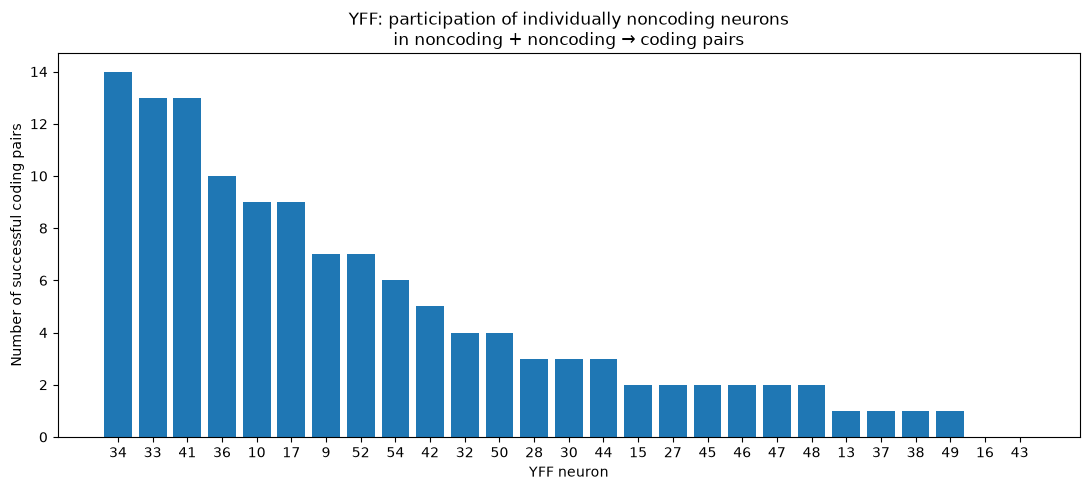


Saved: C:\Users\shafi\number-simplex-reproduction\tables1\YFF_noncoding_neuron_pair_success.csv


In [33]:
# ============================================================
# WHICH NONCODING NEURONS FORM SUCCESSFUL CODING PAIRS?
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. LOAD THE NONCODING + NONCODING PAIRS
# ------------------------------------------------------------

noncoding_pairs = pd.read_csv(
    TABLES_DIR / "pairing_YFF_noncoding_plus_noncoding.csv"
)

print("Total noncoding + noncoding pairs:", len(noncoding_pairs))


# ------------------------------------------------------------
# 2. IDENTIFY THE PAIRS THAT BECAME TEMPORAL NUMBER-CODING
# ------------------------------------------------------------

emergent = noncoding_pairs[
    noncoding_pairs["TC_coding"] == True
].copy()

print("Pairs that became coding:", len(emergent))


# ------------------------------------------------------------
# 3. GET ALL NONCODING NEURONS
# ------------------------------------------------------------

all_neurons = sorted(
    set(noncoding_pairs["neuron_1"])
    |
    set(noncoding_pairs["neuron_2"])
)


# ------------------------------------------------------------
# 4. COUNT HOW OFTEN EACH NEURON APPEARS
#    IN AN EMERGENT CODING PAIR
# ------------------------------------------------------------

rows = []

for neuron in all_neurons:

    # All possible noncoding pairs containing this neuron
    all_pairs_with_neuron = noncoding_pairs[
        (noncoding_pairs["neuron_1"] == neuron)
        |
        (noncoding_pairs["neuron_2"] == neuron)
    ]

    # Successful coding pairs containing this neuron
    successful_pairs = emergent[
        (emergent["neuron_1"] == neuron)
        |
        (emergent["neuron_2"] == neuron)
    ]

    n_total = len(all_pairs_with_neuron)
    n_success = len(successful_pairs)

    success_rate = (
        n_success / n_total
        if n_total > 0
        else np.nan
    )

    rows.append({
        "neuron": int(neuron),
        "total_possible_pairs": n_total,
        "successful_coding_pairs": n_success,
        "success_rate": success_rate
    })


neuron_success = pd.DataFrame(rows)


# ------------------------------------------------------------
# 5. ADD ORIGINAL SINGLE-NEURON TEMPORAL ACCURACY
# ------------------------------------------------------------

single = pd.read_csv(
    TABLES_DIR / "single_YFF_7fold.csv"
)

single_info = single[
    [
        "neuron",
        "TC_accuracy",
        "TC_p"
    ]
].copy()

neuron_success = neuron_success.merge(
    single_info,
    on="neuron",
    how="left"
)

neuron_success["TC_accuracy_pct"] = (
    100 * neuron_success["TC_accuracy"]
)

neuron_success["success_rate_pct"] = (
    100 * neuron_success["success_rate"]
)


# ------------------------------------------------------------
# 6. SORT BY NUMBER OF SUCCESSFUL PAIRS
# ------------------------------------------------------------

neuron_success = neuron_success.sort_values(
    [
        "successful_coding_pairs",
        "success_rate"
    ],
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# 7. DISPLAY TABLE
# ------------------------------------------------------------

display(
    neuron_success[
        [
            "neuron",
            "TC_accuracy_pct",
            "TC_p",
            "total_possible_pairs",
            "successful_coding_pairs",
            "success_rate_pct"
        ]
    ].round(2)
)


# ------------------------------------------------------------
# 8. SIMPLE BAR PLOT
# ------------------------------------------------------------

plot_df = neuron_success.sort_values(
    "successful_coding_pairs",
    ascending=False
)

plt.figure(figsize=(11, 5))

plt.bar(
    plot_df["neuron"].astype(str),
    plot_df["successful_coding_pairs"]
)

plt.xlabel("YFF neuron")
plt.ylabel("Number of successful coding pairs")

plt.title(
    "YFF: participation of individually noncoding neurons\n"
    "in noncoding + noncoding → coding pairs"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. SAVE
# ------------------------------------------------------------

neuron_success.to_csv(
    TABLES_DIR / "YFF_noncoding_neuron_pair_success.csv",
    index=False
)

print(
    "\nSaved:",
    TABLES_DIR / "YFF_noncoding_neuron_pair_success.csv"
)

In [34]:
# ============================================================
# COMPARE HIGH-SUCCESS VS ZERO-SUCCESS NONCODING NEURONS
# ============================================================

neurons_to_check = [
    34, 33, 41, 36, 10, 17,   # high-success
    16, 43                     # zero-success
]

check = neuron_success[
    neuron_success["neuron"].isin(neurons_to_check)
][
    [
        "neuron",
        "TC_accuracy_pct",
        "TC_p",
        "successful_coding_pairs",
        "success_rate_pct"
    ]
].copy()

check = check.sort_values(
    "successful_coding_pairs",
    ascending=False
)

display(check.round(3))

,neuron,TC_accuracy_pct,TC_p,successful_coding_pairs,success_rate_pct
0,34,18.349,0.055,14,53.846
1,33,17.431,0.065,13,50.000
2,41,17.431,0.070,13,50.000
3,36,16.514,0.080,10,38.462
4,10,15.596,0.134,9,34.615
5,17,16.514,0.075,9,34.615
25,16,14.679,0.179,0,0.000
26,43,11.009,0.617,0,0.000


In [35]:
# ============================================================
# YFF: CODING + NONCODING TEMPORAL PAIRS
# ============================================================

import pandas as pd
import numpy as np

single = pd.read_csv(
    TABLES_DIR / "single_YFF_7fold.csv"
)

pairs = pd.read_csv(
    TABLES_DIR / "pairing_YFF_vs_individuals.csv"
)


# ============================================================
# 1. IDENTIFY CODING AND NONCODING NEURONS
# ============================================================

coding_neurons = set(
    single.loc[
        single["TC_coding"] == True,
        "neuron"
    ].astype(int)
)

noncoding_neurons = set(
    single.loc[
        single["TC_coding"] == False,
        "neuron"
    ].astype(int)
)

print("Coding neurons:", len(coding_neurons))
print("Noncoding neurons:", len(noncoding_neurons))


# ============================================================
# 2. SELECT MIXED PAIRS
#    exactly one coding + one noncoding neuron
# ============================================================

mixed_pairs = pairs[
    (
        pairs["neuron_1"].isin(coding_neurons)
        &
        pairs["neuron_2"].isin(noncoding_neurons)
    )
    |
    (
        pairs["neuron_1"].isin(noncoding_neurons)
        &
        pairs["neuron_2"].isin(coding_neurons)
    )
].copy()

print("\nCoding + noncoding pairs:", len(mixed_pairs))


# ============================================================
# 3. IDENTIFY WHICH MEMBER IS THE CODING NEURON
# ============================================================

mixed_pairs["coding_neuron"] = np.where(
    mixed_pairs["neuron_1"].isin(coding_neurons),
    mixed_pairs["neuron_1"],
    mixed_pairs["neuron_2"]
)

mixed_pairs["noncoding_neuron"] = np.where(
    mixed_pairs["neuron_1"].isin(noncoding_neurons),
    mixed_pairs["neuron_1"],
    mixed_pairs["neuron_2"]
)

mixed_pairs["coding_neuron_accuracy"] = np.where(
    mixed_pairs["neuron_1"].isin(coding_neurons),
    mixed_pairs["TC_accuracy_1"],
    mixed_pairs["TC_accuracy_2"]
)

mixed_pairs["noncoding_neuron_accuracy"] = np.where(
    mixed_pairs["neuron_1"].isin(noncoding_neurons),
    mixed_pairs["TC_accuracy_1"],
    mixed_pairs["TC_accuracy_2"]
)


# ============================================================
# 4. PAIR GAIN RELATIVE TO THE CODING NEURON
# ============================================================

mixed_pairs["gain_vs_coding_neuron"] = (
    mixed_pairs["TC_accuracy"]
    -
    mixed_pairs["coding_neuron_accuracy"]
)


# ============================================================
# 5. SUMMARY
# ============================================================

mean_coding_accuracy = (
    mixed_pairs["coding_neuron_accuracy"].mean()
)

mean_noncoding_accuracy = (
    mixed_pairs["noncoding_neuron_accuracy"].mean()
)

mean_pair_accuracy = (
    mixed_pairs["TC_accuracy"].mean()
)

mean_gain_vs_coding = (
    mixed_pairs["gain_vs_coding_neuron"].mean()
)

n_beats_coding = (
    mixed_pairs["gain_vs_coding_neuron"] > 0
).sum()

prop_beats_coding = (
    mixed_pairs["gain_vs_coding_neuron"] > 0
).mean()

n_pair_coding = (
    mixed_pairs["TC_coding"].sum()
)

prop_pair_coding = (
    mixed_pairs["TC_coding"].mean()
)


# ============================================================
# 6. PRINT
# ============================================================

print("\n========== CODING + NONCODING ==========")

print(
    f"Mean accuracy of coding constituent: "
    f"{100*mean_coding_accuracy:.2f}%"
)

print(
    f"Mean accuracy of noncoding constituent: "
    f"{100*mean_noncoding_accuracy:.2f}%"
)

print(
    f"Mean pair accuracy: "
    f"{100*mean_pair_accuracy:.2f}%"
)

print(
    f"Mean pair gain over coding constituent: "
    f"{100*mean_gain_vs_coding:+.2f} pp"
)

print(
    f"Pairs beating coding constituent: "
    f"{n_beats_coding} / {len(mixed_pairs)} "
    f"({100*prop_beats_coding:.2f}%)"
)

print(
    f"Pairs classified as temporal number-coding: "
    f"{int(n_pair_coding)} / {len(mixed_pairs)} "
    f"({100*prop_pair_coding:.2f}%)"
)


# ============================================================
# 7. AMONG PAIRS THAT IMPROVE, HOW MUCH DO THEY IMPROVE?
# ============================================================

improved = mixed_pairs[
    mixed_pairs["gain_vs_coding_neuron"] > 0
].copy()

print("\n========== PAIRS THAT IMPROVED ==========")

print(
    f"Number improved: "
    f"{len(improved)}"
)

print(
    f"Mean coding-neuron accuracy: "
    f"{100*improved['coding_neuron_accuracy'].mean():.2f}%"
)

print(
    f"Mean pair accuracy: "
    f"{100*improved['TC_accuracy'].mean():.2f}%"
)

print(
    f"Mean improvement: "
    f"{100*improved['gain_vs_coding_neuron'].mean():+.2f} pp"
)


# ============================================================
# 8. SAVE
# ============================================================

mixed_pairs.to_csv(
    TABLES_DIR / "pairing_YFF_coding_plus_noncoding.csv",
    index=False
)

print(
    "\nSaved:",
    TABLES_DIR / "pairing_YFF_coding_plus_noncoding.csv"
)

Coding neurons: 10
Noncoding neurons: 27

Coding + noncoding pairs: 270

========== CODING + NONCODING ==========
Mean accuracy of coding constituent: 19.45%
Mean accuracy of noncoding constituent: 14.10%
Mean pair accuracy: 17.96%
Mean pair gain over coding constituent: -1.49 pp
Pairs beating coding constituent: 52 / 270 (19.26%)
Pairs classified as temporal number-coding: 147 / 270 (54.44%)

========== PAIRS THAT IMPROVED ==========
Number improved: 52
Mean coding-neuron accuracy: 19.20%
Mean pair accuracy: 21.15%
Mean improvement: +1.96 pp

Saved: C:\Users\shafi\number-simplex-reproduction\tables1\pairing_YFF_coding_plus_noncoding.csv


| Pair type | N pairs | Mean constituent accuracies | Mean pair accuracy | Gain vs relevant stronger/coding neuron | Pairs improving | Pair coding proportion |
|---|---:|---:|---:|---:|---:|---:|
| **Coding + Coding** | 45 | Coding neurons: 19.45% | **19.27%** | **−1.04 pp** vs better constituent | 26.67% | **66.67%** |
| **Coding + Noncoding** | 270 | C: 19.45%, NC: 14.10% | **17.96%** | **−1.49 pp** vs coding neuron | **19.26%** | **54.44%** |
| **Noncoding + Noncoding** | 351 | NC neurons: 14.10% | **15.49%** | **−0.22 pp** vs better constituent | **36.47%** | **17.95%** |

# subject 2 

In [36]:
# ============================================================
# CHOOSE SUBJECT 2 FOR PAIR ANALYSIS
# ============================================================

import pandas as pd

master = pd.read_csv(
    TABLES_DIR / "figure1M_all_neuron_permutations.csv"
)

subject_summary = (
    master
    .groupby(["subject", "region"])
    .size()
    .unstack(fill_value=0)
)

subject_summary["total"] = subject_summary.sum(axis=1)

# Add temporal coding counts
coding_summary = (
    master
    .groupby("subject")["TC_coding"]
    .agg(["sum", "count"])
)

coding_summary["TC_coding_pct"] = (
    100 * coding_summary["sum"] / coding_summary["count"]
)

subject_summary = subject_summary.join(
    coding_summary[["sum", "TC_coding_pct"]]
)

subject_summary = subject_summary.rename(
    columns={"sum": "TC_coding_neurons"}
)

display(subject_summary)

,amy,ent,hpc,para-hpc,total,TC_coding_neurons,TC_coding_pct
subject,,,,,,,
YFF,0,1,36,0,37,11,29.729730
YFI,0,8,21,0,29,10,34.482759
YFJ,0,0,45,0,45,15,33.333333
YFK,0,0,26,18,44,17,38.636364
YFL,0,15,41,0,56,9,16.071429
YFM,0,29,32,0,61,16,26.229508
YFP,0,0,43,0,43,9,20.930233
YFR,24,0,40,0,64,15,23.437500
YFS,22,0,37,0,59,20,33.898305


In [14]:
# ============================================================
# RUN OPTIMIZED PAIR ANALYSIS FOR YFI
# ============================================================

import pandas as pd
import time

from src.paired_neuron_analysis_fast import (
    prepare_subject_pair_cache,
    analyze_all_cached_pairs,
)

master = pd.read_csv(
    TABLES_DIR / "figure1M_all_neuron_permutations.csv"
)

yfi_neurons = sorted(
    master.loc[
        master["subject"] == "YFI",
        "neuron"
    ].astype(int)
)

print("YFI neurons:", len(yfi_neurons))
print("Expected pairs:", len(yfi_neurons) * (len(yfi_neurons) - 1) // 2)


start = time.time()

yfi_cache = prepare_subject_pair_cache(
    subject="YFI",
    neurons=yfi_neurons,
    root=ROOT,
    n_permutations=200,
    random_state=42,
    permutation_seed=12345,
)

yfi_pairs = analyze_all_cached_pairs(
    yfi_cache,
    save_path=TABLES_DIR / "pairing_YFI_fast.csv",
    save_every=25,
)

elapsed = time.time() - start

print()
print(
    f"Total runtime: "
    f"{elapsed / 60:.2f} minutes"
)

display(yfi_pairs.head())

YFI neurons: 29
Expected pairs: 406
Preparing YFI: 29 neurons...
  cached neuron  1/29: 1
  cached neuron  2/29: 2
  cached neuron  3/29: 3
  cached neuron  4/29: 4
  cached neuron  5/29: 5
  cached neuron  6/29: 6
  cached neuron  7/29: 7
  cached neuron  8/29: 8
  cached neuron  9/29: 9
  cached neuron 10/29: 19
  cached neuron 11/29: 20
  cached neuron 12/29: 21
  cached neuron 13/29: 22
  cached neuron 14/29: 23
  cached neuron 15/29: 24
  cached neuron 16/29: 25
  cached neuron 17/29: 26
  cached neuron 18/29: 27
  cached neuron 19/29: 28
  cached neuron 20/29: 29
  cached neuron 21/29: 30
  cached neuron 22/29: 31
  cached neuron 23/29: 32
  cached neuron 24/29: 33
  cached neuron 25/29: 34
  cached neuron 26/29: 35
  cached neuron 27/29: 36
  cached neuron 28/29: 37
  cached neuron 29/29: 38

Subject cache complete.
Presentations: 104
Minimum class count: 9
CV folds: 9
Permutations: 200
Running 406 unique pairs...
   1/406 |   1,   2 | FR=6.73% | TC=19.23% | p=0.0199
  10/406 | 

,subject,neuron_1,neuron_2,n_presentations,min_class_count,n_splits,FR_accuracy,FR_best_gamma,FR_null_mean,FR_null_sd,FR_p,FR_coding,TC_accuracy,TC_best_bin_ms,TC_best_gamma,TC_null_mean,TC_null_sd,TC_p,TC_coding,TC_minus_FR
0,YFI,1,2,104,9,9,0.067308,0.2,0.103125,0.034134,0.885572,False,0.192308,60,0.2,0.111058,0.034118,0.019900,True,0.125000
1,YFI,1,3,104,9,9,0.144231,0.2,0.104712,0.035349,0.174129,False,0.163462,90,0.2,0.114760,0.038571,0.094527,False,0.019231
2,YFI,1,4,104,9,9,0.163462,0.5,0.110000,0.033939,0.074627,False,0.163462,900,0.5,0.110000,0.033939,0.074627,False,0.000000
3,YFI,1,5,104,9,9,0.096154,0.8,0.107692,0.033711,0.666667,False,0.182692,90,0.5,0.113413,0.037820,0.074627,False,0.086538
4,YFI,1,6,104,9,9,0.048077,0.8,0.105625,0.034949,0.975124,False,0.125000,75,0.2,0.120385,0.037865,0.462687,False,0.076923


In [16]:
from pathlib import Path

ROOT = Path(r"C:\Users\shafi\number-simplex-reproduction")

print("ROOT:", ROOT)
print("Exists:", ROOT.exists())

ROOT: C:\Users\shafi\number-simplex-reproduction
Exists: True


In [15]:
1+1

2

In [17]:
# ============================================================
# YFI COMPLETE PAIR INVESTIGATION
# ============================================================

import numpy as np
import pandas as pd
import time

from src.firing_rate_tuning import analyze_neuron
from src.number_decoding_analysis import (
    make_firing_rate_features,
    make_temporal_features,
    cv_lda_accuracy,
    permutation_test_decoding,
)

BIN_SIZES = [60, 75, 90, 100, 150, 180, 225, 300, 450, 900]
GAMMAS = [0.2, 0.5, 0.8]

SUBJECT = "YFI"
N_SPLITS = 9
N_PERM = 200


# ============================================================
# 1. LOAD YFI PAIR RESULTS
# ============================================================

pairs = pd.read_csv(
    TABLES_DIR / "pairing_YFI_fast.csv"
)

master = pd.read_csv(
    TABLES_DIR / "figure1M_all_neuron_permutations.csv"
)

yfi_neurons = sorted(
    master.loc[
        master["subject"] == SUBJECT,
        "neuron"
    ].astype(int)
)

print("YFI neurons:", len(yfi_neurons))
print("YFI pairs:", len(pairs))


# ============================================================
# 2. MATCHED 9-FOLD SINGLE-NEURON ANALYSIS
# ============================================================

single_rows = []

start = time.time()

for k, neuron in enumerate(yfi_neurons, start=1):

    result = analyze_neuron(
        SUBJECT,
        neuron,
        root=ROOT,
        plot=False,
        verbose=False,
    )

    presentations = result["presentations"]
    spike_times = result["spike_times"]

    # --------------------------------------------------------
    # FIRING RATE
    # --------------------------------------------------------

    X_fr, y = make_firing_rate_features(
        presentations,
        spike_times,
    )

    best_fr_acc = -np.inf
    best_fr_gamma = None

    for gamma in GAMMAS:

        acc = cv_lda_accuracy(
            X_fr,
            y,
            gamma=gamma,
            n_splits=N_SPLITS,
            random_state=42,
        )

        if acc > best_fr_acc:
            best_fr_acc = acc
            best_fr_gamma = gamma

    # --------------------------------------------------------
    # TEMPORAL GRID SEARCH
    # --------------------------------------------------------

    best_tc_acc = -np.inf
    best_tc_bin = None
    best_tc_gamma = None
    best_X_tc = None

    for bin_size in BIN_SIZES:

        X_tc, y_tc, _ = make_temporal_features(
            presentations,
            spike_times,
            bin_size=bin_size,
        )

        for gamma in GAMMAS:

            acc = cv_lda_accuracy(
                X_tc,
                y_tc,
                gamma=gamma,
                n_splits=N_SPLITS,
                random_state=42,
            )

            if acc > best_tc_acc:
                best_tc_acc = acc
                best_tc_bin = bin_size
                best_tc_gamma = gamma
                best_X_tc = X_tc

    # --------------------------------------------------------
    # PERMUTATIONS
    # Freeze observed best hyperparameters
    # --------------------------------------------------------

    fr_perm = permutation_test_decoding(
        X_fr,
        y,
        observed_accuracy=best_fr_acc,
        gamma=best_fr_gamma,
        n_permutations=N_PERM,
        n_splits=N_SPLITS,
        cv_random_state=42,
        permutation_seed=12345,
    )

    tc_perm = permutation_test_decoding(
        best_X_tc,
        y,
        observed_accuracy=best_tc_acc,
        gamma=best_tc_gamma,
        n_permutations=N_PERM,
        n_splits=N_SPLITS,
        cv_random_state=42,
        permutation_seed=12345,
    )

    single_rows.append({
        "subject": SUBJECT,
        "neuron": neuron,

        "FR_accuracy": best_fr_acc,
        "FR_best_gamma": best_fr_gamma,
        "FR_p": fr_perm["p_value"],
        "FR_coding": fr_perm["p_value"] < 0.05,

        "TC_accuracy": best_tc_acc,
        "TC_best_bin_ms": best_tc_bin,
        "TC_best_gamma": best_tc_gamma,
        "TC_p": tc_perm["p_value"],
        "TC_coding": tc_perm["p_value"] < 0.05,
    })

    print(
        f"{k:>2}/{len(yfi_neurons)} | "
        f"neuron {neuron:>2} | "
        f"TC={100*best_tc_acc:.2f}% | "
        f"p={tc_perm['p_value']:.4f} | "
        f"coding={tc_perm['p_value'] < 0.05}"
    )


single = pd.DataFrame(single_rows)

single.to_csv(
    TABLES_DIR / "single_YFI_9fold.csv",
    index=False,
)

print(
    f"\nSingles finished in "
    f"{(time.time()-start)/60:.2f} min"
)


# ============================================================
# 3. ATTACH SINGLE-NEURON INFORMATION TO EVERY PAIR
# ============================================================

s1 = single[
    [
        "neuron",
        "TC_accuracy",
        "TC_p",
        "TC_coding",
    ]
].rename(columns={
    "neuron": "neuron_1",
    "TC_accuracy": "TC_accuracy_1",
    "TC_p": "TC_p_1",
    "TC_coding": "TC_coding_1",
})

s2 = single[
    [
        "neuron",
        "TC_accuracy",
        "TC_p",
        "TC_coding",
    ]
].rename(columns={
    "neuron": "neuron_2",
    "TC_accuracy": "TC_accuracy_2",
    "TC_p": "TC_p_2",
    "TC_coding": "TC_coding_2",
})

pairs = (
    pairs
    .merge(s1, on="neuron_1", how="left")
    .merge(s2, on="neuron_2", how="left")
)

pairs["best_single_TC"] = pairs[
    ["TC_accuracy_1", "TC_accuracy_2"]
].max(axis=1)

pairs["TC_pair_gain"] = (
    pairs["TC_accuracy"]
    - pairs["best_single_TC"]
)


# ============================================================
# 4. DEFINE C+C, C+NC, NC+NC
# ============================================================

cc = pairs[
    pairs["TC_coding_1"]
    & pairs["TC_coding_2"]
].copy()

cnc = pairs[
    pairs["TC_coding_1"]
    ^ pairs["TC_coding_2"]
].copy()

nn = pairs[
    (~pairs["TC_coding_1"])
    & (~pairs["TC_coding_2"])
].copy()


# ============================================================
# 5. FOR C+NC, IDENTIFY THE CODING MEMBER
# ============================================================

cnc["coding_neuron_accuracy"] = np.where(
    cnc["TC_coding_1"],
    cnc["TC_accuracy_1"],
    cnc["TC_accuracy_2"],
)

cnc["noncoding_neuron_accuracy"] = np.where(
    ~cnc["TC_coding_1"],
    cnc["TC_accuracy_1"],
    cnc["TC_accuracy_2"],
)

cnc["gain_vs_coding_neuron"] = (
    cnc["TC_accuracy"]
    - cnc["coding_neuron_accuracy"]
)


# ============================================================
# 6. NC + NC -> CODING PAIRS
# ============================================================

emergent = nn[
    nn["TC_coding"]
].copy()


# ============================================================
# 7. SUMMARY FUNCTION
# ============================================================

def pct(x):
    return 100 * x


print("\n")
print("=" * 65)
print("YFI TEMPORAL PAIR INVESTIGATION")
print("=" * 65)

print("\nSINGLE NEURONS")
print("-" * 65)

print(
    f"Number of neurons: {len(single)}"
)

print(
    f"Mean TC accuracy: "
    f"{pct(single['TC_accuracy'].mean()):.2f}%"
)

print(
    f"TC coding neurons: "
    f"{single['TC_coding'].sum()}/{len(single)} "
    f"({pct(single['TC_coding'].mean()):.2f}%)"
)


print("\nALL PAIRS")
print("-" * 65)

print(
    f"Number of pairs: {len(pairs)}"
)

print(
    f"Mean pair TC accuracy: "
    f"{pct(pairs['TC_accuracy'].mean()):.2f}%"
)

print(
    f"TC coding pairs: "
    f"{pairs['TC_coding'].sum()}/{len(pairs)} "
    f"({pct(pairs['TC_coding'].mean()):.2f}%)"
)

print(
    f"Pairs beating better constituent: "
    f"{(pairs['TC_pair_gain'] > 0).sum()}/{len(pairs)} "
    f"({pct((pairs['TC_pair_gain'] > 0).mean()):.2f}%)"
)

print(
    f"Mean gain vs better constituent: "
    f"{pct(pairs['TC_pair_gain'].mean()):+.2f} pp"
)


# ============================================================
# C + C
# ============================================================

print("\nCODING + CODING")
print("-" * 65)

print(
    f"Pairs: {len(cc)}"
)

print(
    f"Mean pair accuracy: "
    f"{pct(cc['TC_accuracy'].mean()):.2f}%"
)

print(
    f"Mean better constituent: "
    f"{pct(cc['best_single_TC'].mean()):.2f}%"
)

print(
    f"Mean gain vs better constituent: "
    f"{pct(cc['TC_pair_gain'].mean()):+.2f} pp"
)

print(
    f"Pairs beating better constituent: "
    f"{(cc['TC_pair_gain'] > 0).sum()}/{len(cc)} "
    f"({pct((cc['TC_pair_gain'] > 0).mean()):.2f}%)"
)

print(
    f"Pairs classified coding: "
    f"{cc['TC_coding'].sum()}/{len(cc)} "
    f"({pct(cc['TC_coding'].mean()):.2f}%)"
)


# ============================================================
# C + NC
# ============================================================

print("\nCODING + NONCODING")
print("-" * 65)

print(
    f"Pairs: {len(cnc)}"
)

print(
    f"Mean coding constituent: "
    f"{pct(cnc['coding_neuron_accuracy'].mean()):.2f}%"
)

print(
    f"Mean noncoding constituent: "
    f"{pct(cnc['noncoding_neuron_accuracy'].mean()):.2f}%"
)

print(
    f"Mean pair accuracy: "
    f"{pct(cnc['TC_accuracy'].mean()):.2f}%"
)

print(
    f"Mean gain vs coding constituent: "
    f"{pct(cnc['gain_vs_coding_neuron'].mean()):+.2f} pp"
)

print(
    f"Pairs beating coding constituent: "
    f"{(cnc['gain_vs_coding_neuron'] > 0).sum()}/{len(cnc)} "
    f"({pct((cnc['gain_vs_coding_neuron'] > 0).mean()):.2f}%)"
)

print(
    f"Pairs classified coding: "
    f"{cnc['TC_coding'].sum()}/{len(cnc)} "
    f"({pct(cnc['TC_coding'].mean()):.2f}%)"
)


# ============================================================
# NC + NC
# ============================================================

print("\nNONCODING + NONCODING")
print("-" * 65)

print(
    f"Pairs: {len(nn)}"
)

print(
    f"Mean pair accuracy: "
    f"{pct(nn['TC_accuracy'].mean()):.2f}%"
)

print(
    f"Mean better constituent: "
    f"{pct(nn['best_single_TC'].mean()):.2f}%"
)

print(
    f"Mean gain vs better constituent: "
    f"{pct(nn['TC_pair_gain'].mean()):+.2f} pp"
)

print(
    f"Pairs beating better constituent: "
    f"{(nn['TC_pair_gain'] > 0).sum()}/{len(nn)} "
    f"({pct((nn['TC_pair_gain'] > 0).mean()):.2f}%)"
)

print(
    f"NC + NC -> coding pairs: "
    f"{nn['TC_coding'].sum()}/{len(nn)} "
    f"({pct(nn['TC_coding'].mean()):.2f}%)"
)


# ============================================================
# EMERGENT NC + NC
# ============================================================

print("\nNC + NC -> CODING SUBSET")
print("-" * 65)

print(
    f"Pairs: {len(emergent)}"
)

if len(emergent) > 0:

    print(
        f"Mean pair accuracy: "
        f"{pct(emergent['TC_accuracy'].mean()):.2f}%"
    )

    print(
        f"Mean better constituent: "
        f"{pct(emergent['best_single_TC'].mean()):.2f}%"
    )

    print(
        f"Mean gain vs better constituent: "
        f"{pct(emergent['TC_pair_gain'].mean()):+.2f} pp"
    )


# ============================================================
# 8. SAVE EVERYTHING
# ============================================================

pairs.to_csv(
    TABLES_DIR / "pairing_YFI_vs_individuals.csv",
    index=False,
)

cc.to_csv(
    TABLES_DIR / "pairing_YFI_coding_plus_coding.csv",
    index=False,
)

cnc.to_csv(
    TABLES_DIR / "pairing_YFI_coding_plus_noncoding.csv",
    index=False,
)

nn.to_csv(
    TABLES_DIR / "pairing_YFI_noncoding_plus_noncoding.csv",
    index=False,
)

emergent.to_csv(
    TABLES_DIR / "pairing_YFI_noncoding_to_coding.csv",
    index=False,
)

print("\nSaved all YFI investigation tables.")

YFI neurons: 29
YFI pairs: 406
 1/29 | neuron  1 | TC=14.42% | p=0.2139 | coding=False
 2/29 | neuron  2 | TC=19.23% | p=0.0299 | coding=True
 3/29 | neuron  3 | TC=16.35% | p=0.0846 | coding=False
 4/29 | neuron  4 | TC=18.27% | p=0.0249 | coding=True
 5/29 | neuron  5 | TC=16.35% | p=0.0896 | coding=False
 6/29 | neuron  6 | TC=15.38% | p=0.1592 | coding=False
 7/29 | neuron  7 | TC=10.58% | p=0.5721 | coding=False
 8/29 | neuron  8 | TC=20.19% | p=0.0100 | coding=True
 9/29 | neuron  9 | TC=15.38% | p=0.1045 | coding=False
10/29 | neuron 19 | TC=17.31% | p=0.0498 | coding=True
11/29 | neuron 20 | TC=17.31% | p=0.0647 | coding=False
12/29 | neuron 21 | TC=18.27% | p=0.0348 | coding=True
13/29 | neuron 22 | TC=14.42% | p=0.1592 | coding=False
14/29 | neuron 23 | TC=10.58% | p=0.5473 | coding=False
15/29 | neuron 24 | TC=20.19% | p=0.0199 | coding=True
16/29 | neuron 25 | TC=14.42% | p=0.2189 | coding=False
17/29 | neuron 26 | TC=18.27% | p=0.0597 | coding=False
18/29 | neuron 27 | TC=

| Analysis | YFF | YFI |
|---|---:|---:|
| Neurons | 37 | 29 |
| Single-neuron mean TC accuracy | 15.55% | 16.31% |
| Coding single neurons | 27.03% | 27.59% |
| Pairs | 666 | 406 |
| Mean pair TC accuracy | 16.75% | 16.53% |
| Coding pairs | 36.04% | 30.30% |
| Pair beats better constituent | 28.83% | 22.66% |
| Mean gain vs better constituent | **−0.79 pp** | **−1.21 pp** |

Noncoding neurons: 21
NC + NC pairs: 210
NC + NC -> coding pairs: 34


,neuron,TC_accuracy_pct,TC_p,successful_coding_pairs,success_rate_pct
0,35,18.269,0.055,11,55.0
1,26,18.269,0.060,7,35.0
2,27,17.308,0.090,5,25.0
3,5,16.346,0.090,5,25.0
4,3,16.346,0.085,5,25.0
5,34,16.346,0.124,5,25.0
6,37,16.346,0.090,5,25.0
7,9,15.385,0.104,5,25.0
8,6,15.385,0.159,4,20.0
9,20,17.308,0.065,4,20.0


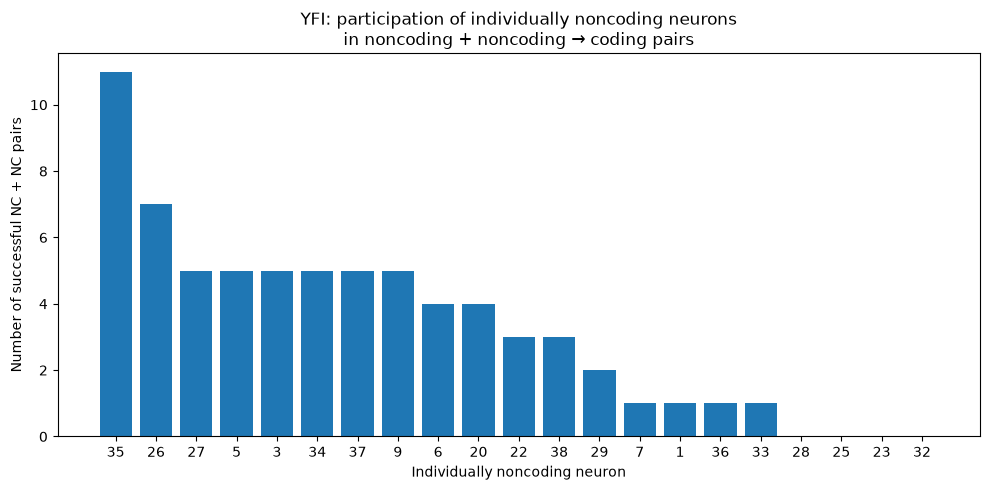


Saved: C:\Users\shafi\number-simplex-reproduction\tables1\YFI_noncoding_neuron_pair_success.csv


In [18]:
# ============================================================
# YFI: WHICH NONCODING NEURONS DRIVE NC+NC -> CODING PAIRS?
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Load matched YFI singles and NC+NC pairs
# ------------------------------------------------------------

single = pd.read_csv(
    TABLES_DIR / "single_YFI_9fold.csv"
)

nn = pd.read_csv(
    TABLES_DIR / "pairing_YFI_noncoding_plus_noncoding.csv"
)


# ------------------------------------------------------------
# 2. Get individually noncoding neurons
# ------------------------------------------------------------

noncoding = single[
    single["TC_coding"] == False
].copy()

noncoding_neurons = sorted(
    noncoding["neuron"].astype(int)
)

print("Noncoding neurons:", len(noncoding_neurons))
print("NC + NC pairs:", len(nn))


# ------------------------------------------------------------
# 3. Select NC+NC pairs that became coding
# ------------------------------------------------------------

successful = nn[
    nn["TC_coding"] == True
].copy()

print(
    "NC + NC -> coding pairs:",
    len(successful)
)


# ------------------------------------------------------------
# 4. Count successful partners for each neuron
# ------------------------------------------------------------

counts = pd.concat(
    [
        successful["neuron_1"],
        successful["neuron_2"],
    ]
).value_counts()


neuron_success = noncoding[
    [
        "neuron",
        "TC_accuracy",
        "TC_p",
    ]
].copy()


neuron_success["successful_coding_pairs"] = (
    neuron_success["neuron"]
    .map(counts)
    .fillna(0)
    .astype(int)
)


# Each noncoding neuron can pair with all other
# noncoding neurons

n_noncoding = len(noncoding_neurons)

neuron_success["total_possible_pairs"] = (
    n_noncoding - 1
)

neuron_success["success_rate_pct"] = (
    100
    * neuron_success["successful_coding_pairs"]
    / neuron_success["total_possible_pairs"]
)

neuron_success["TC_accuracy_pct"] = (
    100 * neuron_success["TC_accuracy"]
)


# ------------------------------------------------------------
# 5. Sort from most successful to least
# ------------------------------------------------------------

neuron_success = neuron_success.sort_values(
    "successful_coding_pairs",
    ascending=False,
).reset_index(drop=True)


# ------------------------------------------------------------
# 6. Display
# ------------------------------------------------------------

display(
    neuron_success[
        [
            "neuron",
            "TC_accuracy_pct",
            "TC_p",
            "successful_coding_pairs",
            "success_rate_pct",
        ]
    ].round(3)
)


# ------------------------------------------------------------
# 7. Plot successful-pair participation
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.bar(
    neuron_success["neuron"].astype(str),
    neuron_success["successful_coding_pairs"],
)

plt.xlabel("Individually noncoding neuron")
plt.ylabel("Number of successful NC + NC pairs")

plt.title(
    "YFI: participation of individually noncoding neurons\n"
    "in noncoding + noncoding → coding pairs"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Save
# ------------------------------------------------------------

neuron_success.to_csv(
    TABLES_DIR / "YFI_noncoding_neuron_pair_success.csv",
    index=False,
)

print(
    "\nSaved:",
    TABLES_DIR / "YFI_noncoding_neuron_pair_success.csv"
)

YFI NONCODING NEURONS
Accuracy vs pair-success rate:
Spearman rho = 0.857, p = 0.0000

Single-neuron p-value vs pair-success rate:
Spearman rho = -0.844, p = 0.0000


,neuron,TC_accuracy_pct,TC_p,successful_coding_pairs,success_rate_pct
0,35,18.269,0.055,11,55.0
1,26,18.269,0.060,7,35.0
2,27,17.308,0.090,5,25.0
3,5,16.346,0.090,5,25.0
4,3,16.346,0.085,5,25.0
5,34,16.346,0.124,5,25.0
6,37,16.346,0.090,5,25.0
7,9,15.385,0.104,5,25.0
8,6,15.385,0.159,4,20.0
9,20,17.308,0.065,4,20.0


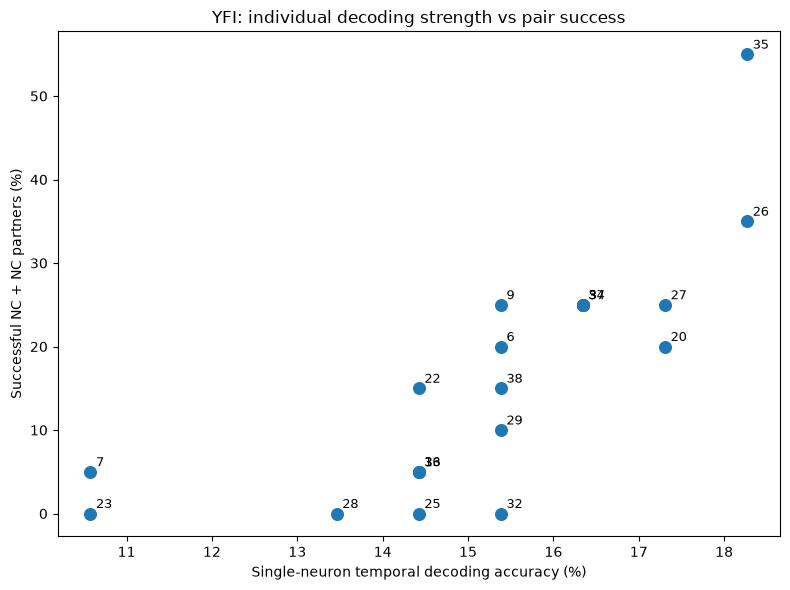

In [19]:
# ============================================================
# YFI: DOES SINGLE-NEURON STRENGTH PREDICT PAIR SUCCESS?
# ============================================================

from scipy.stats import spearmanr
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Correlation with single-neuron decoding accuracy
# ------------------------------------------------------------

rho_acc, p_acc = spearmanr(
    neuron_success["TC_accuracy_pct"],
    neuron_success["success_rate_pct"]
)

# ------------------------------------------------------------
# 2. Correlation with single-neuron permutation p-value
# ------------------------------------------------------------

rho_p, p_p = spearmanr(
    neuron_success["TC_p"],
    neuron_success["success_rate_pct"]
)


print("YFI NONCODING NEURONS")
print("=" * 55)

print(
    f"Accuracy vs pair-success rate:\n"
    f"Spearman rho = {rho_acc:.3f}, "
    f"p = {p_acc:.4f}"
)

print()

print(
    f"Single-neuron p-value vs pair-success rate:\n"
    f"Spearman rho = {rho_p:.3f}, "
    f"p = {p_p:.4f}"
)


# ------------------------------------------------------------
# 3. Show complete ranked table
# ------------------------------------------------------------

display(
    neuron_success[
        [
            "neuron",
            "TC_accuracy_pct",
            "TC_p",
            "successful_coding_pairs",
            "success_rate_pct",
        ]
    ]
    .sort_values(
        "successful_coding_pairs",
        ascending=False
    )
    .round(3)
)


# ------------------------------------------------------------
# 4. Scatter: accuracy vs pair success
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    neuron_success["TC_accuracy_pct"],
    neuron_success["success_rate_pct"],
    s=70,
)

for _, row in neuron_success.iterrows():

    plt.annotate(
        str(int(row["neuron"])),
        (
            row["TC_accuracy_pct"],
            row["success_rate_pct"],
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=9,
    )

plt.xlabel("Single-neuron temporal decoding accuracy (%)")
plt.ylabel("Successful NC + NC partners (%)")

plt.title(
    "YFI: individual decoding strength vs pair success"
)

plt.tight_layout()
plt.show()

In [20]:
neuron_success.loc[
    neuron_success["neuron"] == 35,
    ["neuron", "TC_accuracy_pct", "TC_p",
     "successful_coding_pairs", "success_rate_pct"]
]

,neuron,TC_accuracy_pct,TC_p,successful_coding_pairs,success_rate_pct
0,35,18.269231,0.054726,11,55.0


| | YFF neuron 34 | YFI neuron 35 |
|---|---:|---:|
| Single TC accuracy | 18.35% | 18.27% |
| Permutation \(p\) | 0.055 | 0.0547 |
| Classified | Noncoding | Noncoding |
| Successful NC partners | 14/26 | 11/20 |
| Success rate | 53.8% | 55.0% |

In [21]:
# ============================================================
# YFI: PER-NUMBER COMPLEMENTARITY IN NC + NC PAIRS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.firing_rate_tuning import analyze_neuron
from src.number_decoding_analysis import (
    make_temporal_features,
    cv_lda_per_number_accuracy,
)


SUBJECT = "YFI"


# ============================================================
# 1. LOAD TABLES
# ============================================================

single = pd.read_csv(
    TABLES_DIR / "single_YFI_9fold.csv"
)

nn = pd.read_csv(
    TABLES_DIR / "pairing_YFI_noncoding_plus_noncoding.csv"
)

print("NC + NC pairs:", len(nn))
print("Successful:", nn["TC_coding"].sum())
print("Unsuccessful:", (~nn["TC_coding"]).sum())


# ============================================================
# 2. GET ALL NONCODING NEURONS
# ============================================================

noncoding_neurons = sorted(
    single.loc[
        single["TC_coding"] == False,
        "neuron"
    ].astype(int)
)

print("\nNoncoding neurons:", len(noncoding_neurons))


# ============================================================
# 3. COMPUTE PER-NUMBER PROFILE FOR EACH NONCODING NEURON
#
# IMPORTANT:
# Use each neuron's OWN previously selected best bin and gamma.
# No new hyperparameter selection is performed here.
# ============================================================

profiles = {}

for k, neuron in enumerate(noncoding_neurons, start=1):

    row = single.loc[
        single["neuron"] == neuron
    ].iloc[0]

    best_bin = int(row["TC_best_bin_ms"])
    best_gamma = float(row["TC_best_gamma"])

    result = analyze_neuron(
        SUBJECT,
        neuron,
        root=ROOT,
        plot=False,
        verbose=False,
    )

    presentations = result["presentations"]
    spike_times = result["spike_times"]

    X, y, _ = make_temporal_features(
        presentations,
        spike_times,
        bin_size=best_bin,
    )

    # --------------------------------------------------------
    # Per-number CV decoding accuracy
    # --------------------------------------------------------

    per_number = cv_lda_per_number_accuracy(
        X,
        y,
        gamma=best_gamma,
        n_splits=9,
        random_state=42,
    )

    # Handle either dict or array-like return
    if isinstance(per_number, dict):

        profile = np.array(
            [per_number[n] for n in range(1, 10)],
            dtype=float,
        )

    else:
        profile = np.asarray(
            per_number,
            dtype=float,
        )

    profiles[neuron] = profile

    print(
        f"{k:>2}/{len(noncoding_neurons)} | "
        f"neuron {neuron:>2} | "
        f"bin={best_bin:>3} ms | "
        f"gamma={best_gamma:.1f}"
    )


# ============================================================
# 4. COMPLEMENTARITY METRICS
# ============================================================
#
# Metric 1: profile correlation
#
# High positive correlation:
#     neurons tend to succeed/fail on the SAME numbers
#
# Low or negative correlation:
#     neurons have different number-specific strengths
#
#
# Metric 2: profile distance
#
# Mean absolute difference between their nine
# per-number decoding accuracies.
#
# Larger distance = more different profiles.
#
# ============================================================

rows = []

for _, pair in nn.iterrows():

    n1 = int(pair["neuron_1"])
    n2 = int(pair["neuron_2"])

    p1 = profiles[n1]
    p2 = profiles[n2]

    # --------------------------------------------------------
    # Pearson correlation between 9-number profiles
    # --------------------------------------------------------

    if (
        np.std(p1) > 0
        and np.std(p2) > 0
    ):
        profile_corr = np.corrcoef(
            p1,
            p2
        )[0, 1]

    else:
        profile_corr = np.nan

    # --------------------------------------------------------
    # Mean absolute profile difference
    # --------------------------------------------------------

    profile_distance = np.mean(
        np.abs(p1 - p2)
    )

    rows.append({
        "neuron_1": n1,
        "neuron_2": n2,

        "pair_accuracy":
            pair["TC_accuracy"],

        "pair_p":
            pair["TC_p"],

        "pair_coding":
            bool(pair["TC_coding"]),

        "pair_gain":
            pair["TC_pair_gain"],

        "profile_correlation":
            profile_corr,

        "profile_distance":
            profile_distance,
    })


comp = pd.DataFrame(rows)


# ============================================================
# 5. SPLIT SUCCESSFUL AND UNSUCCESSFUL PAIRS
# ============================================================

successful = comp[
    comp["pair_coding"]
].copy()

unsuccessful = comp[
    ~comp["pair_coding"]
].copy()


print("\n")
print("=" * 65)
print("YFI NC + NC COMPLEMENTARITY")
print("=" * 65)

print(
    f"\nSuccessful NC+NC -> coding pairs: "
    f"{len(successful)}"
)

print(
    f"Unsuccessful NC+NC pairs: "
    f"{len(unsuccessful)}"
)


# ============================================================
# 6. COMPARE PROFILE CORRELATION
# ============================================================

print("\nPROFILE CORRELATION")
print("-" * 65)

print(
    "Successful pairs mean correlation:",
    round(
        successful[
            "profile_correlation"
        ].mean(),
        3,
    )
)

print(
    "Unsuccessful pairs mean correlation:",
    round(
        unsuccessful[
            "profile_correlation"
        ].mean(),
        3,
    )
)


# ============================================================
# 7. COMPARE PROFILE DISTANCE
# ============================================================

print("\nPROFILE DISTANCE")
print("-" * 65)

print(
    "Successful pairs mean distance:",
    round(
        successful[
            "profile_distance"
        ].mean(),
        4,
    )
)

print(
    "Unsuccessful pairs mean distance:",
    round(
        unsuccessful[
            "profile_distance"
        ].mean(),
        4,
    )
)


# ============================================================
# 8. TOP SUCCESSFUL PAIRS BY PAIR GAIN
# ============================================================

print("\nTOP SUCCESSFUL PAIRS BY GAIN")
print("-" * 65)

display(
    successful[
        [
            "neuron_1",
            "neuron_2",
            "pair_accuracy",
            "pair_p",
            "pair_gain",
            "profile_correlation",
            "profile_distance",
        ]
    ]
    .sort_values(
        "pair_gain",
        ascending=False,
    )
    .head(15)
    .round(3)
)


# ============================================================
# 9. VISUAL COMPARISON
# ============================================================

plot_data = [
    successful[
        "profile_correlation"
    ].dropna(),

    unsuccessful[
        "profile_correlation"
    ].dropna(),
]

plt.figure(figsize=(7, 5))

plt.boxplot(
    plot_data,
    tick_labels=[
        "NC+NC → coding",
        "NC+NC → noncoding",
    ],
)

plt.ylabel(
    "Correlation between per-number decoding profiles"
)

plt.title(
    "YFI: are successful neuron pairs more complementary?"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.tight_layout()
plt.show()


# ============================================================
# 10. SAVE
# ============================================================

comp.to_csv(
    TABLES_DIR /
    "YFI_NCNC_per_number_complementarity.csv",
    index=False,
)

print(
    "\nSaved:",
    TABLES_DIR /
    "YFI_NCNC_per_number_complementarity.csv"
)

NC + NC pairs: 210
Successful: 34
Unsuccessful: 176

Noncoding neurons: 21


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (4,) + inhomogeneous part.

In [22]:
# ============================================================
# CHECK RETURN FORMAT OF cv_lda_per_number_accuracy
# ============================================================

# Use the first noncoding neuron
neuron = noncoding_neurons[0]

row = single.loc[
    single["neuron"] == neuron
].iloc[0]

best_bin = int(row["TC_best_bin_ms"])
best_gamma = float(row["TC_best_gamma"])

result = analyze_neuron(
    SUBJECT,
    neuron,
    root=ROOT,
    plot=False,
    verbose=False,
)

X, y, _ = make_temporal_features(
    result["presentations"],
    result["spike_times"],
    bin_size=best_bin,
)

test_output = cv_lda_per_number_accuracy(
    X,
    y,
    gamma=best_gamma,
    n_splits=9,
    random_state=42,
)

print("Type:", type(test_output))

if isinstance(test_output, tuple):
    print("Tuple length:", len(test_output))

    for i, item in enumerate(test_output):
        print()
        print(f"Element {i}")
        print("  type:", type(item))

        try:
            print("  shape:", np.asarray(item).shape)
        except Exception:
            pass

        print("  value:", item)
else:
    print(test_output)

Type: <class 'tuple'>
Tuple length: 4

Element 0
  type: <class 'numpy.float64'>
  shape: ()
  value: 0.14423076923076922

Element 1
  type: <class 'dict'>
  shape: ()
  value: {1: np.float64(0.1), 2: np.float64(0.18181818181818182), 3: np.float64(0.18181818181818182), 4: np.float64(0.18181818181818182), 5: np.float64(0.2222222222222222), 6: np.float64(0.2), 7: np.float64(0.1), 8: np.float64(0.08695652173913043), 9: np.float64(0.1111111111111111)}

Element 2
  type: <class 'numpy.ndarray'>
  shape: (104,)
  value: [7 3 6 1 4 5 3 9 2 8 2 8 1 9 3 4 8 7 8 2 3 6 2 5 1 8 6 5 8 4 9 3 2 7 7 6 3
 2 8 6 4 8 4 8 9 5 7 1 8 1 5 7 9 6 4 8 4 3 8 2 7 8 1 5 9 6 2 8 8 3 4 8 2 1
 5 3 6 9 8 4 8 7 1 3 6 4 7 8 5 2 9 8 8 8 8 4 3 6 2 7 1 9 5 1]

Element 3
  type: <class 'numpy.ndarray'>
  shape: (104,)
  value: [5 6 4 9 8 3 2 7 7 4 2 9 4 7 3 9 3 2 3 1 2 6 6 7 9 6 9 2 6 4 8 6 5 3 1 2 1
 5 1 2 8 1 1 6 1 4 1 1 1 4 5 4 9 4 7 4 7 5 8 7 9 3 2 5 1 6 2 9 9 8 4 4 4 7
 7 9 8 3 6 7 3 7 5 8 4 1 5 7 7 8 8 8 9 4 3 5 3 5 7

NC + NC pairs: 210
Successful: 34
Unsuccessful: 176
Noncoding neurons: 21
 1/21 | neuron  1 | overall=14.42% | bin= 90 ms | gamma=0.2
 2/21 | neuron  3 | overall=16.35% | bin= 90 ms | gamma=0.2
 3/21 | neuron  5 | overall=16.35% | bin=180 ms | gamma=0.2
 4/21 | neuron  6 | overall=15.38% | bin= 75 ms | gamma=0.2
 5/21 | neuron  7 | overall=10.58% | bin=100 ms | gamma=0.2
 6/21 | neuron  9 | overall=15.38% | bin=225 ms | gamma=0.8
 7/21 | neuron 20 | overall=17.31% | bin=150 ms | gamma=0.2
 8/21 | neuron 22 | overall=14.42% | bin= 75 ms | gamma=0.5
 9/21 | neuron 23 | overall=10.58% | bin=900 ms | gamma=0.2
10/21 | neuron 25 | overall=14.42% | bin= 90 ms | gamma=0.2
11/21 | neuron 26 | overall=18.27% | bin= 60 ms | gamma=0.8
12/21 | neuron 27 | overall=17.31% | bin= 90 ms | gamma=0.2
13/21 | neuron 28 | overall=13.46% | bin=300 ms | gamma=0.2
14/21 | neuron 29 | overall=15.38% | bin= 75 ms | gamma=0.8
15/21 | neuron 32 | overall=15.38% | bin=100 ms | gamma=0.2
16/21 | neuron 33 | overal

,neuron_1,neuron_2,pair_accuracy,pair_p,pair_gain,profile_correlation,profile_distance
100,9,34,0.212,0.010,0.048,0.103,0.167
47,5,27,0.212,0.010,0.038,-0.091,0.207
202,34,37,0.202,0.010,0.038,0.297,0.175
128,22,35,0.221,0.015,0.038,-0.029,0.203
58,6,9,0.192,0.040,0.038,0.120,0.099
21,3,6,0.192,0.020,0.029,0.245,0.093
198,33,37,0.192,0.035,0.029,0.008,0.142
164,26,38,0.212,0.010,0.029,0.059,0.119
90,9,20,0.202,0.010,0.029,0.379,0.086
41,5,9,0.192,0.035,0.029,-0.489,0.211


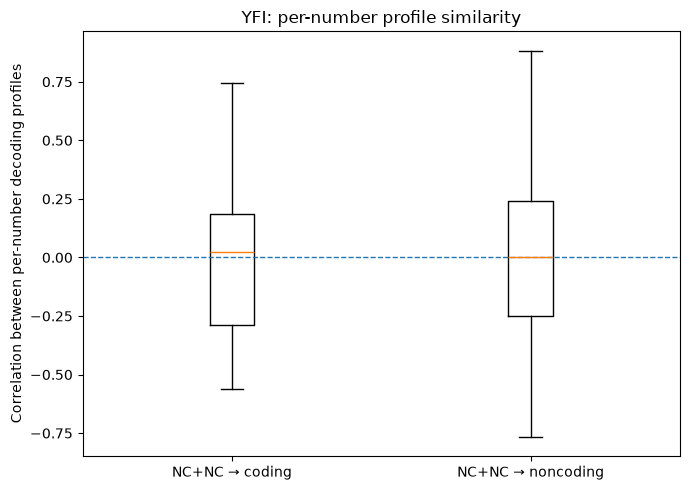


Saved: C:\Users\shafi\number-simplex-reproduction\tables1\YFI_NCNC_per_number_complementarity.csv


In [23]:
# ============================================================
# YFI: PER-NUMBER COMPLEMENTARITY IN NC + NC PAIRS
# CORRECTED VERSION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.firing_rate_tuning import analyze_neuron
from src.number_decoding_analysis import (
    make_temporal_features,
    cv_lda_per_number_accuracy,
)

SUBJECT = "YFI"


# ============================================================
# 1. LOAD DATA
# ============================================================

single = pd.read_csv(
    TABLES_DIR / "single_YFI_9fold.csv"
)

nn = pd.read_csv(
    TABLES_DIR / "pairing_YFI_noncoding_plus_noncoding.csv"
)

print("NC + NC pairs:", len(nn))
print("Successful:", int(nn["TC_coding"].sum()))
print("Unsuccessful:", int((~nn["TC_coding"]).sum()))


# ============================================================
# 2. NONCODING NEURONS
# ============================================================

noncoding_neurons = sorted(
    single.loc[
        single["TC_coding"] == False,
        "neuron"
    ].astype(int)
)

print("Noncoding neurons:", len(noncoding_neurons))


# ============================================================
# 3. PER-NUMBER PROFILE OF EACH NONCODING NEURON
# ============================================================

profiles = {}

for k, neuron in enumerate(noncoding_neurons, start=1):

    row = single.loc[
        single["neuron"] == neuron
    ].iloc[0]

    best_bin = int(
        row["TC_best_bin_ms"]
    )

    best_gamma = float(
        row["TC_best_gamma"]
    )

    result = analyze_neuron(
        SUBJECT,
        neuron,
        root=ROOT,
        plot=False,
        verbose=False,
    )

    X, y, _ = make_temporal_features(
        result["presentations"],
        result["spike_times"],
        bin_size=best_bin,
    )

    # --------------------------------------------------------
    # CORRECT UNPACKING
    # --------------------------------------------------------

    (
        overall_acc,
        per_number,
        y_true,
        y_pred,
    ) = cv_lda_per_number_accuracy(
        X,
        y,
        gamma=best_gamma,
        n_splits=9,
        random_state=42,
    )

    # Convert dictionary {1: acc, ..., 9: acc}
    # into a fixed 9-element vector

    profile = np.array(
        [
            per_number[number]
            for number in range(1, 10)
        ],
        dtype=float,
    )

    profiles[neuron] = profile

    print(
        f"{k:>2}/{len(noncoding_neurons)} | "
        f"neuron {neuron:>2} | "
        f"overall={100*overall_acc:.2f}% | "
        f"bin={best_bin:>3} ms | "
        f"gamma={best_gamma:.1f}"
    )


# ============================================================
# 4. CALCULATE PROFILE RELATIONSHIP FOR EVERY NC+NC PAIR
# ============================================================

rows = []

for _, pair in nn.iterrows():

    n1 = int(pair["neuron_1"])
    n2 = int(pair["neuron_2"])

    p1 = profiles[n1]
    p2 = profiles[n2]

    # --------------------------------------------------------
    # Correlation between the two 9-number profiles
    # --------------------------------------------------------

    if np.std(p1) > 0 and np.std(p2) > 0:

        profile_corr = np.corrcoef(
            p1,
            p2,
        )[0, 1]

    else:
        profile_corr = np.nan

    # --------------------------------------------------------
    # Mean absolute difference
    # --------------------------------------------------------

    profile_distance = np.mean(
        np.abs(p1 - p2)
    )

    rows.append({

        "neuron_1": n1,
        "neuron_2": n2,

        "pair_accuracy":
            pair["TC_accuracy"],

        "pair_p":
            pair["TC_p"],

        "pair_coding":
            bool(pair["TC_coding"]),

        "pair_gain":
            pair["TC_pair_gain"],

        "profile_correlation":
            profile_corr,

        "profile_distance":
            profile_distance,
    })


comp = pd.DataFrame(rows)


# ============================================================
# 5. SUCCESSFUL VS UNSUCCESSFUL
# ============================================================

successful = comp[
    comp["pair_coding"]
].copy()

unsuccessful = comp[
    ~comp["pair_coding"]
].copy()


print()
print("=" * 65)
print("YFI NC + NC COMPLEMENTARITY")
print("=" * 65)

print(
    f"Successful NC+NC -> coding: "
    f"{len(successful)}"
)

print(
    f"Unsuccessful NC+NC: "
    f"{len(unsuccessful)}"
)


# ============================================================
# 6. PROFILE CORRELATION
# ============================================================

print()
print("PROFILE CORRELATION")
print("-" * 65)

print(
    f"Successful mean correlation: "
    f"{successful['profile_correlation'].mean():.3f}"
)

print(
    f"Unsuccessful mean correlation: "
    f"{unsuccessful['profile_correlation'].mean():.3f}"
)


# ============================================================
# 7. PROFILE DISTANCE
# ============================================================

print()
print("PROFILE DISTANCE")
print("-" * 65)

print(
    f"Successful mean distance: "
    f"{successful['profile_distance'].mean():.4f}"
)

print(
    f"Unsuccessful mean distance: "
    f"{unsuccessful['profile_distance'].mean():.4f}"
)


# ============================================================
# 8. TOP SUCCESSFUL PAIRS
# ============================================================

print()
print("TOP SUCCESSFUL PAIRS BY GAIN")
print("-" * 65)

top_successful = (
    successful[
        [
            "neuron_1",
            "neuron_2",
            "pair_accuracy",
            "pair_p",
            "pair_gain",
            "profile_correlation",
            "profile_distance",
        ]
    ]
    .sort_values(
        "pair_gain",
        ascending=False,
    )
    .head(15)
)

display(
    top_successful.round(3)
)


# ============================================================
# 9. BOXPLOT
# ============================================================

plt.figure(figsize=(7, 5))

plt.boxplot(
    [
        successful[
            "profile_correlation"
        ].dropna(),

        unsuccessful[
            "profile_correlation"
        ].dropna(),
    ],
    tick_labels=[
        "NC+NC → coding",
        "NC+NC → noncoding",
    ],
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.ylabel(
    "Correlation between per-number decoding profiles"
)

plt.title(
    "YFI: per-number profile similarity"
)

plt.tight_layout()
plt.show()


# ============================================================
# 10. SAVE
# ============================================================

comp.to_csv(
    TABLES_DIR /
    "YFI_NCNC_per_number_complementarity.csv",
    index=False,
)

print(
    "\nSaved:",
    TABLES_DIR /
    "YFI_NCNC_per_number_complementarity.csv"
)

# Decoder comparision

YFU.hpc.43
X shape: (494, 6)
Number of observations: 494
Number of temporal features: 6
Bin edges: [ 50. 200. 350. 500. 650. 800. 950.]

Class counts:
Number 1: 53
Number 2: 67
Number 3: 52
Number 4: 62
Number 5: 51
Number 6: 48
Number 7: 65
Number 8: 49
Number 9: 47

Minimum class count: 47

OBSERVED 10-FOLD CV ACCURACY
LDA                       11.94%
Logistic Regression       11.94%


c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\sha

Linear SVM                12.75%

PERMUTATION TEST

LDA
Observed accuracy : 11.94%
Null mean         : 10.94%
Null SD           : 1.95%
Permutation p     : 0.33831
Number coding     : False


c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\sha


Logistic Regression
Observed accuracy : 11.94%
Null mean         : 12.21%
Null SD           : 1.92%
Permutation p     : 0.58706
Number coding     : False

Linear SVM
Observed accuracy : 12.75%
Null mean         : 12.57%
Null SD           : 1.80%
Permutation p     : 0.48259
Number coding     : False

FINAL COMPARISON


,decoder,accuracy_pct,null_mean_pct,null_sd_pct,p_value,number_coding
0,LDA,11.943,10.941,1.947,0.338,False
1,Logistic Regression,11.943,12.205,1.921,0.587,False
2,Linear SVM,12.753,12.573,1.797,0.483,False


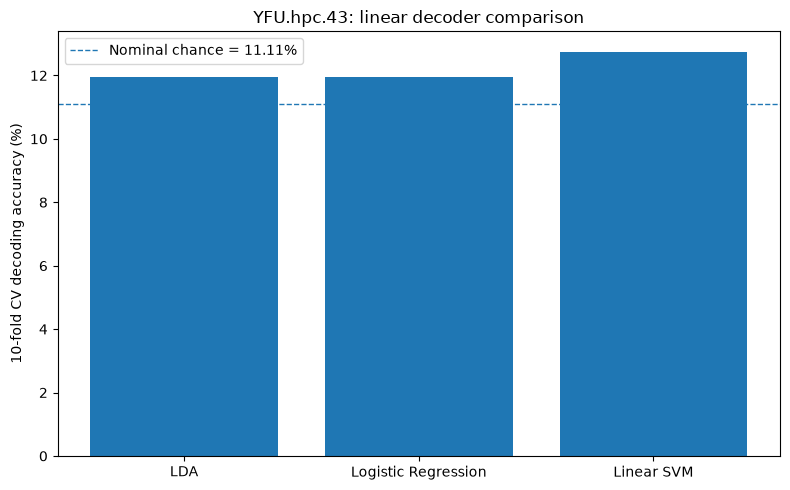

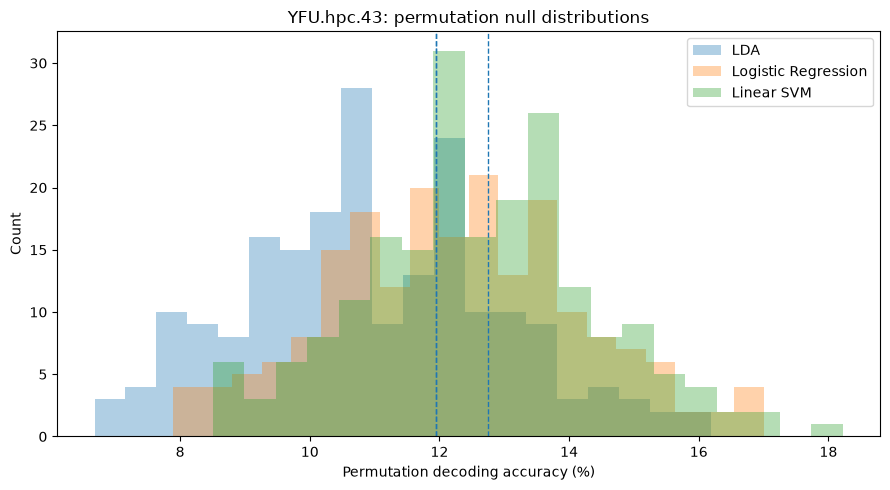

In [24]:
# ============================================================
# YFU.hpc.43
# Compare 3 linear decoders:
#
#   1. LDA
#   2. Multinomial Logistic Regression
#   3. Linear SVM
#
# Same neuron
# Same trials
# Same labels
# Same 150-ms temporal representation
# Same CV folds
# Same permutations
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from src.firing_rate_tuning import analyze_neuron
from src.number_decoding_analysis import make_temporal_features


# ============================================================
# SETTINGS
# ============================================================

SUBJECT = "YFU"

# MATLAB neuron 43 = Python row/index 42
NEURON = 42

BIN_SIZE = 150

N_SPLITS = 10
N_PERMUTATIONS = 200

CV_RANDOM_STATE = 42
PERMUTATION_SEED = 12345


# ============================================================
# 1. LOAD YFU.hpc.43
# ============================================================

result = analyze_neuron(
    SUBJECT,
    NEURON,
    root=ROOT,
    plot=False,
    verbose=False,
)

presentations = result["presentations"]
spike_times = result["spike_times"]


# ============================================================
# 2. TEMPORAL FEATURES
# ============================================================

X, y, bin_edges = make_temporal_features(
    presentations,
    spike_times,
    bin_size=BIN_SIZE,
)

print("=" * 65)
print("YFU.hpc.43")
print("=" * 65)

print("X shape:", X.shape)
print("Number of observations:", len(y))
print("Number of temporal features:", X.shape[1])
print("Bin edges:", bin_edges)

classes, counts = np.unique(y, return_counts=True)

print("\nClass counts:")

for c, n in zip(classes, counts):
    print(f"Number {c}: {n}")

print("\nMinimum class count:", counts.min())


# ============================================================
# 3. DEFINE THREE CLASSIFIERS
# ============================================================
#
# LDA:
# same style used in the paper.
# We freeze gamma = 0.2 because this was the previously
# selected value for YFU.hpc.43.
#
# Logistic regression and SVM:
# standardized within each training fold using Pipeline.
#
# IMPORTANT:
# scaler is fitted ONLY on training data inside each CV fold.
# ============================================================

classifiers = {

    "LDA": LinearDiscriminantAnalysis(
        solver="lsqr",
        shrinkage=0.2,
        priors=np.ones(9) / 9,
    ),

    "Logistic Regression": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                penalty="l2",
                C=1.0,
                solver="lbfgs",
                max_iter=5000,
                random_state=CV_RANDOM_STATE,
            )
        )
    ]),

    "Linear SVM": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            SVC(
                kernel="linear",
                C=1.0,
            )
        )
    ]),
}


# ============================================================
# 4. CREATE THE SAME 10 CV FOLDS FOR ALL CLASSIFIERS
# ============================================================

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=CV_RANDOM_STATE,
)

cv_splits = list(
    cv.split(X, y)
)


# ============================================================
# 5. CV FUNCTION
# ============================================================

def cv_accuracy(model, X, y, splits):

    predictions = np.empty_like(y)

    for train_idx, test_idx in splits:

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]

        model.fit(
            X_train,
            y_train,
        )

        predictions[test_idx] = model.predict(
            X_test
        )

    accuracy = np.mean(
        predictions == y
    )

    return accuracy, predictions


# ============================================================
# 6. OBSERVED ACCURACY
# ============================================================

observed = {}
observed_predictions = {}

print()
print("=" * 65)
print("OBSERVED 10-FOLD CV ACCURACY")
print("=" * 65)

for name, model in classifiers.items():

    acc, pred = cv_accuracy(
        model,
        X,
        y,
        cv_splits,
    )

    observed[name] = acc
    observed_predictions[name] = pred

    print(
        f"{name:<25} "
        f"{100 * acc:.2f}%"
    )


# ============================================================
# 7. CREATE SAME 200 PERMUTED LABEL SETS
#
# Every decoder receives exactly the same shuffled labels.
# ============================================================

rng = np.random.default_rng(
    PERMUTATION_SEED
)

permuted_labels = [
    rng.permutation(y)
    for _ in range(N_PERMUTATIONS)
]


# ============================================================
# 8. PERMUTATION TEST
# ============================================================

null_distributions = {}

print()
print("=" * 65)
print("PERMUTATION TEST")
print("=" * 65)

for name, model in classifiers.items():

    null_acc = np.empty(
        N_PERMUTATIONS
    )

    for p, y_perm in enumerate(
        permuted_labels
    ):

        # ----------------------------------------------------
        # Recreate stratified CV folds using shuffled labels
        #
        # This follows the same logic as our existing
        # permutation analysis.
        # ----------------------------------------------------

        perm_cv = StratifiedKFold(
            n_splits=N_SPLITS,
            shuffle=True,
            random_state=CV_RANDOM_STATE,
        )

        perm_splits = list(
            perm_cv.split(
                X,
                y_perm,
            )
        )

        perm_acc, _ = cv_accuracy(
            model,
            X,
            y_perm,
            perm_splits,
        )

        null_acc[p] = perm_acc

    null_distributions[name] = null_acc

    obs = observed[name]

    p_value = (
        1
        +
        np.sum(
            null_acc >= obs
        )
    ) / (
        1
        +
        N_PERMUTATIONS
    )

    coding = p_value < 0.05

    print()
    print(name)

    print(
        f"Observed accuracy : "
        f"{100 * obs:.2f}%"
    )

    print(
        f"Null mean         : "
        f"{100 * null_acc.mean():.2f}%"
    )

    print(
        f"Null SD           : "
        f"{100 * null_acc.std(ddof=1):.2f}%"
    )

    print(
        f"Permutation p     : "
        f"{p_value:.5f}"
    )

    print(
        f"Number coding     : "
        f"{coding}"
    )


# ============================================================
# 9. FINAL SUMMARY TABLE
# ============================================================

summary_rows = []

for name in classifiers:

    null_acc = null_distributions[name]

    obs = observed[name]

    p_value = (
        1
        +
        np.sum(
            null_acc >= obs
        )
    ) / (
        1
        +
        N_PERMUTATIONS
    )

    summary_rows.append({

        "decoder":
            name,

        "accuracy_pct":
            100 * obs,

        "null_mean_pct":
            100 * null_acc.mean(),

        "null_sd_pct":
            100 * null_acc.std(ddof=1),

        "p_value":
            p_value,

        "number_coding":
            p_value < 0.05,
    })


summary = pd.DataFrame(
    summary_rows
)

print()
print("=" * 65)
print("FINAL COMPARISON")
print("=" * 65)

display(
    summary.round(3)
)


# ============================================================
# 10. ACCURACY BAR PLOT
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    summary["decoder"],
    summary["accuracy_pct"],
)

plt.axhline(
    100 / 9,
    linestyle="--",
    linewidth=1,
    label="Nominal chance = 11.11%",
)

plt.ylabel(
    "10-fold CV decoding accuracy (%)"
)

plt.title(
    "YFU.hpc.43: linear decoder comparison"
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 11. NULL DISTRIBUTIONS
# ============================================================

plt.figure(
    figsize=(9, 5)
)

for name in classifiers:

    plt.hist(
        100 * null_distributions[name],
        bins=20,
        alpha=0.35,
        label=name,
    )

    plt.axvline(
        100 * observed[name],
        linestyle="--",
        linewidth=1,
    )

plt.xlabel(
    "Permutation decoding accuracy (%)"
)

plt.ylabel(
    "Count"
)

plt.title(
    "YFU.hpc.43: permutation null distributions"
)

plt.legend()

plt.tight_layout()
plt.show()

In [26]:
from src.firing_rate_tuning import analyze_neuron
from src.number_decoding_analysis import (
    make_temporal_features,
    cv_lda_accuracy,
)

for neuron_id in [42, 43]:

    result = analyze_neuron(
        "YFU",
        neuron_id,
        root=ROOT,
        plot=False,
        verbose=False,
    )

    X, y, _ = make_temporal_features(
        result["presentations"],
        result["spike_times"],
        bin_size=150,
    )

    acc = cv_lda_accuracy(
        X,
        y,
        gamma=0.2,
        n_splits=10,
        random_state=42,
    )

    print(
        f"neuron argument = {neuron_id} | "
        f"X = {X.shape} | "
        f"LDA = {100*acc:.3f}%"
    )

neuron argument = 42 | X = (494, 6) | LDA = 11.943%
neuron argument = 43 | X = (494, 6) | LDA = 16.397%


In [27]:
from src.firing_rate_tuning import analyze_neuron
from src.number_decoding_analysis import (
    make_temporal_features,
    cv_lda_accuracy,
)

for neuron_id in [42, 43]:

    result = analyze_neuron(
        "YFU",
        neuron_id,
        root=ROOT,
        plot=False,
        verbose=False,
    )

    X, y, _ = make_temporal_features(
        result["presentations"],
        result["spike_times"],
        bin_size=150,
    )

    acc = cv_lda_accuracy(
        X,
        y,
        gamma=0.2,
        n_splits=10,
        random_state=42,
    )

    print(
        f"neuron argument = {neuron_id} | "
        f"X = {X.shape} | "
        f"LDA = {100*acc:.3f}%"
    )

neuron argument = 42 | X = (494, 6) | LDA = 11.943%
neuron argument = 43 | X = (494, 6) | LDA = 16.397%


YFU.hpc.43
Neuron argument       : 43
Number of observations: 494
Feature matrix shape  : (494, 6)
Temporal bin size     : 150 ms
Number of features    : 6
Bin edges             : [ 50. 200. 350. 500. 650. 800. 950.]

Class counts:
Number 1: 53
Number 2: 67
Number 3: 52
Number 4: 62
Number 5: 51
Number 6: 48
Number 7: 65
Number 8: 49
Number 9: 47

Minimum class count: 47
Nominal chance accuracy: 11.11%

OBSERVED 10-FOLD CV ACCURACY
LDA                        16.397%
Logistic Regression        15.992%
Linear SVM                 15.992%

LDA SANITY CHECK
Expected approximately : 16.397%
Current result         : 16.397%
Difference             : -0.000 percentage points

PERMUTATION TESTS

Running: LDA
Observed accuracy : 16.397%
Null mean         : 11.194%
Null SD           : 1.773%
Permutation p     : 0.00995
Number coding     : True

Running: Logistic Regression
Observed accuracy : 15.992%
Null mean         : 11.168%
Null SD           : 1.692%
Permutation p     : 0.00498
Number coding  

,decoder,accuracy_pct,above_chance_pp,null_mean_pct,null_sd_pct,p_value,number_coding
0,LDA,16.397,5.286,11.194,1.773,0.010,True
1,Logistic Regression,15.992,4.881,11.168,1.692,0.005,True
2,Linear SVM,15.992,4.881,11.153,1.657,0.005,True


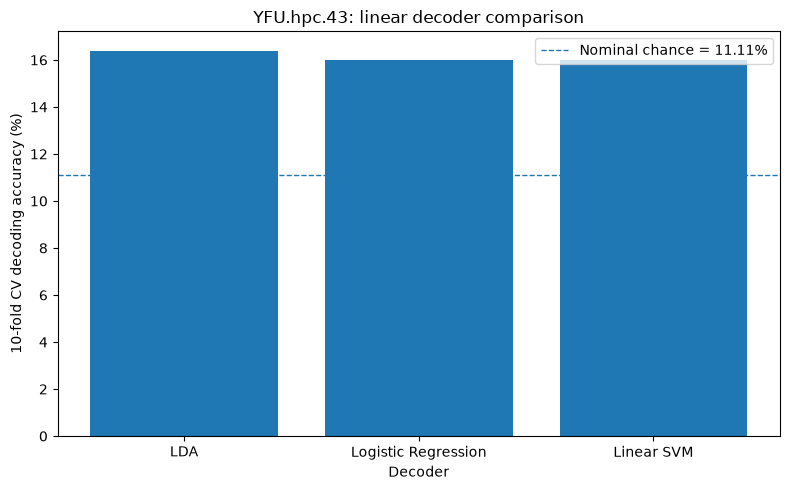

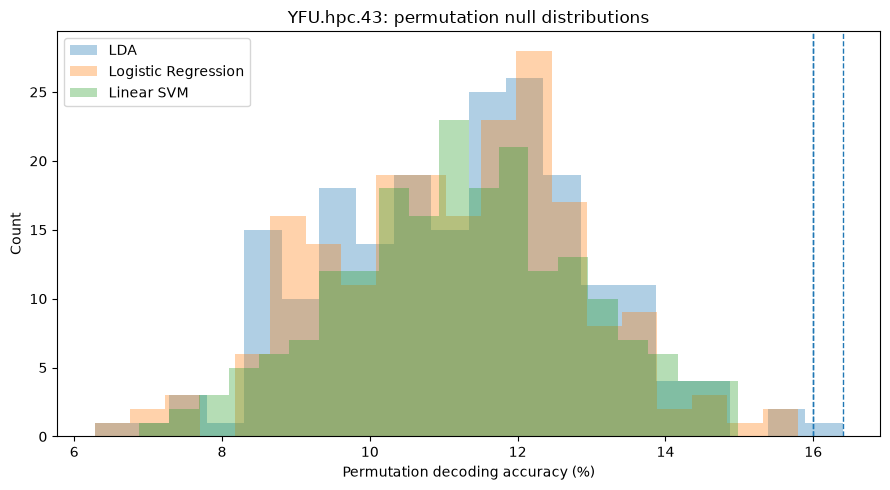


Saved: C:\Users\shafi\number-simplex-reproduction\tables1\YFU_hpc43_decoder_comparison.csv


In [28]:
# ============================================================
# YFU.hpc.43
# THREE LINEAR DECODER COMPARISON
#
# 1. LDA
# 2. Multinomial Logistic Regression
# 3. Linear SVM
#
# Representation:
#   Temporal spike counts
#   50–950 ms after number onset
#   150-ms bins -> 6 features
#
# Evaluation:
#   10-fold stratified cross-validation
#   200 label permutations
#
# Coding criterion:
#   permutation p < 0.05
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from src.firing_rate_tuning import analyze_neuron
from src.number_decoding_analysis import make_temporal_features


# ============================================================
# 1. SETTINGS
# ============================================================

SUBJECT = "YFU"

# IMPORTANT:
# analyze_neuron() expects the actual neuron number.
#
# YFU.hpc.43 -> neuron = 43
#
# DO NOT subtract 1.
NEURON = 43

# Previously selected temporal representation for this neuron
BIN_SIZE = 150

# Paper-style LDA shrinkage selected previously
LDA_GAMMA = 0.2

N_SPLITS = 10
N_PERMUTATIONS = 200

CV_RANDOM_STATE = 42
PERMUTATION_SEED = 12345


# ============================================================
# 2. LOAD YFU.hpc.43
# ============================================================

result = analyze_neuron(
    SUBJECT,
    NEURON,
    root=ROOT,
    plot=False,
    verbose=False,
)

presentations = result["presentations"]
spike_times = result["spike_times"]


# ============================================================
# 3. CREATE TEMPORAL FEATURES
# ============================================================

X, y, bin_edges = make_temporal_features(
    presentations,
    spike_times,
    bin_size=BIN_SIZE,
)

classes, counts = np.unique(
    y,
    return_counts=True,
)


print("=" * 70)
print("YFU.hpc.43")
print("=" * 70)

print(f"Neuron argument       : {NEURON}")
print(f"Number of observations: {len(y)}")
print(f"Feature matrix shape  : {X.shape}")
print(f"Temporal bin size     : {BIN_SIZE} ms")
print(f"Number of features    : {X.shape[1]}")
print(f"Bin edges             : {bin_edges}")

print("\nClass counts:")

for number, count in zip(classes, counts):
    print(
        f"Number {number}: {count}"
    )

print(
    "\nMinimum class count:",
    counts.min()
)

print(
    "Nominal chance accuracy:",
    f"{100/9:.2f}%"
)


# ============================================================
# 4. DEFINE THE THREE CLASSIFIERS
# ============================================================
#
# LDA:
#   Same shrinkage structure as paper.
#   Uniform prior = 1/9 for each number.
#
#
# Logistic Regression:
#   Multiclass logistic regression.
#   L2 regularization via l1_ratio=0.
#   StandardScaler fitted INSIDE each training fold.
#
#
# Linear SVM:
#   Linear decision boundaries.
#   StandardScaler fitted INSIDE each training fold.
#
#
# class_weight="balanced" gives each number class approximately
# equal influence for Logistic Regression and SVM.
# ============================================================

classifiers = {

    "LDA":
        LinearDiscriminantAnalysis(
            solver="lsqr",
            shrinkage=LDA_GAMMA,
            priors=np.ones(9) / 9,
        ),

    "Logistic Regression":
        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "classifier",
                LogisticRegression(
                    C=1.0,
                    l1_ratio=0,
                    solver="lbfgs",
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=CV_RANDOM_STATE,
                )
            ),
        ]),

    "Linear SVM":
        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "classifier",
                SVC(
                    kernel="linear",
                    C=1.0,
                    class_weight="balanced",
                )
            ),
        ]),
}


# ============================================================
# 5. CROSS-VALIDATION FUNCTION
# ============================================================
#
# We explicitly supply the CV splits so all three classifiers
# are evaluated on exactly the same train/test partitions.
# ============================================================

def cv_accuracy(
    model,
    X,
    y,
    splits,
):

    predictions = np.empty_like(y)

    for train_idx, test_idx in splits:

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]

        # Fresh estimator for every fold
        fold_model = clone(model)

        fold_model.fit(
            X_train,
            y_train,
        )

        predictions[test_idx] = (
            fold_model.predict(
                X_test
            )
        )

    accuracy = np.mean(
        predictions == y
    )

    return accuracy, predictions


# ============================================================
# 6. CREATE OBSERVED 10-FOLD SPLITS
# ============================================================

observed_cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=CV_RANDOM_STATE,
)

observed_splits = list(
    observed_cv.split(
        X,
        y,
    )
)


# ============================================================
# 7. OBSERVED DECODING ACCURACY
# ============================================================

observed_accuracy = {}
observed_predictions = {}


print()
print("=" * 70)
print("OBSERVED 10-FOLD CV ACCURACY")
print("=" * 70)


for name, model in classifiers.items():

    accuracy, predictions = cv_accuracy(
        model,
        X,
        y,
        observed_splits,
    )

    observed_accuracy[name] = accuracy
    observed_predictions[name] = predictions

    print(
        f"{name:<25}"
        f"{100 * accuracy:>8.3f}%"
    )


# ============================================================
# 8. SANITY CHECK LDA
# ============================================================
#
# From our previous validated analysis:
#
# YFU.hpc.43
# 150-ms bins
# gamma = 0.2
#
# should give approximately 16.397%.
# ============================================================

print()
print("=" * 70)
print("LDA SANITY CHECK")
print("=" * 70)

print(
    "Expected approximately : 16.397%"
)

print(
    "Current result         : "
    f"{100 * observed_accuracy['LDA']:.3f}%"
)

difference = (
    100 * observed_accuracy["LDA"]
    - 16.397
)

print(
    "Difference             : "
    f"{difference:+.3f} percentage points"
)


# ============================================================
# 9. GENERATE THE SAME 200 PERMUTATIONS
# ============================================================
#
# All three classifiers see exactly the same shuffled labels.
# ============================================================

rng = np.random.default_rng(
    PERMUTATION_SEED
)

permuted_labels = [
    rng.permutation(y)
    for _ in range(N_PERMUTATIONS)
]


# ============================================================
# 10. PERMUTATION TEST
# ============================================================

null_distributions = {}


print()
print("=" * 70)
print("PERMUTATION TESTS")
print("=" * 70)


for name, model in classifiers.items():

    print()
    print(f"Running: {name}")

    null_accuracies = np.empty(
        N_PERMUTATIONS
    )

    for permutation_index, y_perm in enumerate(
        permuted_labels
    ):

        # ----------------------------------------------------
        # Create stratified folds based on the shuffled labels
        # ----------------------------------------------------

        permutation_cv = StratifiedKFold(
            n_splits=N_SPLITS,
            shuffle=True,
            random_state=CV_RANDOM_STATE,
        )

        permutation_splits = list(
            permutation_cv.split(
                X,
                y_perm,
            )
        )

        permutation_accuracy, _ = cv_accuracy(
            model,
            X,
            y_perm,
            permutation_splits,
        )

        null_accuracies[
            permutation_index
        ] = permutation_accuracy

    null_distributions[
        name
    ] = null_accuracies

    observed = observed_accuracy[
        name
    ]

    # --------------------------------------------------------
    # Paper-style permutation p-value
    # --------------------------------------------------------

    p_value = (
        1
        +
        np.sum(
            null_accuracies >= observed
        )
    ) / (
        1
        +
        N_PERMUTATIONS
    )

    coding = (
        p_value < 0.05
    )

    print(
        f"Observed accuracy : "
        f"{100 * observed:.3f}%"
    )

    print(
        f"Null mean         : "
        f"{100 * null_accuracies.mean():.3f}%"
    )

    print(
        f"Null SD           : "
        f"{100 * null_accuracies.std(ddof=1):.3f}%"
    )

    print(
        f"Permutation p     : "
        f"{p_value:.5f}"
    )

    print(
        f"Number coding     : "
        f"{coding}"
    )


# ============================================================
# 11. FINAL SUMMARY TABLE
# ============================================================

summary_rows = []


for name in classifiers:

    observed = observed_accuracy[
        name
    ]

    null_accuracies = null_distributions[
        name
    ]

    p_value = (
        1
        +
        np.sum(
            null_accuracies >= observed
        )
    ) / (
        1
        +
        N_PERMUTATIONS
    )

    summary_rows.append({

        "decoder":
            name,

        "accuracy_pct":
            100 * observed,

        "above_chance_pp":
            100 * observed
            - (100 / 9),

        "null_mean_pct":
            100 * null_accuracies.mean(),

        "null_sd_pct":
            100 * null_accuracies.std(
                ddof=1
            ),

        "p_value":
            p_value,

        "number_coding":
            p_value < 0.05,
    })


summary = pd.DataFrame(
    summary_rows
)


print()
print("=" * 70)
print("FINAL DECODER COMPARISON")
print("=" * 70)

display(
    summary.round(3)
)


# ============================================================
# 12. ACCURACY BAR PLOT
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    summary["decoder"],
    summary["accuracy_pct"],
)

plt.axhline(
    100 / 9,
    linestyle="--",
    linewidth=1,
    label="Nominal chance = 11.11%",
)

plt.ylabel(
    "10-fold CV decoding accuracy (%)"
)

plt.xlabel(
    "Decoder"
)

plt.title(
    "YFU.hpc.43: linear decoder comparison"
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 13. PERMUTATION NULL DISTRIBUTIONS
# ============================================================

plt.figure(
    figsize=(9, 5)
)


for name in classifiers:

    plt.hist(
        100 * null_distributions[name],
        bins=20,
        alpha=0.35,
        label=name,
    )

    plt.axvline(
        100 * observed_accuracy[name],
        linestyle="--",
        linewidth=1,
    )


plt.xlabel(
    "Permutation decoding accuracy (%)"
)

plt.ylabel(
    "Count"
)

plt.title(
    "YFU.hpc.43: permutation null distributions"
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 14. OPTIONAL SAVE
# ============================================================

summary.to_csv(
    TABLES_DIR /
    "YFU_hpc43_decoder_comparison.csv",
    index=False,
)

print()
print(
    "Saved:",
    TABLES_DIR /
    "YFU_hpc43_decoder_comparison.csv"
)

In [32]:
# ============================================================
# DECODER COMPARISON: YFI neuron 35
# ============================================================

SUBJECT = "YFJ"
NEURON = 15

N_SPLITS = 9          # YFI minimum class count = 9
N_PERMUTATIONS = 200

CV_RANDOM_STATE = 42
PERMUTATION_SEED = 12345


# ============================================================
# GET THIS NEURON'S PREVIOUSLY SELECTED PARAMETERS
# ============================================================

single = pd.read_csv(
    TABLES_DIR / "single_YFI_9fold.csv"
)

row = single.loc[
    single["neuron"] == NEURON
].iloc[0]

BIN_SIZE = int(
    row["TC_best_bin_ms"]
)

LDA_GAMMA = float(
    row["TC_best_gamma"]
)

print("Subject:", SUBJECT)
print("Neuron:", NEURON)
print("Best temporal bin:", BIN_SIZE, "ms")
print("LDA gamma:", LDA_GAMMA)
print("Previous LDA accuracy:", f"{100*row['TC_accuracy']:.3f}%")
print("Previous LDA p:", row["TC_p"])

IndexError: single positional indexer is out-of-bounds

YFU.hpc.43
X shape: (114, 6)
Number of observations: 114
Number of temporal features: 6
Bin edges: [ 50. 200. 350. 500. 650. 800. 950.]

Class counts:
Number 1: 19
Number 2: 17
Number 3: 14
Number 4: 4
Number 5: 14
Number 6: 16
Number 7: 10
Number 8: 12
Number 9: 8

Minimum class count: 4

OBSERVED 10-FOLD CV ACCURACY
LDA                       11.40%
Logistic Regression       14.91%


c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instea

Linear SVM                19.30%

PERMUTATION TEST


c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The l


LDA
Observed accuracy : 11.40%
Null mean         : 11.06%
Null SD           : 3.12%
Permutation p     : 0.48756
Number coding     : False


c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instea


Logistic Regression
Observed accuracy : 14.91%
Null mean         : 13.56%
Null SD           : 3.45%
Permutation p     : 0.40796
Number coding     : False


c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The l


Linear SVM
Observed accuracy : 19.30%
Null mean         : 13.75%
Null SD           : 3.32%
Permutation p     : 0.05473
Number coding     : False

FINAL COMPARISON


,decoder,accuracy_pct,null_mean_pct,null_sd_pct,p_value,number_coding
0,LDA,11.404,11.061,3.123,0.488,False
1,Logistic Regression,14.912,13.557,3.450,0.408,False
2,Linear SVM,19.298,13.754,3.324,0.055,False


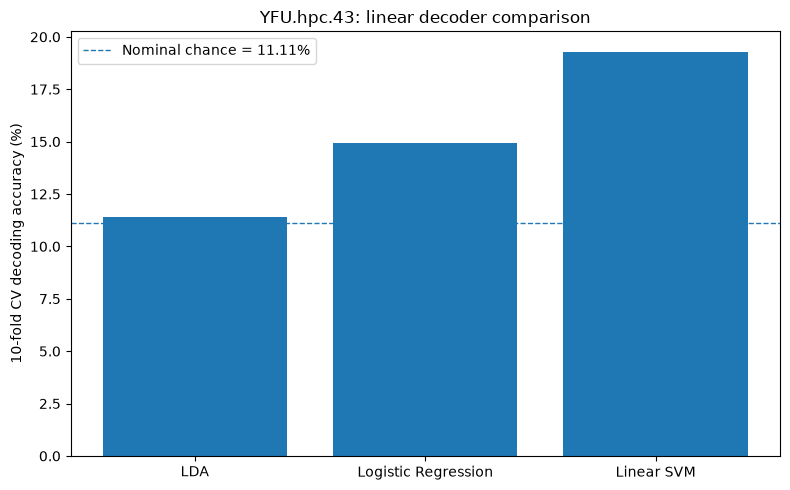

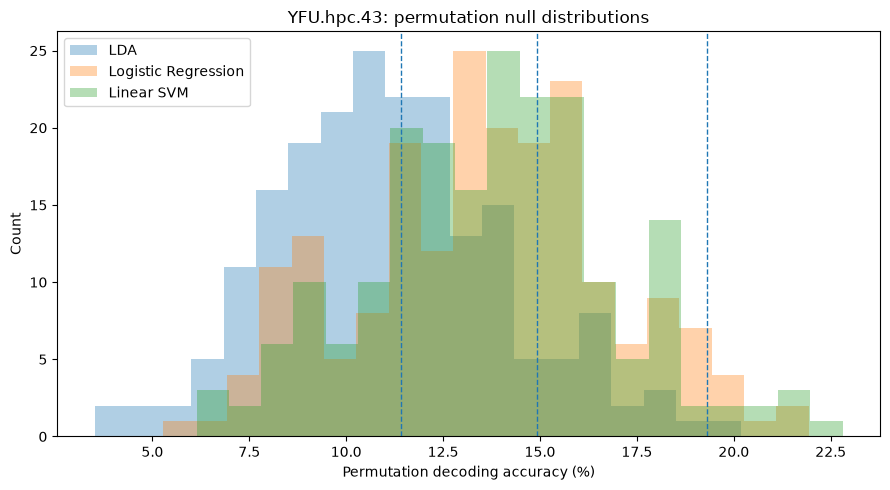

In [34]:
# ============================================================
# YFU.hpc.43
# Compare 3 linear decoders:
#
#   1. LDA
#   2. Multinomial Logistic Regression
#   3. Linear SVM
#
# Same neuron
# Same trials
# Same labels
# Same 150-ms temporal representation
# Same CV folds
# Same permutations
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from src.firing_rate_tuning import analyze_neuron
from src.number_decoding_analysis import make_temporal_features


# ============================================================
# SETTINGS
# ============================================================

SUBJECT = "YFJ"

# MATLAB neuron 43 = Python row/index 42
NEURON = 12

BIN_SIZE = 150

N_SPLITS = 10
N_PERMUTATIONS = 200

CV_RANDOM_STATE = 42
PERMUTATION_SEED = 12345


# ============================================================
# 1. LOAD YFU.hpc.43
# ============================================================

result = analyze_neuron(
    SUBJECT,
    NEURON,
    root=ROOT,
    plot=False,
    verbose=False,
)

presentations = result["presentations"]
spike_times = result["spike_times"]


# ============================================================
# 2. TEMPORAL FEATURES
# ============================================================

X, y, bin_edges = make_temporal_features(
    presentations,
    spike_times,
    bin_size=BIN_SIZE,
)

print("=" * 65)
print("YFU.hpc.43")
print("=" * 65)

print("X shape:", X.shape)
print("Number of observations:", len(y))
print("Number of temporal features:", X.shape[1])
print("Bin edges:", bin_edges)

classes, counts = np.unique(y, return_counts=True)

print("\nClass counts:")

for c, n in zip(classes, counts):
    print(f"Number {c}: {n}")

print("\nMinimum class count:", counts.min())


# ============================================================
# 3. DEFINE THREE CLASSIFIERS
# ============================================================
#
# LDA:
# same style used in the paper.
# We freeze gamma = 0.2 because this was the previously
# selected value for YFU.hpc.43.
#
# Logistic regression and SVM:
# standardized within each training fold using Pipeline.
#
# IMPORTANT:
# scaler is fitted ONLY on training data inside each CV fold.
# ============================================================

classifiers = {

    "LDA": LinearDiscriminantAnalysis(
        solver="lsqr",
        shrinkage=0.2,
        priors=np.ones(9) / 9,
    ),

    "Logistic Regression": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                penalty="l2",
                C=1.0,
                solver="lbfgs",
                max_iter=5000,
                random_state=CV_RANDOM_STATE,
            )
        )
    ]),

    "Linear SVM": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            SVC(
                kernel="linear",
                C=1.0,
            )
        )
    ]),
}


# ============================================================
# 4. CREATE THE SAME 10 CV FOLDS FOR ALL CLASSIFIERS
# ============================================================

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=CV_RANDOM_STATE,
)

cv_splits = list(
    cv.split(X, y)
)


# ============================================================
# 5. CV FUNCTION
# ============================================================

def cv_accuracy(model, X, y, splits):

    predictions = np.empty_like(y)

    for train_idx, test_idx in splits:

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]

        model.fit(
            X_train,
            y_train,
        )

        predictions[test_idx] = model.predict(
            X_test
        )

    accuracy = np.mean(
        predictions == y
    )

    return accuracy, predictions


# ============================================================
# 6. OBSERVED ACCURACY
# ============================================================

observed = {}
observed_predictions = {}

print()
print("=" * 65)
print("OBSERVED 10-FOLD CV ACCURACY")
print("=" * 65)

for name, model in classifiers.items():

    acc, pred = cv_accuracy(
        model,
        X,
        y,
        cv_splits,
    )

    observed[name] = acc
    observed_predictions[name] = pred

    print(
        f"{name:<25} "
        f"{100 * acc:.2f}%"
    )


# ============================================================
# 7. CREATE SAME 200 PERMUTED LABEL SETS
#
# Every decoder receives exactly the same shuffled labels.
# ============================================================

rng = np.random.default_rng(
    PERMUTATION_SEED
)

permuted_labels = [
    rng.permutation(y)
    for _ in range(N_PERMUTATIONS)
]


# ============================================================
# 8. PERMUTATION TEST
# ============================================================

null_distributions = {}

print()
print("=" * 65)
print("PERMUTATION TEST")
print("=" * 65)

for name, model in classifiers.items():

    null_acc = np.empty(
        N_PERMUTATIONS
    )

    for p, y_perm in enumerate(
        permuted_labels
    ):

        # ----------------------------------------------------
        # Recreate stratified CV folds using shuffled labels
        #
        # This follows the same logic as our existing
        # permutation analysis.
        # ----------------------------------------------------

        perm_cv = StratifiedKFold(
            n_splits=N_SPLITS,
            shuffle=True,
            random_state=CV_RANDOM_STATE,
        )

        perm_splits = list(
            perm_cv.split(
                X,
                y_perm,
            )
        )

        perm_acc, _ = cv_accuracy(
            model,
            X,
            y_perm,
            perm_splits,
        )

        null_acc[p] = perm_acc

    null_distributions[name] = null_acc

    obs = observed[name]

    p_value = (
        1
        +
        np.sum(
            null_acc >= obs
        )
    ) / (
        1
        +
        N_PERMUTATIONS
    )

    coding = p_value < 0.05

    print()
    print(name)

    print(
        f"Observed accuracy : "
        f"{100 * obs:.2f}%"
    )

    print(
        f"Null mean         : "
        f"{100 * null_acc.mean():.2f}%"
    )

    print(
        f"Null SD           : "
        f"{100 * null_acc.std(ddof=1):.2f}%"
    )

    print(
        f"Permutation p     : "
        f"{p_value:.5f}"
    )

    print(
        f"Number coding     : "
        f"{coding}"
    )


# ============================================================
# 9. FINAL SUMMARY TABLE
# ============================================================

summary_rows = []

for name in classifiers:

    null_acc = null_distributions[name]

    obs = observed[name]

    p_value = (
        1
        +
        np.sum(
            null_acc >= obs
        )
    ) / (
        1
        +
        N_PERMUTATIONS
    )

    summary_rows.append({

        "decoder":
            name,

        "accuracy_pct":
            100 * obs,

        "null_mean_pct":
            100 * null_acc.mean(),

        "null_sd_pct":
            100 * null_acc.std(ddof=1),

        "p_value":
            p_value,

        "number_coding":
            p_value < 0.05,
    })


summary = pd.DataFrame(
    summary_rows
)

print()
print("=" * 65)
print("FINAL COMPARISON")
print("=" * 65)

display(
    summary.round(3)
)


# ============================================================
# 10. ACCURACY BAR PLOT
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    summary["decoder"],
    summary["accuracy_pct"],
)

plt.axhline(
    100 / 9,
    linestyle="--",
    linewidth=1,
    label="Nominal chance = 11.11%",
)

plt.ylabel(
    "10-fold CV decoding accuracy (%)"
)

plt.title(
    "YFU.hpc.43: linear decoder comparison"
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 11. NULL DISTRIBUTIONS
# ============================================================

plt.figure(
    figsize=(9, 5)
)

for name in classifiers:

    plt.hist(
        100 * null_distributions[name],
        bins=20,
        alpha=0.35,
        label=name,
    )

    plt.axvline(
        100 * observed[name],
        linestyle="--",
        linewidth=1,
    )

plt.xlabel(
    "Permutation decoding accuracy (%)"
)

plt.ylabel(
    "Count"
)

plt.title(
    "YFU.hpc.43: permutation null distributions"
)

plt.legend()

plt.tight_layout()
plt.show()

SUBJECT-LEVEL DECODER COMPARISON
Subject: YFI
Number of neurons: 29
Permutations per decoder: 200

YFI neuron 1 (1/29)
Presentations : 104
Best bin      : 90 ms
LDA gamma     : 0.2
Min class N   : 9
CV folds      : 9
LDA                    | accuracy =  14.42% | null =  10.73% | p = 0.1940 | coding = False
Logistic Regression    | accuracy =  14.42% | null =  10.63% | p = 0.2139 | coding = False
Linear SVM             | accuracy =   8.65% | null =  10.59% | p = 0.7711 | coding = False

YFI neuron 2 (2/29)
Presentations : 104
Best bin      : 60 ms
LDA gamma     : 0.2
Min class N   : 9
CV folds      : 9
LDA                    | accuracy =  19.23% | null =  11.15% | p = 0.0149 | coding = True
Logistic Regression    | accuracy =  16.35% | null =  10.83% | p = 0.0697 | coding = False
Linear SVM             | accuracy =  20.19% | null =  10.75% | p = 0.0100 | coding = True

YFI neuron 3 (3/29)
Presentations : 104
Best bin      : 90 ms
LDA gamma     : 0.2
Min class N   : 9
CV folds      : 9
L

,decoder,n_neurons,mean_accuracy_pct,sem_accuracy_pct,mean_null_pct,coding_neurons,coding_proportion,coding_proportion_pct
0,LDA,29,16.313,0.466,10.884,10,0.345,34.483
1,Linear SVM,29,12.666,0.534,10.783,1,0.034,3.448
2,Logistic Regression,29,14.589,0.538,10.832,4,0.138,13.793



ACCURACY BY NEURON


decoder,LDA,Linear SVM,Logistic Regression
neuron,,,
1,14.42,8.65,14.42
2,19.23,20.19,16.35
3,16.35,12.50,15.38
4,18.27,15.38,18.27
5,16.35,12.50,13.46
6,15.38,12.50,14.42
7,10.58,5.77,8.65
8,20.19,14.42,14.42
9,15.38,14.42,14.42


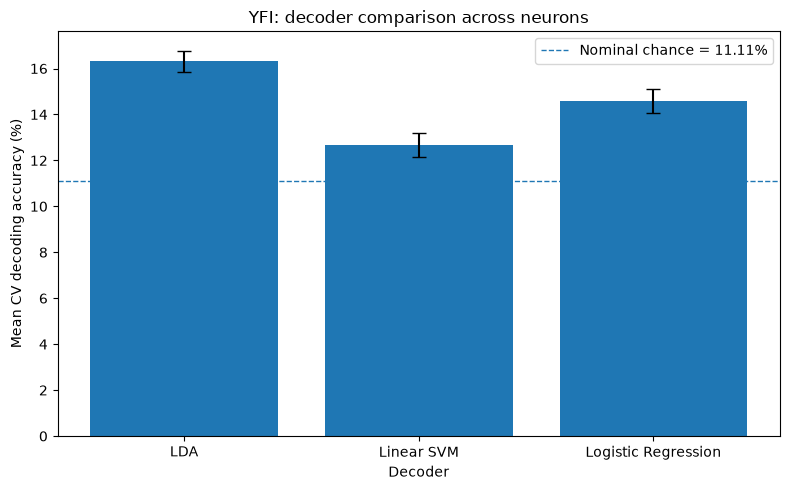

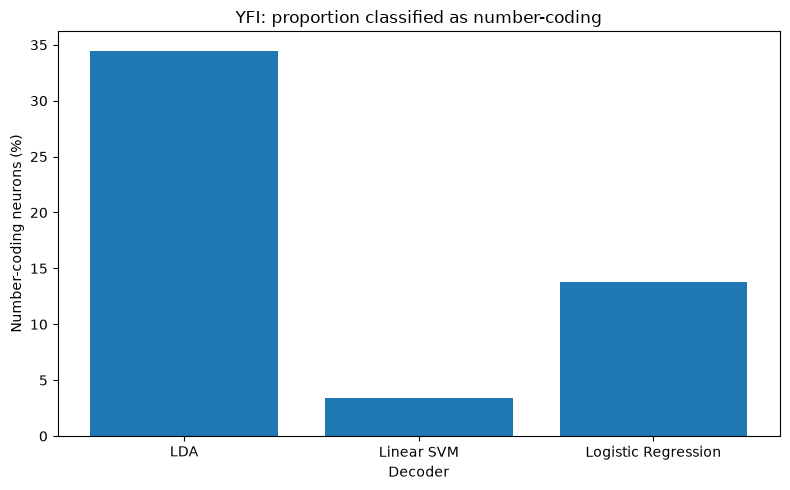

In [35]:
# ============================================================
# SUBJECT-LEVEL DECODER COMPARISON
#
# LDA vs Logistic Regression vs Linear SVM
#
# Example subject: YFI
#
# IMPORTANT:
# n_splits is automatically reduced when a number class
# contains fewer than 10 observations.
#
# For each neuron:
#   1. Load neuron
#   2. Use its previously selected temporal bin
#   3. Build temporal spike-count features
#   4. Determine valid CV folds automatically
#   5. Run LDA / Logistic Regression / Linear SVM
#   6. Run 200 permutations for each decoder
#   7. Determine number-coding status using p < 0.05
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from src.firing_rate_tuning import analyze_neuron
from src.number_decoding_analysis import make_temporal_features


# ============================================================
# 1. SETTINGS
# ============================================================

SUBJECT = "YFI"

MAX_SPLITS = 10
N_PERMUTATIONS = 200

CV_RANDOM_STATE = 42
PERMUTATION_SEED = 12345


# ============================================================
# 2. LOAD PREVIOUS SINGLE-NEURON RESULTS
# ============================================================
#
# This gives us:
#
#   neuron
#   TC_best_bin_ms
#   TC_best_gamma
#
# These parameters were already selected in our previous
# temporal LDA analysis.
# ============================================================

single = pd.read_csv(
    TABLES_DIR / "single_YFI_9fold.csv"
)

single = single[
    single["subject"] == SUBJECT
].copy()

single = single.sort_values(
    "neuron"
).reset_index(drop=True)


print("=" * 70)
print("SUBJECT-LEVEL DECODER COMPARISON")
print("=" * 70)

print("Subject:", SUBJECT)
print("Number of neurons:", len(single))
print("Permutations per decoder:", N_PERMUTATIONS)


# ============================================================
# 3. CV ACCURACY FUNCTION
# ============================================================

def cv_accuracy(
    model,
    X,
    y,
    splits,
):

    predictions = np.empty_like(y)

    for train_idx, test_idx in splits:

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]

        fold_model = clone(model)

        fold_model.fit(
            X_train,
            y_train,
        )

        predictions[test_idx] = (
            fold_model.predict(
                X_test
            )
        )

    accuracy = np.mean(
        predictions == y
    )

    return accuracy


# ============================================================
# 4. STORAGE
# ============================================================

all_results = []


# ============================================================
# 5. LOOP THROUGH ALL NEURONS
# ============================================================

for neuron_index, row in single.iterrows():

    NEURON = int(
        row["neuron"]
    )

    BIN_SIZE = int(
        row["TC_best_bin_ms"]
    )

    LDA_GAMMA = float(
        row["TC_best_gamma"]
    )

    print()
    print("=" * 70)

    print(
        f"{SUBJECT} neuron {NEURON} "
        f"({neuron_index + 1}/{len(single)})"
    )

    print("=" * 70)


    # ========================================================
    # LOAD NEURON
    # ========================================================

    result = analyze_neuron(
        SUBJECT,
        NEURON,
        root=ROOT,
        plot=False,
        verbose=False,
    )

    presentations = result[
        "presentations"
    ]

    spike_times = result[
        "spike_times"
    ]


    # ========================================================
    # TEMPORAL FEATURES
    # ========================================================

    X, y, bin_edges = make_temporal_features(
        presentations,
        spike_times,
        bin_size=BIN_SIZE,
    )


    # ========================================================
    # AUTOMATICALLY DETERMINE NUMBER OF CV FOLDS
    # ========================================================

    classes, class_counts = np.unique(
        y,
        return_counts=True,
    )

    min_class_count = int(
        class_counts.min()
    )

    n_splits = min(
        MAX_SPLITS,
        min_class_count,
    )


    # We need at least 2 folds
    if n_splits < 2:

        print(
            "Skipped: insufficient observations "
            "for stratified CV."
        )

        continue


    print(
        f"Presentations : {len(y)}"
    )

    print(
        f"Best bin      : {BIN_SIZE} ms"
    )

    print(
        f"LDA gamma     : {LDA_GAMMA}"
    )

    print(
        f"Min class N   : {min_class_count}"
    )

    print(
        f"CV folds      : {n_splits}"
    )


    # ========================================================
    # DEFINE CLASSIFIERS
    # ========================================================

    classifiers = {

        "LDA":
            LinearDiscriminantAnalysis(
                solver="lsqr",
                shrinkage=LDA_GAMMA,
                priors=np.ones(9) / 9,
            ),

        "Logistic Regression":
            Pipeline([
                (
                    "scaler",
                    StandardScaler()
                ),
                (
                    "classifier",
                    LogisticRegression(
                        C=1.0,
                        l1_ratio=0,
                        solver="lbfgs",
                        max_iter=5000,
                        class_weight="balanced",
                        random_state=CV_RANDOM_STATE,
                    )
                ),
            ]),

        "Linear SVM":
            Pipeline([
                (
                    "scaler",
                    StandardScaler()
                ),
                (
                    "classifier",
                    SVC(
                        kernel="linear",
                        C=1.0,
                        class_weight="balanced",
                    )
                ),
            ]),
    }


    # ========================================================
    # OBSERVED CV SPLITS
    # ========================================================

    observed_cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=CV_RANDOM_STATE,
    )

    observed_splits = list(
        observed_cv.split(
            X,
            y,
        )
    )


    # ========================================================
    # OBSERVED ACCURACIES
    # ========================================================

    observed_accuracies = {}

    for decoder_name, model in classifiers.items():

        observed_accuracies[
            decoder_name
        ] = cv_accuracy(
            model,
            X,
            y,
            observed_splits,
        )


    # ========================================================
    # GENERATE PERMUTED LABELS
    # ========================================================
    #
    # Seed also depends on neuron number.
    #
    # This gives reproducible but different permutations
    # for different neurons.
    # ========================================================

    rng = np.random.default_rng(
        PERMUTATION_SEED + NEURON
    )

    permuted_labels = [
        rng.permutation(y)
        for _ in range(N_PERMUTATIONS)
    ]


    # ========================================================
    # PERMUTATION TEST FOR EACH DECODER
    # ========================================================

    for decoder_name, model in classifiers.items():

        null_accuracies = np.empty(
            N_PERMUTATIONS
        )

        for permutation_index, y_perm in enumerate(
            permuted_labels
        ):

            # -----------------------------------------------
            # IMPORTANT:
            # stratification must use the PERMUTED labels
            # -----------------------------------------------

            permutation_cv = StratifiedKFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=CV_RANDOM_STATE,
            )

            permutation_splits = list(
                permutation_cv.split(
                    X,
                    y_perm,
                )
            )

            null_accuracy = cv_accuracy(
                model,
                X,
                y_perm,
                permutation_splits,
            )

            null_accuracies[
                permutation_index
            ] = null_accuracy


        observed_accuracy = (
            observed_accuracies[
                decoder_name
            ]
        )


        # ====================================================
        # PERMUTATION P-VALUE
        # ====================================================

        p_value = (
            1
            +
            np.sum(
                null_accuracies
                >= observed_accuracy
            )
        ) / (
            1
            +
            N_PERMUTATIONS
        )


        number_coding = (
            p_value < 0.05
        )


        # ====================================================
        # STORE RESULT
        # ====================================================

        all_results.append({

            "subject":
                SUBJECT,

            "neuron":
                NEURON,

            "decoder":
                decoder_name,

            "n_presentations":
                len(y),

            "min_class_count":
                min_class_count,

            "n_splits":
                n_splits,

            "bin_ms":
                BIN_SIZE,

            "lda_gamma":
                LDA_GAMMA,

            "accuracy":
                observed_accuracy,

            "accuracy_pct":
                100 * observed_accuracy,

            "null_mean":
                null_accuracies.mean(),

            "null_mean_pct":
                100 * null_accuracies.mean(),

            "null_sd":
                null_accuracies.std(
                    ddof=1
                ),

            "null_sd_pct":
                100 * null_accuracies.std(
                    ddof=1
                ),

            "p_value":
                p_value,

            "number_coding":
                number_coding,
        })


        print(
            f"{decoder_name:<22} | "
            f"accuracy = "
            f"{100 * observed_accuracy:6.2f}% | "
            f"null = "
            f"{100 * null_accuracies.mean():6.2f}% | "
            f"p = {p_value:.4f} | "
            f"coding = {number_coding}"
        )


# ============================================================
# 6. CREATE DATAFRAME
# ============================================================

decoder_results = pd.DataFrame(
    all_results
)


# ============================================================
# 7. SAVE FULL NEURON-LEVEL RESULTS
# ============================================================

output_file = (
    TABLES_DIR /
    f"{SUBJECT}_three_decoder_comparison.csv"
)

decoder_results.to_csv(
    output_file,
    index=False,
)

print()
print("=" * 70)
print("SAVED")
print("=" * 70)

print(output_file)


# ============================================================
# 8. SUBJECT-LEVEL SUMMARY
# ============================================================

subject_summary = (
    decoder_results
    .groupby("decoder")
    .agg(

        n_neurons=(
            "neuron",
            "count"
        ),

        mean_accuracy_pct=(
            "accuracy_pct",
            "mean"
        ),

        sem_accuracy_pct=(
            "accuracy_pct",
            "sem"
        ),

        mean_null_pct=(
            "null_mean_pct",
            "mean"
        ),

        coding_neurons=(
            "number_coding",
            "sum"
        ),

        coding_proportion=(
            "number_coding",
            "mean"
        ),
    )
    .reset_index()
)


subject_summary[
    "coding_proportion_pct"
] = (
    100
    * subject_summary[
        "coding_proportion"
    ]
)


print()
print("=" * 70)
print("SUBJECT-LEVEL SUMMARY")
print("=" * 70)

display(
    subject_summary.round(3)
)


# ============================================================
# 9. PIVOT TABLE
# ============================================================
#
# Makes it easy to compare the same neuron across classifiers.
# ============================================================

accuracy_pivot = (
    decoder_results
    .pivot(
        index="neuron",
        columns="decoder",
        values="accuracy_pct",
    )
)


print()
print("=" * 70)
print("ACCURACY BY NEURON")
print("=" * 70)

display(
    accuracy_pivot.round(2)
)


# ============================================================
# 10. MEAN DECODING ACCURACY PLOT
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    subject_summary["decoder"],
    subject_summary["mean_accuracy_pct"],
    yerr=subject_summary["sem_accuracy_pct"],
    capsize=5,
)

plt.axhline(
    100 / 9,
    linestyle="--",
    linewidth=1,
    label="Nominal chance = 11.11%",
)

plt.ylabel(
    "Mean CV decoding accuracy (%)"
)

plt.xlabel(
    "Decoder"
)

plt.title(
    f"{SUBJECT}: decoder comparison across neurons"
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 11. NUMBER-CODING PROPORTION PLOT
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    subject_summary["decoder"],
    subject_summary[
        "coding_proportion_pct"
    ],
)

plt.ylabel(
    "Number-coding neurons (%)"
)

plt.xlabel(
    "Decoder"
)

plt.title(
    f"{SUBJECT}: proportion classified as number-coding"
)

plt.tight_layout()
plt.show()

YFU neuron 43
Number of observations: 494
Minimum class count: 47
CV folds: 10

Class counts:
Number 1: 53
Number 2: 67
Number 3: 52
Number 4: 62
Number 5: 51
Number 6: 48
Number 7: 65
Number 8: 49
Number 9: 47

INDEPENDENT MODEL SELECTION

LDA
Best bin   : 150 ms
Best gamma : 0.2
Accuracy   : 16.397%

Logistic Regression
Best bin   : 150 ms
Best C     : 0.01
Accuracy   : 15.992%

Linear SVM
Best bin   : 150 ms
Best C     : 10.0
Accuracy   : 16.194%

LDA
Best bin       : 150 ms
Hyperparameter : gamma = 0.2
Observed       : 16.397%
Null mean      : 11.194%
Null SD        : 1.773%
p-value        : 0.00995
Number coding  : True

Logistic Regression
Best bin       : 150 ms
Hyperparameter : C = 0.01
Observed       : 15.992%
Null mean      : 11.140%
Null SD        : 1.692%
p-value        : 0.00995
Number coding  : True

Linear SVM
Best bin       : 150 ms
Hyperparameter : C = 10.0
Observed       : 16.194%
Null mean      : 11.113%
Null SD        : 1.649%
p-value        : 0.00498
Number coding 

,decoder,best_bin_ms,hyperparameter,hyperparameter_value,accuracy_pct,null_mean_pct,null_sd_pct,p_value,number_coding
0,LDA,150,gamma,0.20,16.3968,11.1943,1.7728,0.010,True
1,Logistic Regression,150,C,0.01,15.9919,11.1397,1.6923,0.010,True
2,Linear SVM,150,C,10.00,16.1943,11.1134,1.6489,0.005,True


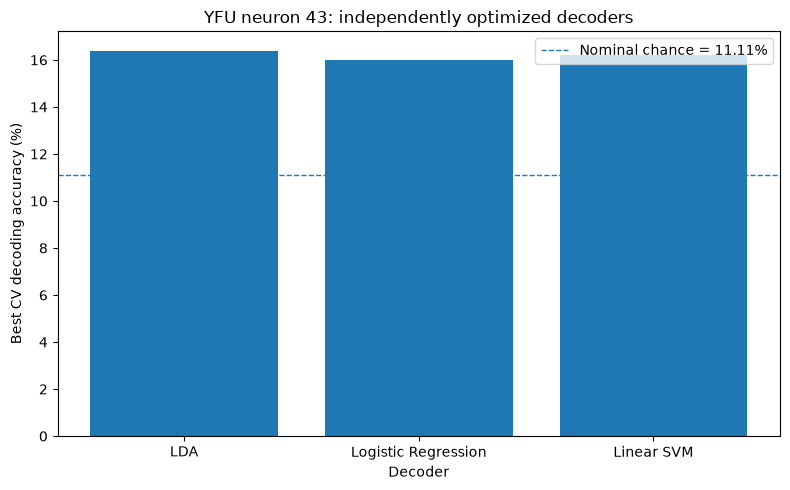

In [36]:
# ============================================================
# COMPLETELY INDEPENDENT DECODER COMPARISON
# Single neuron: YFU.hpc.43
#
# Each decoder independently chooses:
#
# LDA:
#   best temporal bin
#   best gamma
#
# Logistic Regression:
#   best temporal bin
#   best C
#
# Linear SVM:
#   best temporal bin
#   best C
#
# Then each decoder gets its OWN permutation test using
# ONLY its own selected representation/hyperparameter.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

from src.firing_rate_tuning import analyze_neuron
from src.number_decoding_analysis import make_temporal_features


# ============================================================
# 1. SETTINGS
# ============================================================

SUBJECT = "YFU"
NEURON = 43

BIN_SIZES = [
    60, 75, 90, 100, 150,
    180, 225, 300, 450, 900
]

LDA_GAMMAS = [
    0.2, 0.5, 0.8
]

# Same regularization search space for Logistic and SVM
C_VALUES = [
    0.01, 0.1, 1.0, 10.0, 100.0
]

MAX_SPLITS = 10

N_PERMUTATIONS = 200

CV_RANDOM_STATE = 42
PERMUTATION_SEED = 12345


# ============================================================
# 2. LOAD NEURON
# ============================================================

result = analyze_neuron(
    SUBJECT,
    NEURON,
    root=ROOT,
    plot=False,
    verbose=False,
)

presentations = result["presentations"]
spike_times = result["spike_times"]


# ============================================================
# 3. BUILD FEATURES FOR EVERY BIN SIZE
# ============================================================

features_by_bin = {}

reference_y = None


for bin_size in BIN_SIZES:

    X, y, edges = make_temporal_features(
        presentations,
        spike_times,
        bin_size=bin_size,
    )

    features_by_bin[bin_size] = {
        "X": X,
        "y": y,
        "edges": edges,
    }

    if reference_y is None:
        reference_y = y.copy()

    else:
        assert np.array_equal(
            reference_y,
            y
        )


y = reference_y


# ============================================================
# 4. AUTOMATIC NUMBER OF FOLDS
# ============================================================

classes, class_counts = np.unique(
    y,
    return_counts=True,
)

min_class_count = int(
    class_counts.min()
)

n_splits = min(
    MAX_SPLITS,
    min_class_count,
)

if n_splits < 2:
    raise ValueError(
        "Not enough observations for stratified CV."
    )


print("=" * 70)
print(f"{SUBJECT} neuron {NEURON}")
print("=" * 70)

print(
    "Number of observations:",
    len(y)
)

print(
    "Minimum class count:",
    min_class_count
)

print(
    "CV folds:",
    n_splits
)

print("\nClass counts:")

for number, count in zip(
    classes,
    class_counts
):
    print(
        f"Number {number}: {count}"
    )


# ============================================================
# 5. CREATE ONE COMMON SET OF OBSERVED FOLDS
# ============================================================
#
# The classifiers are independent in:
#   representation selection
#   hyperparameter selection
#   fitted model
#
# But they use the SAME train/test partitions.
#
# This is important for a fair comparison.
# ============================================================

observed_cv = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=CV_RANDOM_STATE,
)

observed_splits = list(
    observed_cv.split(
        np.zeros(len(y)),
        y,
    )
)


# ============================================================
# 6. CV FUNCTION
# ============================================================

def cv_accuracy(
    model,
    X,
    y,
    splits,
):

    predictions = np.empty_like(y)

    for train_idx, test_idx in splits:

        fold_model = clone(
            model
        )

        fold_model.fit(
            X[train_idx],
            y[train_idx],
        )

        predictions[test_idx] = (
            fold_model.predict(
                X[test_idx]
            )
        )

    return np.mean(
        predictions == y
    )


# ============================================================
# 7. MODEL BUILDERS
# ============================================================

def make_lda(gamma):

    return LinearDiscriminantAnalysis(
        solver="lsqr",
        shrinkage=gamma,
        priors=np.ones(9) / 9,
    )


def make_logistic(C):

    return Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                C=C,
                l1_ratio=0,
                solver="lbfgs",
                max_iter=5000,
                class_weight="balanced",
                random_state=CV_RANDOM_STATE,
            )
        ),
    ])


def make_svm(C):

    return Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            SVC(
                kernel="linear",
                C=C,
                class_weight="balanced",
            )
        ),
    ])


# ============================================================
# 8. COMPLETELY INDEPENDENT LDA SEARCH
# ============================================================

lda_search = []


for bin_size in BIN_SIZES:

    X = features_by_bin[
        bin_size
    ]["X"]

    for gamma in LDA_GAMMAS:

        model = make_lda(
            gamma
        )

        accuracy = cv_accuracy(
            model,
            X,
            y,
            observed_splits,
        )

        lda_search.append({
            "bin_ms": bin_size,
            "parameter": gamma,
            "accuracy": accuracy,
        })


lda_search = pd.DataFrame(
    lda_search
)

lda_best = (
    lda_search
    .sort_values(
        "accuracy",
        ascending=False,
    )
    .iloc[0]
)

LDA_BEST_BIN = int(
    lda_best["bin_ms"]
)

LDA_BEST_GAMMA = float(
    lda_best["parameter"]
)

LDA_OBSERVED = float(
    lda_best["accuracy"]
)


# ============================================================
# 9. COMPLETELY INDEPENDENT LOGISTIC SEARCH
# ============================================================

logistic_search = []


for bin_size in BIN_SIZES:

    X = features_by_bin[
        bin_size
    ]["X"]

    for C in C_VALUES:

        model = make_logistic(
            C
        )

        accuracy = cv_accuracy(
            model,
            X,
            y,
            observed_splits,
        )

        logistic_search.append({
            "bin_ms": bin_size,
            "parameter": C,
            "accuracy": accuracy,
        })


logistic_search = pd.DataFrame(
    logistic_search
)

logistic_best = (
    logistic_search
    .sort_values(
        "accuracy",
        ascending=False,
    )
    .iloc[0]
)

LOGISTIC_BEST_BIN = int(
    logistic_best["bin_ms"]
)

LOGISTIC_BEST_C = float(
    logistic_best["parameter"]
)

LOGISTIC_OBSERVED = float(
    logistic_best["accuracy"]
)


# ============================================================
# 10. COMPLETELY INDEPENDENT SVM SEARCH
# ============================================================

svm_search = []


for bin_size in BIN_SIZES:

    X = features_by_bin[
        bin_size
    ]["X"]

    for C in C_VALUES:

        model = make_svm(
            C
        )

        accuracy = cv_accuracy(
            model,
            X,
            y,
            observed_splits,
        )

        svm_search.append({
            "bin_ms": bin_size,
            "parameter": C,
            "accuracy": accuracy,
        })


svm_search = pd.DataFrame(
    svm_search
)

svm_best = (
    svm_search
    .sort_values(
        "accuracy",
        ascending=False,
    )
    .iloc[0]
)

SVM_BEST_BIN = int(
    svm_best["bin_ms"]
)

SVM_BEST_C = float(
    svm_best["parameter"]
)

SVM_OBSERVED = float(
    svm_best["accuracy"]
)


# ============================================================
# 11. SHOW INDEPENDENT SEARCH RESULTS
# ============================================================

print()
print("=" * 70)
print("INDEPENDENT MODEL SELECTION")
print("=" * 70)


print("\nLDA")

print(
    "Best bin   :",
    LDA_BEST_BIN,
    "ms"
)

print(
    "Best gamma :",
    LDA_BEST_GAMMA
)

print(
    "Accuracy   :",
    f"{100 * LDA_OBSERVED:.3f}%"
)


print("\nLogistic Regression")

print(
    "Best bin   :",
    LOGISTIC_BEST_BIN,
    "ms"
)

print(
    "Best C     :",
    LOGISTIC_BEST_C
)

print(
    "Accuracy   :",
    f"{100 * LOGISTIC_OBSERVED:.3f}%"
)


print("\nLinear SVM")

print(
    "Best bin   :",
    SVM_BEST_BIN,
    "ms"
)

print(
    "Best C     :",
    SVM_BEST_C
)

print(
    "Accuracy   :",
    f"{100 * SVM_OBSERVED:.3f}%"
)


# ============================================================
# 12. PREPARE EACH DECODER'S OWN FINAL REPRESENTATION
# ============================================================

decoder_settings = {

    "LDA": {

        "X":
            features_by_bin[
                LDA_BEST_BIN
            ]["X"],

        "model":
            make_lda(
                LDA_BEST_GAMMA
            ),

        "best_bin_ms":
            LDA_BEST_BIN,

        "hyperparameter_name":
            "gamma",

        "hyperparameter_value":
            LDA_BEST_GAMMA,

        "observed_accuracy":
            LDA_OBSERVED,
    },


    "Logistic Regression": {

        "X":
            features_by_bin[
                LOGISTIC_BEST_BIN
            ]["X"],

        "model":
            make_logistic(
                LOGISTIC_BEST_C
            ),

        "best_bin_ms":
            LOGISTIC_BEST_BIN,

        "hyperparameter_name":
            "C",

        "hyperparameter_value":
            LOGISTIC_BEST_C,

        "observed_accuracy":
            LOGISTIC_OBSERVED,
    },


    "Linear SVM": {

        "X":
            features_by_bin[
                SVM_BEST_BIN
            ]["X"],

        "model":
            make_svm(
                SVM_BEST_C
            ),

        "best_bin_ms":
            SVM_BEST_BIN,

        "hyperparameter_name":
            "C",

        "hyperparameter_value":
            SVM_BEST_C,

        "observed_accuracy":
            SVM_OBSERVED,
    },
}


# ============================================================
# 13. CREATE COMMON PERMUTED LABELS
# ============================================================
#
# Same shuffled label sequence is used across classifiers.
#
# This does NOT couple the classifiers.
# It simply gives them the same null datasets.
# ============================================================

rng = np.random.default_rng(
    PERMUTATION_SEED
)

permuted_labels = [
    rng.permutation(y)
    for _ in range(
        N_PERMUTATIONS
    )
]


# ============================================================
# 14. INDEPENDENT PERMUTATION TESTS
# ============================================================
#
# IMPORTANT:
#
# We freeze EACH decoder's OWN:
#
#   best bin
#   best regularization parameter
#
# during its permutation test.
#
# We do NOT pass LDA's settings to the other classifiers.
# ============================================================

final_results = []


for decoder_name, settings in decoder_settings.items():

    print()
    print("=" * 70)
    print(decoder_name)
    print("=" * 70)

    X_decoder = settings["X"]

    model = settings["model"]

    observed_accuracy = (
        settings[
            "observed_accuracy"
        ]
    )

    null_accuracies = np.empty(
        N_PERMUTATIONS
    )


    for permutation_index, y_perm in enumerate(
        permuted_labels
    ):

        permutation_cv = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=CV_RANDOM_STATE,
        )

        permutation_splits = list(
            permutation_cv.split(
                np.zeros(len(y_perm)),
                y_perm,
            )
        )

        null_accuracies[
            permutation_index
        ] = cv_accuracy(
            model,
            X_decoder,
            y_perm,
            permutation_splits,
        )


    p_value = (
        1
        +
        np.sum(
            null_accuracies
            >= observed_accuracy
        )
    ) / (
        1
        +
        N_PERMUTATIONS
    )


    number_coding = (
        p_value < 0.05
    )


    final_results.append({

        "decoder":
            decoder_name,

        "best_bin_ms":
            settings[
                "best_bin_ms"
            ],

        "hyperparameter":
            settings[
                "hyperparameter_name"
            ],

        "hyperparameter_value":
            settings[
                "hyperparameter_value"
            ],

        "accuracy_pct":
            100 * observed_accuracy,

        "null_mean_pct":
            100 * null_accuracies.mean(),

        "null_sd_pct":
            100 * null_accuracies.std(
                ddof=1
            ),

        "p_value":
            p_value,

        "number_coding":
            number_coding,
    })


    print(
        "Best bin       :",
        settings[
            "best_bin_ms"
        ],
        "ms"
    )

    print(
        "Hyperparameter :",
        settings[
            "hyperparameter_name"
        ],
        "=",
        settings[
            "hyperparameter_value"
        ]
    )

    print(
        "Observed       :",
        f"{100 * observed_accuracy:.3f}%"
    )

    print(
        "Null mean      :",
        f"{100 * null_accuracies.mean():.3f}%"
    )

    print(
        "Null SD        :",
        f"{100 * null_accuracies.std(ddof=1):.3f}%"
    )

    print(
        "p-value        :",
        f"{p_value:.5f}"
    )

    print(
        "Number coding  :",
        number_coding
    )


# ============================================================
# 15. FINAL COMPARISON
# ============================================================

final_results = pd.DataFrame(
    final_results
)


print()
print("=" * 70)
print("FINAL INDEPENDENT DECODER COMPARISON")
print("=" * 70)

display(
    final_results.round(4)
)


# ============================================================
# 16. PLOT
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    final_results["decoder"],
    final_results["accuracy_pct"],
)

plt.axhline(
    100 / 9,
    linestyle="--",
    linewidth=1,
    label="Nominal chance = 11.11%",
)

plt.ylabel(
    "Best CV decoding accuracy (%)"
)

plt.xlabel(
    "Decoder"
)

plt.title(
    f"{SUBJECT} neuron {NEURON}: "
    "independently optimized decoders"
)

plt.legend()

plt.tight_layout()
plt.show()

YFJ neuron 4
Number of observations: 114
Minimum class count: 4
CV folds: 4

Class counts:
Number 1: 19
Number 2: 17
Number 3: 14
Number 4: 4
Number 5: 14
Number 6: 16
Number 7: 10
Number 8: 12
Number 9: 8

INDEPENDENT MODEL SELECTION

LDA
Best bin   : 60 ms
Best gamma : 0.2
Accuracy   : 11.404%

Logistic Regression
Best bin   : 900 ms
Best C     : 100.0
Accuracy   : 12.281%

Linear SVM
Best bin   : 60 ms
Best C     : 0.01
Accuracy   : 13.158%

LDA
Best bin       : 60 ms
Hyperparameter : gamma = 0.2
Observed       : 11.404%
Null mean      : 11.548%
Null SD        : 3.579%
p-value        : 0.52736
Number coding  : False

Logistic Regression
Best bin       : 900 ms
Hyperparameter : C = 100.0
Observed       : 12.281%
Null mean      : 10.649%
Null SD        : 3.224%
p-value        : 0.33333
Number coding  : False

Linear SVM
Best bin       : 60 ms
Hyperparameter : C = 0.01
Observed       : 13.158%
Null mean      : 11.715%
Null SD        : 1.938%
p-value        : 0.29851
Number coding  : Fa

,decoder,best_bin_ms,hyperparameter,hyperparameter_value,accuracy_pct,null_mean_pct,null_sd_pct,p_value,number_coding
0,LDA,60,gamma,0.20,11.4035,11.5482,3.5794,0.5274,False
1,Logistic Regression,900,C,100.00,12.2807,10.6491,3.2240,0.3333,False
2,Linear SVM,60,C,0.01,13.1579,11.7149,1.9385,0.2985,False


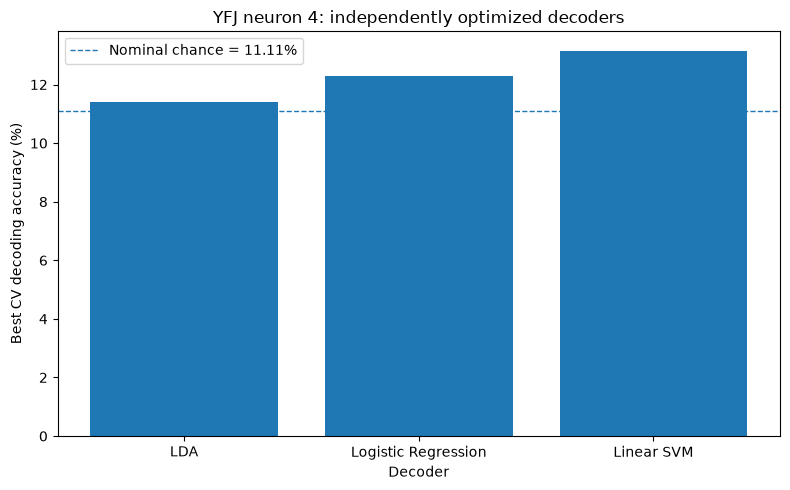

In [37]:
# ============================================================
# COMPLETELY INDEPENDENT DECODER COMPARISON
# Single neuron: YFU.hpc.43
#
# Each decoder independently chooses:
#
# LDA:
#   best temporal bin
#   best gamma
#
# Logistic Regression:
#   best temporal bin
#   best C
#
# Linear SVM:
#   best temporal bin
#   best C
#
# Then each decoder gets its OWN permutation test using
# ONLY its own selected representation/hyperparameter.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

from src.firing_rate_tuning import analyze_neuron
from src.number_decoding_analysis import make_temporal_features


# ============================================================
# 1. SETTINGS
# ============================================================

SUBJECT = "YFJ"
NEURON = 4

BIN_SIZES = [
    60, 75, 90, 100, 150,
    180, 225, 300, 450, 900
]

LDA_GAMMAS = [
    0.2, 0.5, 0.8
]

# Same regularization search space for Logistic and SVM
C_VALUES = [
    0.01, 0.1, 1.0, 10.0, 100.0
]

MAX_SPLITS = 10

N_PERMUTATIONS = 200

CV_RANDOM_STATE = 42
PERMUTATION_SEED = 12345


# ============================================================
# 2. LOAD NEURON
# ============================================================

result = analyze_neuron(
    SUBJECT,
    NEURON,
    root=ROOT,
    plot=False,
    verbose=False,
)

presentations = result["presentations"]
spike_times = result["spike_times"]


# ============================================================
# 3. BUILD FEATURES FOR EVERY BIN SIZE
# ============================================================

features_by_bin = {}

reference_y = None


for bin_size in BIN_SIZES:

    X, y, edges = make_temporal_features(
        presentations,
        spike_times,
        bin_size=bin_size,
    )

    features_by_bin[bin_size] = {
        "X": X,
        "y": y,
        "edges": edges,
    }

    if reference_y is None:
        reference_y = y.copy()

    else:
        assert np.array_equal(
            reference_y,
            y
        )


y = reference_y


# ============================================================
# 4. AUTOMATIC NUMBER OF FOLDS
# ============================================================

classes, class_counts = np.unique(
    y,
    return_counts=True,
)

min_class_count = int(
    class_counts.min()
)

n_splits = min(
    MAX_SPLITS,
    min_class_count,
)

if n_splits < 2:
    raise ValueError(
        "Not enough observations for stratified CV."
    )


print("=" * 70)
print(f"{SUBJECT} neuron {NEURON}")
print("=" * 70)

print(
    "Number of observations:",
    len(y)
)

print(
    "Minimum class count:",
    min_class_count
)

print(
    "CV folds:",
    n_splits
)

print("\nClass counts:")

for number, count in zip(
    classes,
    class_counts
):
    print(
        f"Number {number}: {count}"
    )


# ============================================================
# 5. CREATE ONE COMMON SET OF OBSERVED FOLDS
# ============================================================
#
# The classifiers are independent in:
#   representation selection
#   hyperparameter selection
#   fitted model
#
# But they use the SAME train/test partitions.
#
# This is important for a fair comparison.
# ============================================================

observed_cv = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=CV_RANDOM_STATE,
)

observed_splits = list(
    observed_cv.split(
        np.zeros(len(y)),
        y,
    )
)


# ============================================================
# 6. CV FUNCTION
# ============================================================

def cv_accuracy(
    model,
    X,
    y,
    splits,
):

    predictions = np.empty_like(y)

    for train_idx, test_idx in splits:

        fold_model = clone(
            model
        )

        fold_model.fit(
            X[train_idx],
            y[train_idx],
        )

        predictions[test_idx] = (
            fold_model.predict(
                X[test_idx]
            )
        )

    return np.mean(
        predictions == y
    )


# ============================================================
# 7. MODEL BUILDERS
# ============================================================

def make_lda(gamma):

    return LinearDiscriminantAnalysis(
        solver="lsqr",
        shrinkage=gamma,
        priors=np.ones(9) / 9,
    )


def make_logistic(C):

    return Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                C=C,
                l1_ratio=0,
                solver="lbfgs",
                max_iter=5000,
                class_weight="balanced",
                random_state=CV_RANDOM_STATE,
            )
        ),
    ])


def make_svm(C):

    return Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            SVC(
                kernel="linear",
                C=C,
                class_weight="balanced",
            )
        ),
    ])


# ============================================================
# 8. COMPLETELY INDEPENDENT LDA SEARCH
# ============================================================

lda_search = []


for bin_size in BIN_SIZES:

    X = features_by_bin[
        bin_size
    ]["X"]

    for gamma in LDA_GAMMAS:

        model = make_lda(
            gamma
        )

        accuracy = cv_accuracy(
            model,
            X,
            y,
            observed_splits,
        )

        lda_search.append({
            "bin_ms": bin_size,
            "parameter": gamma,
            "accuracy": accuracy,
        })


lda_search = pd.DataFrame(
    lda_search
)

lda_best = (
    lda_search
    .sort_values(
        "accuracy",
        ascending=False,
    )
    .iloc[0]
)

LDA_BEST_BIN = int(
    lda_best["bin_ms"]
)

LDA_BEST_GAMMA = float(
    lda_best["parameter"]
)

LDA_OBSERVED = float(
    lda_best["accuracy"]
)


# ============================================================
# 9. COMPLETELY INDEPENDENT LOGISTIC SEARCH
# ============================================================

logistic_search = []


for bin_size in BIN_SIZES:

    X = features_by_bin[
        bin_size
    ]["X"]

    for C in C_VALUES:

        model = make_logistic(
            C
        )

        accuracy = cv_accuracy(
            model,
            X,
            y,
            observed_splits,
        )

        logistic_search.append({
            "bin_ms": bin_size,
            "parameter": C,
            "accuracy": accuracy,
        })


logistic_search = pd.DataFrame(
    logistic_search
)

logistic_best = (
    logistic_search
    .sort_values(
        "accuracy",
        ascending=False,
    )
    .iloc[0]
)

LOGISTIC_BEST_BIN = int(
    logistic_best["bin_ms"]
)

LOGISTIC_BEST_C = float(
    logistic_best["parameter"]
)

LOGISTIC_OBSERVED = float(
    logistic_best["accuracy"]
)


# ============================================================
# 10. COMPLETELY INDEPENDENT SVM SEARCH
# ============================================================

svm_search = []


for bin_size in BIN_SIZES:

    X = features_by_bin[
        bin_size
    ]["X"]

    for C in C_VALUES:

        model = make_svm(
            C
        )

        accuracy = cv_accuracy(
            model,
            X,
            y,
            observed_splits,
        )

        svm_search.append({
            "bin_ms": bin_size,
            "parameter": C,
            "accuracy": accuracy,
        })


svm_search = pd.DataFrame(
    svm_search
)

svm_best = (
    svm_search
    .sort_values(
        "accuracy",
        ascending=False,
    )
    .iloc[0]
)

SVM_BEST_BIN = int(
    svm_best["bin_ms"]
)

SVM_BEST_C = float(
    svm_best["parameter"]
)

SVM_OBSERVED = float(
    svm_best["accuracy"]
)


# ============================================================
# 11. SHOW INDEPENDENT SEARCH RESULTS
# ============================================================

print()
print("=" * 70)
print("INDEPENDENT MODEL SELECTION")
print("=" * 70)


print("\nLDA")

print(
    "Best bin   :",
    LDA_BEST_BIN,
    "ms"
)

print(
    "Best gamma :",
    LDA_BEST_GAMMA
)

print(
    "Accuracy   :",
    f"{100 * LDA_OBSERVED:.3f}%"
)


print("\nLogistic Regression")

print(
    "Best bin   :",
    LOGISTIC_BEST_BIN,
    "ms"
)

print(
    "Best C     :",
    LOGISTIC_BEST_C
)

print(
    "Accuracy   :",
    f"{100 * LOGISTIC_OBSERVED:.3f}%"
)


print("\nLinear SVM")

print(
    "Best bin   :",
    SVM_BEST_BIN,
    "ms"
)

print(
    "Best C     :",
    SVM_BEST_C
)

print(
    "Accuracy   :",
    f"{100 * SVM_OBSERVED:.3f}%"
)


# ============================================================
# 12. PREPARE EACH DECODER'S OWN FINAL REPRESENTATION
# ============================================================

decoder_settings = {

    "LDA": {

        "X":
            features_by_bin[
                LDA_BEST_BIN
            ]["X"],

        "model":
            make_lda(
                LDA_BEST_GAMMA
            ),

        "best_bin_ms":
            LDA_BEST_BIN,

        "hyperparameter_name":
            "gamma",

        "hyperparameter_value":
            LDA_BEST_GAMMA,

        "observed_accuracy":
            LDA_OBSERVED,
    },


    "Logistic Regression": {

        "X":
            features_by_bin[
                LOGISTIC_BEST_BIN
            ]["X"],

        "model":
            make_logistic(
                LOGISTIC_BEST_C
            ),

        "best_bin_ms":
            LOGISTIC_BEST_BIN,

        "hyperparameter_name":
            "C",

        "hyperparameter_value":
            LOGISTIC_BEST_C,

        "observed_accuracy":
            LOGISTIC_OBSERVED,
    },


    "Linear SVM": {

        "X":
            features_by_bin[
                SVM_BEST_BIN
            ]["X"],

        "model":
            make_svm(
                SVM_BEST_C
            ),

        "best_bin_ms":
            SVM_BEST_BIN,

        "hyperparameter_name":
            "C",

        "hyperparameter_value":
            SVM_BEST_C,

        "observed_accuracy":
            SVM_OBSERVED,
    },
}


# ============================================================
# 13. CREATE COMMON PERMUTED LABELS
# ============================================================
#
# Same shuffled label sequence is used across classifiers.
#
# This does NOT couple the classifiers.
# It simply gives them the same null datasets.
# ============================================================

rng = np.random.default_rng(
    PERMUTATION_SEED
)

permuted_labels = [
    rng.permutation(y)
    for _ in range(
        N_PERMUTATIONS
    )
]


# ============================================================
# 14. INDEPENDENT PERMUTATION TESTS
# ============================================================
#
# IMPORTANT:
#
# We freeze EACH decoder's OWN:
#
#   best bin
#   best regularization parameter
#
# during its permutation test.
#
# We do NOT pass LDA's settings to the other classifiers.
# ============================================================

final_results = []


for decoder_name, settings in decoder_settings.items():

    print()
    print("=" * 70)
    print(decoder_name)
    print("=" * 70)

    X_decoder = settings["X"]

    model = settings["model"]

    observed_accuracy = (
        settings[
            "observed_accuracy"
        ]
    )

    null_accuracies = np.empty(
        N_PERMUTATIONS
    )


    for permutation_index, y_perm in enumerate(
        permuted_labels
    ):

        permutation_cv = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=CV_RANDOM_STATE,
        )

        permutation_splits = list(
            permutation_cv.split(
                np.zeros(len(y_perm)),
                y_perm,
            )
        )

        null_accuracies[
            permutation_index
        ] = cv_accuracy(
            model,
            X_decoder,
            y_perm,
            permutation_splits,
        )


    p_value = (
        1
        +
        np.sum(
            null_accuracies
            >= observed_accuracy
        )
    ) / (
        1
        +
        N_PERMUTATIONS
    )


    number_coding = (
        p_value < 0.05
    )


    final_results.append({

        "decoder":
            decoder_name,

        "best_bin_ms":
            settings[
                "best_bin_ms"
            ],

        "hyperparameter":
            settings[
                "hyperparameter_name"
            ],

        "hyperparameter_value":
            settings[
                "hyperparameter_value"
            ],

        "accuracy_pct":
            100 * observed_accuracy,

        "null_mean_pct":
            100 * null_accuracies.mean(),

        "null_sd_pct":
            100 * null_accuracies.std(
                ddof=1
            ),

        "p_value":
            p_value,

        "number_coding":
            number_coding,
    })


    print(
        "Best bin       :",
        settings[
            "best_bin_ms"
        ],
        "ms"
    )

    print(
        "Hyperparameter :",
        settings[
            "hyperparameter_name"
        ],
        "=",
        settings[
            "hyperparameter_value"
        ]
    )

    print(
        "Observed       :",
        f"{100 * observed_accuracy:.3f}%"
    )

    print(
        "Null mean      :",
        f"{100 * null_accuracies.mean():.3f}%"
    )

    print(
        "Null SD        :",
        f"{100 * null_accuracies.std(ddof=1):.3f}%"
    )

    print(
        "p-value        :",
        f"{p_value:.5f}"
    )

    print(
        "Number coding  :",
        number_coding
    )


# ============================================================
# 15. FINAL COMPARISON
# ============================================================

final_results = pd.DataFrame(
    final_results
)


print()
print("=" * 70)
print("FINAL INDEPENDENT DECODER COMPARISON")
print("=" * 70)

display(
    final_results.round(4)
)


# ============================================================
# 16. PLOT
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    final_results["decoder"],
    final_results["accuracy_pct"],
)

plt.axhline(
    100 / 9,
    linestyle="--",
    linewidth=1,
    label="Nominal chance = 11.11%",
)

plt.ylabel(
    "Best CV decoding accuracy (%)"
)

plt.xlabel(
    "Decoder"
)

plt.title(
    f"{SUBJECT} neuron {NEURON}: "
    "independently optimized decoders"
)

plt.legend()

plt.tight_layout()
plt.show()

In [38]:
1+1

2

YFU INDEPENDENT DECODER ANALYSIS
Number of YFU neurons: 29
Neurons: [1, 2, 3, 4, 5, 6, 7, 8, 9, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38]

YFU neuron 1 (1/29)
Presentations: 104
Minimum class count: 9
CV folds: 9

LDA                    | bin =  90 ms | gamma = 0.2    | accuracy = 14.423%

Logistic Regression    | bin =  90 ms | C = 1      | accuracy = 14.423%

Linear SVM             | bin = 100 ms | C = 10     | accuracy = 16.346%
    permutation -> LDA                    | null = 10.73% | p = 0.1940 | coding = False
    permutation -> Logistic Regression    | null = 10.63% | p = 0.2139 | coding = False
    permutation -> Linear SVM             | null = 10.99% | p = 0.0796 | coding = False

Neuron runtime: 0.97 min

YFU neuron 2 (2/29)
Presentations: 104
Minimum class count: 9
CV folds: 9

LDA                    | bin =  60 ms | gamma = 0.2    | accuracy = 19.231%

Logistic Regression    | bin =  60 ms | C = 100    | accuracy = 17.308%

Linear SVM

,decoder,n_neurons,mean_accuracy_pct,sem_accuracy_pct,median_accuracy_pct,mean_null_pct,coding_neurons,coding_proportion,coding_proportion_pct
0,LDA,29,16.313,0.466,16.346,10.884,10,0.345,34.483
1,Linear SVM,29,16.976,0.397,17.308,10.746,14,0.483,48.276
2,Logistic Regression,29,16.810,0.464,17.308,10.664,15,0.517,51.724



ACCURACY BY NEURON


decoder,LDA,Linear SVM,Logistic Regression
neuron,,,
1,14.42,16.35,14.42
2,19.23,20.19,17.31
3,16.35,18.27,15.38
4,18.27,17.31,18.27
5,16.35,15.38,17.31
6,15.38,16.35,14.42
7,10.58,12.50,10.58
8,20.19,18.27,19.23
9,15.38,17.31,16.35



INDEPENDENTLY SELECTED BIN SIZE BY NEURON


decoder,LDA,Linear SVM,Logistic Regression
neuron,,,
1,90,100,90
2,60,60,60
3,90,150,90
4,900,180,900
5,180,300,180
6,75,150,75
7,100,100,60
8,60,60,60
9,225,225,900



CODING STATUS BY NEURON


decoder,LDA,Linear SVM,Logistic Regression
neuron,,,
1,False,False,False
2,True,True,True
3,True,True,False
4,True,True,True
5,False,False,True
6,False,False,False
7,False,False,False
8,True,True,True
9,False,False,False


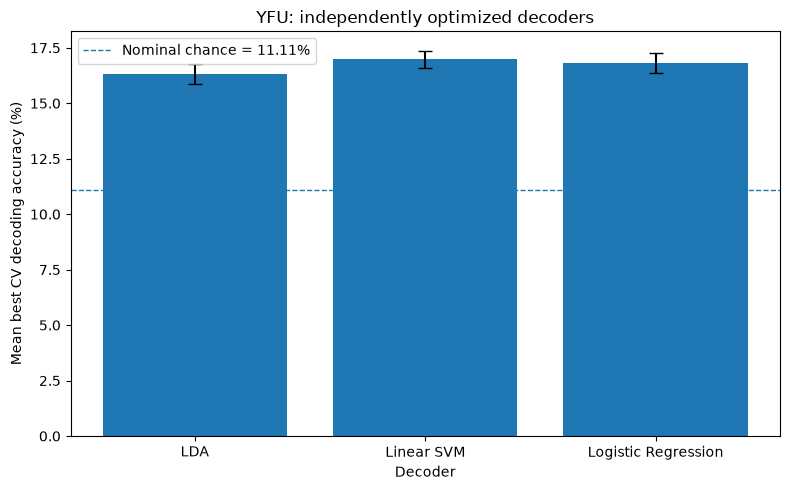

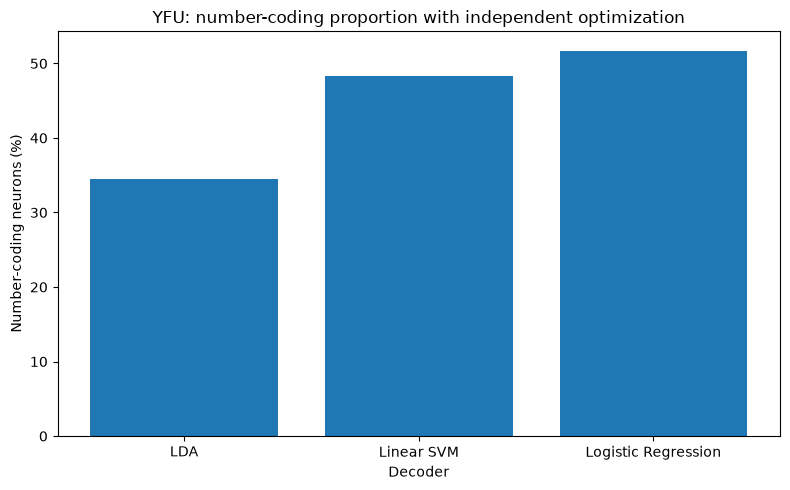


SELECTED TEMPORAL BIN DISTRIBUTION


,decoder,best_bin_ms,count
0,LDA,60,5
1,LDA,75,3
2,LDA,90,5
3,LDA,100,3
4,LDA,150,2
5,LDA,180,2
6,LDA,225,1
7,LDA,300,2
8,LDA,450,2
9,LDA,900,4


In [41]:
# ============================================================
# YFU: ALL-NEURON INDEPENDENT DECODER COMPARISON
#
# Each neuron is analyzed independently with:
#
#   LDA:
#       search bin size independently
#       search gamma independently
#
#   Logistic Regression:
#       search bin size independently
#       search C independently
#
#   Linear SVM:
#       search bin size independently
#       search C independently
#
# After model selection, each decoder receives its OWN
# permutation test using its OWN selected:
#
#       temporal bin
#       hyperparameter
#
# No selected setting is shared between decoders.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.base import clone
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

from src.firing_rate_tuning import analyze_neuron
from src.number_decoding_analysis import make_temporal_features


# ============================================================
# 1. SETTINGS
# ============================================================

SUBJECT = "YFI"

BIN_SIZES = [
    60, 75, 90, 100, 150,
    180, 225, 300, 450, 900
]

LDA_GAMMAS = [
    0.2,
    0.5,
    0.8,
]

C_VALUES = [
    0.01,
    0.1,
    1.0,
    10.0,
    100.0,
]

MAX_SPLITS = 10

N_PERMUTATIONS = 200

CV_RANDOM_STATE = 42
PERMUTATION_SEED = 12345


# ============================================================
# 2. OUTPUT FILES
# ============================================================

OUTPUT_FILE = (
    TABLES_DIR /
    "YFU_independent_three_decoder_comparison.csv"
)

CHECKPOINT_FILE = (
    TABLES_DIR /
    "YFU_independent_three_decoder_checkpoint.csv"
)


# ============================================================
# 3. GET YFU NEURON LIST
# ============================================================
#
# Use the neurons that successfully entered our previous
# Figure 1 analysis.
#
# This avoids accidentally introducing a different neuron set.
# ============================================================

master = pd.read_csv(
    TABLES_DIR /
    "figure1M_all_neuron_permutations.csv"
)

yfu_master = (
    master[
        master["subject"] == SUBJECT
    ]
    .copy()
    .sort_values("neuron")
    .reset_index(drop=True)
)

NEURONS = (
    yfu_master["neuron"]
    .astype(int)
    .tolist()
)


print("=" * 75)
print("YFU INDEPENDENT DECODER ANALYSIS")
print("=" * 75)

print(
    "Number of YFU neurons:",
    len(NEURONS)
)

print(
    "Neurons:",
    NEURONS
)


# ============================================================
# 4. MODEL BUILDERS
# ============================================================

def make_lda(gamma):

    return LinearDiscriminantAnalysis(
        solver="lsqr",
        shrinkage=gamma,
        priors=np.ones(9) / 9,
    )


def make_logistic(C):

    return Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                C=C,
                l1_ratio=0,
                solver="lbfgs",
                max_iter=5000,
                class_weight="balanced",
                random_state=CV_RANDOM_STATE,
            )
        ),
    ])


def make_svm(C):

    return Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            SVC(
                kernel="linear",
                C=C,
                class_weight="balanced",
            )
        ),
    ])


# ============================================================
# 5. CV ACCURACY
# ============================================================

def cv_accuracy(
    model,
    X,
    y,
    splits,
):

    predictions = np.empty_like(y)

    for train_idx, test_idx in splits:

        fold_model = clone(
            model
        )

        fold_model.fit(
            X[train_idx],
            y[train_idx],
        )

        predictions[test_idx] = (
            fold_model.predict(
                X[test_idx]
            )
        )

    return np.mean(
        predictions == y
    )


# ============================================================
# 6. SEARCH ONE DECODER
# ============================================================
#
# This function independently searches:
#
#   all bin sizes
#   all hyperparameters
#
# for ONE decoder.
# ============================================================

def search_decoder(
    decoder_name,
    features_by_bin,
    y,
    splits,
):

    search_rows = []


    # --------------------------------------------------------
    # LDA
    # --------------------------------------------------------

    if decoder_name == "LDA":

        for bin_size in BIN_SIZES:

            X = features_by_bin[
                bin_size
            ]

            for gamma in LDA_GAMMAS:

                model = make_lda(
                    gamma
                )

                accuracy = cv_accuracy(
                    model,
                    X,
                    y,
                    splits,
                )

                search_rows.append({

                    "bin_ms":
                        bin_size,

                    "parameter_name":
                        "gamma",

                    "parameter_value":
                        gamma,

                    "accuracy":
                        accuracy,
                })


    # --------------------------------------------------------
    # LOGISTIC REGRESSION
    # --------------------------------------------------------

    elif decoder_name == "Logistic Regression":

        for bin_size in BIN_SIZES:

            X = features_by_bin[
                bin_size
            ]

            for C in C_VALUES:

                model = make_logistic(
                    C
                )

                accuracy = cv_accuracy(
                    model,
                    X,
                    y,
                    splits,
                )

                search_rows.append({

                    "bin_ms":
                        bin_size,

                    "parameter_name":
                        "C",

                    "parameter_value":
                        C,

                    "accuracy":
                        accuracy,
                })


    # --------------------------------------------------------
    # LINEAR SVM
    # --------------------------------------------------------

    elif decoder_name == "Linear SVM":

        for bin_size in BIN_SIZES:

            X = features_by_bin[
                bin_size
            ]

            for C in C_VALUES:

                model = make_svm(
                    C
                )

                accuracy = cv_accuracy(
                    model,
                    X,
                    y,
                    splits,
                )

                search_rows.append({

                    "bin_ms":
                        bin_size,

                    "parameter_name":
                        "C",

                    "parameter_value":
                        C,

                    "accuracy":
                        accuracy,
                })


    else:

        raise ValueError(
            f"Unknown decoder: {decoder_name}"
        )


    search_df = pd.DataFrame(
        search_rows
    )


    # --------------------------------------------------------
    # Explicit deterministic tie-breaking
    #
    # 1. highest accuracy
    # 2. smaller bin
    # 3. smaller parameter
    # --------------------------------------------------------

    search_df = search_df.sort_values(
        [
            "accuracy",
            "bin_ms",
            "parameter_value",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )


    best = search_df.iloc[0]


    return {
        "bin_ms":
            int(best["bin_ms"]),

        "parameter_name":
            best["parameter_name"],

        "parameter_value":
            float(best["parameter_value"]),

        "accuracy":
            float(best["accuracy"]),

        "search_table":
            search_df,
    }


# ============================================================
# 7. BUILD FINAL MODEL
# ============================================================

def build_selected_model(
    decoder_name,
    parameter_value,
):

    if decoder_name == "LDA":

        return make_lda(
            parameter_value
        )


    if decoder_name == "Logistic Regression":

        return make_logistic(
            parameter_value
        )


    if decoder_name == "Linear SVM":

        return make_svm(
            parameter_value
        )


    raise ValueError(
        f"Unknown decoder: {decoder_name}"
    )


# ============================================================
# 8. STORAGE
# ============================================================

all_results = []

overall_start = time.time()


# ============================================================
# 9. LOOP THROUGH ALL YFU NEURONS
# ============================================================

for neuron_position, NEURON in enumerate(
    NEURONS,
    start=1,
):

    neuron_start = time.time()


    print()
    print("=" * 75)

    print(
        f"YFU neuron {NEURON} "
        f"({neuron_position}/{len(NEURONS)})"
    )

    print("=" * 75)


    try:

        # ====================================================
        # LOAD NEURON
        # ====================================================

        result = analyze_neuron(
            SUBJECT,
            NEURON,
            root=ROOT,
            plot=False,
            verbose=False,
        )

        presentations = result[
            "presentations"
        ]

        spike_times = result[
            "spike_times"
        ]


        # ====================================================
        # CACHE ALL TEMPORAL REPRESENTATIONS
        # ====================================================

        features_by_bin = {}

        reference_y = None


        for bin_size in BIN_SIZES:

            X, y_bin, _ = make_temporal_features(
                presentations,
                spike_times,
                bin_size=bin_size,
            )


            if reference_y is None:

                reference_y = (
                    y_bin.copy()
                )

            else:

                if not np.array_equal(
                    reference_y,
                    y_bin,
                ):

                    raise ValueError(
                        "Labels differ between bin sizes."
                    )


            features_by_bin[
                bin_size
            ] = X


        y = reference_y


        # ====================================================
        # AUTOMATIC VALID NUMBER OF CV FOLDS
        # ====================================================

        classes, class_counts = np.unique(
            y,
            return_counts=True,
        )

        min_class_count = int(
            class_counts.min()
        )

        n_splits = min(
            MAX_SPLITS,
            min_class_count,
        )


        if n_splits < 2:

            print(
                "Skipped: insufficient observations."
            )

            continue


        print(
            "Presentations:",
            len(y)
        )

        print(
            "Minimum class count:",
            min_class_count
        )

        print(
            "CV folds:",
            n_splits
        )


        # ====================================================
        # COMMON OBSERVED FOLDS
        # ====================================================
        #
        # Sharing folds does NOT make the decoders dependent.
        #
        # It simply means all three are compared on the same
        # held-out observations.
        # ====================================================

        observed_cv = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=CV_RANDOM_STATE,
        )

        observed_splits = list(
            observed_cv.split(
                np.zeros(len(y)),
                y,
            )
        )


        # ====================================================
        # COMPLETELY INDEPENDENT MODEL SELECTION
        # ====================================================

        selected = {}


        for decoder_name in [
            "LDA",
            "Logistic Regression",
            "Linear SVM",
        ]:

            selected[
                decoder_name
            ] = search_decoder(
                decoder_name,
                features_by_bin,
                y,
                observed_splits,
            )


            s = selected[
                decoder_name
            ]


            print()

            print(
                f"{decoder_name:<22} | "
                f"bin = {s['bin_ms']:>3} ms | "
                f"{s['parameter_name']} = "
                f"{s['parameter_value']:<6g} | "
                f"accuracy = "
                f"{100*s['accuracy']:.3f}%"
            )


        # ====================================================
        # SAME NULL LABEL DATASETS FOR ALL DECODERS
        # ====================================================
        #
        # Each decoder still uses its own selected X/model.
        # Sharing the shuffled labels makes comparison cleaner.
        # ====================================================

        rng = np.random.default_rng(
            PERMUTATION_SEED + NEURON
        )

        permuted_labels = [
            rng.permutation(y)
            for _ in range(
                N_PERMUTATIONS
            )
        ]


        # ====================================================
        # PERMUTATION TEST EACH DECODER INDEPENDENTLY
        # ====================================================

        for decoder_name in [
            "LDA",
            "Logistic Regression",
            "Linear SVM",
        ]:

            s = selected[
                decoder_name
            ]


            # -----------------------------------------------
            # THIS DECODER'S OWN REPRESENTATION
            # -----------------------------------------------

            X_selected = features_by_bin[
                s["bin_ms"]
            ]


            # -----------------------------------------------
            # THIS DECODER'S OWN MODEL
            # -----------------------------------------------

            model = build_selected_model(
                decoder_name,
                s["parameter_value"],
            )


            null_accuracies = np.empty(
                N_PERMUTATIONS
            )


            for permutation_index, y_perm in enumerate(
                permuted_labels
            ):

                # -------------------------------------------
                # Automatic fold validity is preserved
                # because permutation keeps class counts.
                # -------------------------------------------

                permutation_cv = StratifiedKFold(
                    n_splits=n_splits,
                    shuffle=True,
                    random_state=CV_RANDOM_STATE,
                )

                permutation_splits = list(
                    permutation_cv.split(
                        np.zeros(len(y_perm)),
                        y_perm,
                    )
                )


                null_accuracies[
                    permutation_index
                ] = cv_accuracy(
                    model,
                    X_selected,
                    y_perm,
                    permutation_splits,
                )


            observed_accuracy = (
                s["accuracy"]
            )


            p_value = (
                1
                +
                np.sum(
                    null_accuracies
                    >= observed_accuracy
                )
            ) / (
                1
                +
                N_PERMUTATIONS
            )


            number_coding = (
                p_value < 0.05
            )


            all_results.append({

                "subject":
                    SUBJECT,

                "neuron":
                    NEURON,

                "decoder":
                    decoder_name,

                "n_presentations":
                    len(y),

                "min_class_count":
                    min_class_count,

                "n_splits":
                    n_splits,

                "best_bin_ms":
                    s["bin_ms"],

                "hyperparameter":
                    s["parameter_name"],

                "hyperparameter_value":
                    s["parameter_value"],

                "accuracy":
                    observed_accuracy,

                "accuracy_pct":
                    100 * observed_accuracy,

                "null_mean":
                    null_accuracies.mean(),

                "null_mean_pct":
                    100 * null_accuracies.mean(),

                "null_sd":
                    null_accuracies.std(
                        ddof=1
                    ),

                "null_sd_pct":
                    100 * null_accuracies.std(
                        ddof=1
                    ),

                "p_value":
                    p_value,

                "number_coding":
                    number_coding,
            })


            print(
                f"    permutation -> "
                f"{decoder_name:<22} | "
                f"null = "
                f"{100*null_accuracies.mean():.2f}% | "
                f"p = {p_value:.4f} | "
                f"coding = {number_coding}"
            )


        # ====================================================
        # CHECKPOINT AFTER EVERY NEURON
        # ====================================================

        checkpoint = pd.DataFrame(
            all_results
        )

        checkpoint.to_csv(
            CHECKPOINT_FILE,
            index=False,
        )


        neuron_elapsed = (
            time.time()
            - neuron_start
        )


        print(
            f"\nNeuron runtime: "
            f"{neuron_elapsed/60:.2f} min"
        )


    except Exception as error:

        print(
            f"\nFAILED neuron {NEURON}: "
            f"{type(error).__name__}: {error}"
        )


# ============================================================
# 10. FINAL DATAFRAME
# ============================================================

decoder_results = pd.DataFrame(
    all_results
)


decoder_results.to_csv(
    OUTPUT_FILE,
    index=False,
)


overall_elapsed = (
    time.time()
    - overall_start
)


print()
print("=" * 75)
print("ANALYSIS COMPLETE")
print("=" * 75)

print(
    "Runtime:",
    f"{overall_elapsed/60:.2f} minutes"
)

print(
    "Saved:",
    OUTPUT_FILE
)


# ============================================================
# 11. SUBJECT-LEVEL SUMMARY
# ============================================================

subject_summary = (
    decoder_results
    .groupby("decoder")
    .agg(

        n_neurons=(
            "neuron",
            "count"
        ),

        mean_accuracy_pct=(
            "accuracy_pct",
            "mean"
        ),

        sem_accuracy_pct=(
            "accuracy_pct",
            "sem"
        ),

        median_accuracy_pct=(
            "accuracy_pct",
            "median"
        ),

        mean_null_pct=(
            "null_mean_pct",
            "mean"
        ),

        coding_neurons=(
            "number_coding",
            "sum"
        ),

        coding_proportion=(
            "number_coding",
            "mean"
        ),
    )
    .reset_index()
)


subject_summary[
    "coding_proportion_pct"
] = (
    100
    *
    subject_summary[
        "coding_proportion"
    ]
)


print()
print("=" * 75)
print("YFU SUBJECT SUMMARY")
print("=" * 75)

display(
    subject_summary.round(3)
)


# ============================================================
# 12. ACCURACY BY NEURON
# ============================================================

accuracy_pivot = (
    decoder_results
    .pivot(
        index="neuron",
        columns="decoder",
        values="accuracy_pct",
    )
)


print()
print("=" * 75)
print("ACCURACY BY NEURON")
print("=" * 75)

display(
    accuracy_pivot.round(2)
)


# ============================================================
# 13. SELECTED BIN BY NEURON
# ============================================================

bin_pivot = (
    decoder_results
    .pivot(
        index="neuron",
        columns="decoder",
        values="best_bin_ms",
    )
)


print()
print("=" * 75)
print("INDEPENDENTLY SELECTED BIN SIZE BY NEURON")
print("=" * 75)

display(
    bin_pivot
)


# ============================================================
# 14. CODING STATUS BY NEURON
# ============================================================

coding_pivot = (
    decoder_results
    .pivot(
        index="neuron",
        columns="decoder",
        values="number_coding",
    )
)


print()
print("=" * 75)
print("CODING STATUS BY NEURON")
print("=" * 75)

display(
    coding_pivot
)


# ============================================================
# 15. MEAN ACCURACY PLOT
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    subject_summary["decoder"],
    subject_summary["mean_accuracy_pct"],
    yerr=subject_summary["sem_accuracy_pct"],
    capsize=5,
)

plt.axhline(
    100 / 9,
    linestyle="--",
    linewidth=1,
    label="Nominal chance = 11.11%",
)

plt.ylabel(
    "Mean best CV decoding accuracy (%)"
)

plt.xlabel(
    "Decoder"
)

plt.title(
    "YFU: independently optimized decoders"
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 16. CODING PROPORTION PLOT
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    subject_summary["decoder"],
    subject_summary[
        "coding_proportion_pct"
    ],
)

plt.ylabel(
    "Number-coding neurons (%)"
)

plt.xlabel(
    "Decoder"
)

plt.title(
    "YFU: number-coding proportion "
    "with independent optimization"
)

plt.tight_layout()
plt.show()


# ============================================================
# 17. SELECTED BIN DISTRIBUTION
# ============================================================

bin_counts = (
    decoder_results
    .groupby(
        [
            "decoder",
            "best_bin_ms",
        ]
    )
    .size()
    .reset_index(
        name="count"
    )
)


print()
print("=" * 75)
print("SELECTED TEMPORAL BIN DISTRIBUTION")
print("=" * 75)

display(
    bin_counts
)

CODING STATUS OF EACH YFI NEURON


decoder,LDA,Logistic Regression,Linear SVM
neuron,,,
1,False,False,False
2,True,True,True
3,True,False,True
4,True,True,True
5,False,True,False
6,False,False,False
7,False,False,False
8,True,True,True
9,False,False,False



Individual decoder coding sets
--------------------------------
LDA: [2, 3, 4, 8, 21, 24, 26, 30, 31, 35] (N=10)
Logistic: [2, 4, 5, 8, 21, 22, 24, 26, 29, 30, 31, 32, 33, 35, 37] (N=15)
SVM: [2, 3, 4, 8, 19, 20, 21, 22, 24, 26, 31, 32, 35, 38] (N=14)

EXACT OVERLAP

ALL THREE: [2, 4, 8, 21, 24, 26, 31, 35] (N=8)

LDA + Logistic only: [30] (N=1)

LDA + SVM only: [3] (N=1)

Logistic + SVM only: [22, 32] (N=2)

LDA only: [] (N=0)

Logistic only: [5, 29, 33, 37] (N=4)

SVM only: [19, 20, 38] (N=3)

NONE: [1, 6, 7, 9, 23, 25, 27, 28, 34, 36] (N=10)

PAIRWISE OVERLAP


,comparison,n_neurons
0,LDA ∩ Logistic,9
1,LDA ∩ SVM,9
2,Logistic ∩ SVM,10
3,All three,8
4,Any decoder,19
5,No decoder,10



NUMBER OF DECODERS CALLING EACH NEURON CODING


decoder,LDA,Logistic Regression,Linear SVM,n_decoders_coding
neuron,,,,
2,True,True,True,3
4,True,True,True,3
8,True,True,True,3
21,True,True,True,3
24,True,True,True,3
31,True,True,True,3
35,True,True,True,3
26,True,True,True,3
30,True,True,False,2



AGREEMENT SUMMARY


,number_of_decoders,number_of_neurons,percentage
0,0,10,34.48
1,1,7,24.14
2,2,4,13.79
3,3,8,27.59


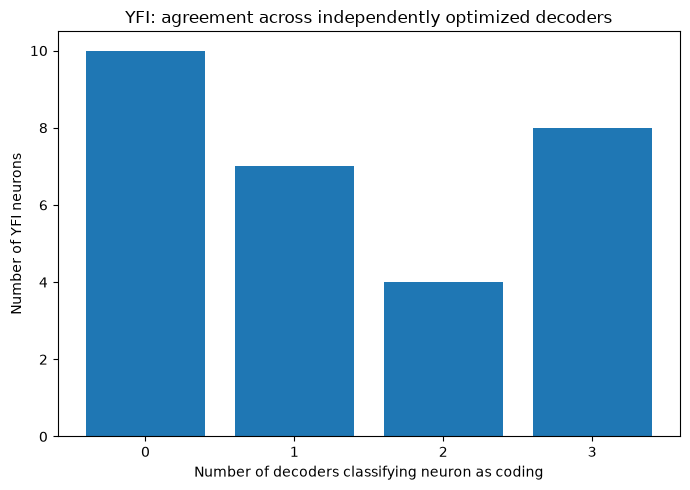


Saved: C:\Users\shafi\number-simplex-reproduction\tables1\YFI_decoder_coding_overlap.csv


In [42]:
# ============================================================
# YFI: OVERLAP OF NUMBER-CODING NEURONS
#
# LDA vs Logistic Regression vs Linear SVM
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. LOAD COMPLETED YFI RESULTS
# ============================================================

df = pd.read_csv(
    TABLES_DIR /
    "YFU_independent_three_decoder_comparison.csv"
)

# IMPORTANT:
# Your file was accidentally named YFU,
# but these results are actually YFI.
df["subject"] = "YFI"


# ============================================================
# 2. CREATE CODING-STATUS TABLE
# ============================================================

coding = (
    df
    .pivot(
        index="neuron",
        columns="decoder",
        values="number_coding",
    )
    .astype(bool)
)


# Put columns in convenient order
coding = coding[
    [
        "LDA",
        "Logistic Regression",
        "Linear SVM",
    ]
]


print("=" * 70)
print("CODING STATUS OF EACH YFI NEURON")
print("=" * 70)

display(coding)


# ============================================================
# 3. CREATE SETS OF CODING NEURONS
# ============================================================

lda = set(
    coding.index[
        coding["LDA"]
    ]
)

logistic = set(
    coding.index[
        coding["Logistic Regression"]
    ]
)

svm = set(
    coding.index[
        coding["Linear SVM"]
    ]
)


print("\nIndividual decoder coding sets")
print("--------------------------------")

print(
    "LDA:",
    sorted(lda),
    f"(N={len(lda)})"
)

print(
    "Logistic:",
    sorted(logistic),
    f"(N={len(logistic)})"
)

print(
    "SVM:",
    sorted(svm),
    f"(N={len(svm)})"
)


# ============================================================
# 4. ALL THREE
# ============================================================

all_three = (
    lda
    & logistic
    & svm
)


# ============================================================
# 5. EXACTLY TWO DECODERS
# ============================================================

lda_logistic_only = (
    (lda & logistic)
    - svm
)

lda_svm_only = (
    (lda & svm)
    - logistic
)

logistic_svm_only = (
    (logistic & svm)
    - lda
)


# ============================================================
# 6. ONLY ONE DECODER
# ============================================================

lda_only = (
    lda
    - logistic
    - svm
)

logistic_only = (
    logistic
    - lda
    - svm
)

svm_only = (
    svm
    - lda
    - logistic
)


# ============================================================
# 7. NONE OF THE THREE
# ============================================================

all_neurons = set(
    coding.index
)

any_decoder = (
    lda
    | logistic
    | svm
)

none = (
    all_neurons
    - any_decoder
)


# ============================================================
# 8. PRINT EXACT OVERLAP
# ============================================================

print()
print("=" * 70)
print("EXACT OVERLAP")
print("=" * 70)


print(
    "\nALL THREE:",
    sorted(all_three),
    f"(N={len(all_three)})"
)


print(
    "\nLDA + Logistic only:",
    sorted(lda_logistic_only),
    f"(N={len(lda_logistic_only)})"
)


print(
    "\nLDA + SVM only:",
    sorted(lda_svm_only),
    f"(N={len(lda_svm_only)})"
)


print(
    "\nLogistic + SVM only:",
    sorted(logistic_svm_only),
    f"(N={len(logistic_svm_only)})"
)


print(
    "\nLDA only:",
    sorted(lda_only),
    f"(N={len(lda_only)})"
)


print(
    "\nLogistic only:",
    sorted(logistic_only),
    f"(N={len(logistic_only)})"
)


print(
    "\nSVM only:",
    sorted(svm_only),
    f"(N={len(svm_only)})"
)


print(
    "\nNONE:",
    sorted(none),
    f"(N={len(none)})"
)


# ============================================================
# 9. PAIRWISE OVERLAP
# ============================================================

pairwise = pd.DataFrame({

    "comparison": [
        "LDA ∩ Logistic",
        "LDA ∩ SVM",
        "Logistic ∩ SVM",
        "All three",
        "Any decoder",
        "No decoder",
    ],

    "n_neurons": [
        len(lda & logistic),
        len(lda & svm),
        len(logistic & svm),
        len(all_three),
        len(any_decoder),
        len(none),
    ]
})


print()
print("=" * 70)
print("PAIRWISE OVERLAP")
print("=" * 70)

display(pairwise)


# ============================================================
# 10. AGREEMENT COUNT FOR EACH NEURON
# ============================================================

coding["n_decoders_coding"] = (
    coding[
        [
            "LDA",
            "Logistic Regression",
            "Linear SVM",
        ]
    ]
    .sum(axis=1)
)


print()
print("=" * 70)
print("NUMBER OF DECODERS CALLING EACH NEURON CODING")
print("=" * 70)

display(
    coding.sort_values(
        "n_decoders_coding",
        ascending=False,
    )
)


# ============================================================
# 11. SUMMARY BY AGREEMENT LEVEL
# ============================================================

agreement_summary = (
    coding[
        "n_decoders_coding"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "number_of_decoders"
    )
    .reset_index(
        name="number_of_neurons"
    )
)

agreement_summary[
    "percentage"
] = (
    100
    *
    agreement_summary[
        "number_of_neurons"
    ]
    / len(coding)
)


print()
print("=" * 70)
print("AGREEMENT SUMMARY")
print("=" * 70)

display(
    agreement_summary.round(2)
)


# ============================================================
# 12. SIMPLE AGREEMENT PLOT
# ============================================================

plt.figure(
    figsize=(7, 5)
)

plt.bar(
    agreement_summary[
        "number_of_decoders"
    ].astype(str),
    agreement_summary[
        "number_of_neurons"
    ],
)

plt.xlabel(
    "Number of decoders classifying neuron as coding"
)

plt.ylabel(
    "Number of YFI neurons"
)

plt.title(
    "YFI: agreement across independently optimized decoders"
)

plt.tight_layout()
plt.show()


# ============================================================
# 13. SAVE OVERLAP TABLE
# ============================================================

coding.reset_index().to_csv(
    TABLES_DIR /
    "YFI_decoder_coding_overlap.csv",
    index=False,
)

print(
    "\nSaved:",
    TABLES_DIR /
    "YFI_decoder_coding_overlap.csv"
)

YFK INDEPENDENT DECODER ANALYSIS
Number of YFK neurons: 44
Neurons: [25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68]

YFK neuron 25 (1/44)
Presentations: 114
Minimum class count: 4
CV folds: 4

LDA                    | bin =  60 ms | gamma = 0.2    | accuracy = 20.175%

Logistic Regression    | bin =  60 ms | C = 0.1    | accuracy = 17.544%

Linear SVM             | bin = 300 ms | C = 0.1    | accuracy = 14.912%
    permutation -> LDA                    | null = 11.47% | p = 0.0100 | coding = True
    permutation -> Logistic Regression    | null = 11.15% | p = 0.0398 | coding = True
    permutation -> Linear SVM             | null = 10.09% | p = 0.0995 | coding = False

Neuron runtime: 0.21 min

YFK neuron 26 (2/44)
Presentations: 114
Minimum class count: 4
CV folds: 4

LDA                    | bin = 180 ms | gamma = 0.8    | accuracy = 10.526%

Logistic Regre

,decoder,n_neurons,mean_accuracy_pct,sem_accuracy_pct,median_accuracy_pct,mean_null_pct,coding_neurons,coding_proportion,coding_proportion_pct
0,LDA,44,15.909,0.603,15.789,10.985,17,0.386,38.636
1,Linear SVM,44,16.986,0.493,16.667,11.122,22,0.500,50.000
2,Logistic Regression,44,16.288,0.449,16.667,10.451,22,0.500,50.000



YFK: ACCURACY BY NEURON


decoder,LDA,Linear SVM,Logistic Regression
neuron,,,
25,20.18,14.91,17.54
26,10.53,13.16,12.28
27,28.07,23.68,24.56
28,16.67,15.79,16.67
29,16.67,17.54,16.67
30,19.30,20.18,21.05
31,21.05,21.05,20.18
32,15.79,16.67,17.54
33,13.16,14.04,14.04



YFK: INDEPENDENTLY SELECTED BIN SIZE BY NEURON


decoder,LDA,Linear SVM,Logistic Regression
neuron,,,
25,60,300,60
26,180,60,60
27,225,225,225
28,60,60,60
29,900,60,900
30,180,150,150
31,60,150,60
32,300,150,150
33,75,75,75



YFK: CODING STATUS BY NEURON


decoder,LDA,Linear SVM,Logistic Regression
neuron,,,
25,True,False,True
26,False,False,False
27,True,True,True
28,False,False,True
29,True,False,True
30,True,True,True
31,True,True,True
32,True,True,True
33,False,False,False


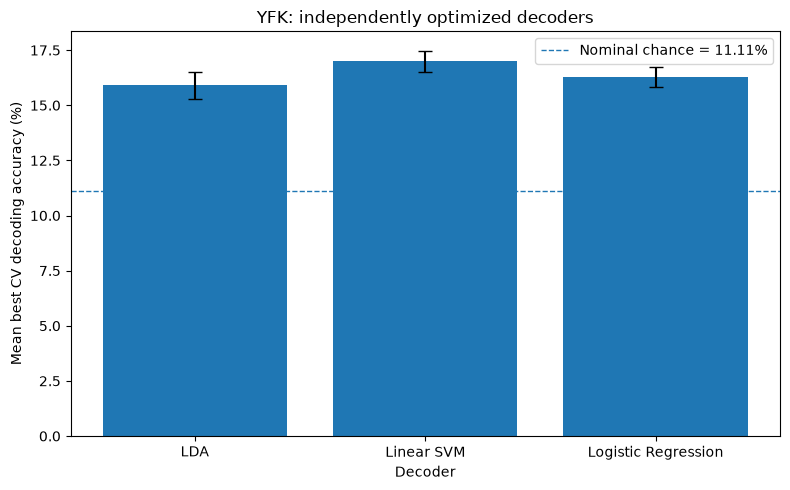

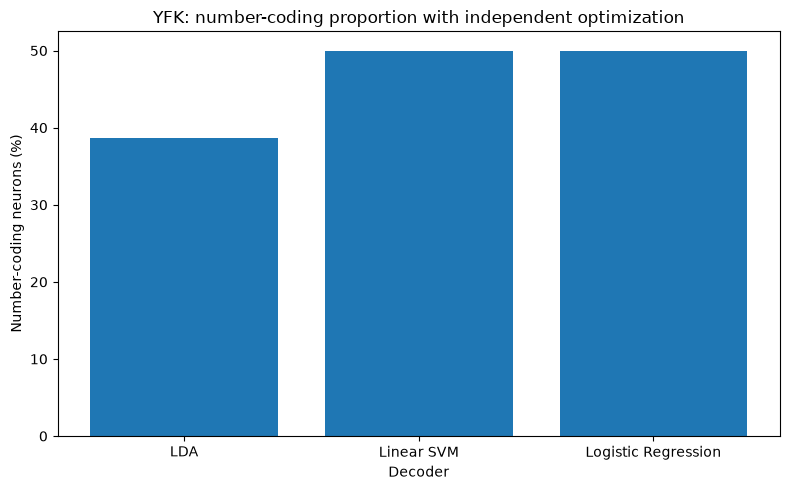


YFK: SELECTED TEMPORAL BIN DISTRIBUTION


,decoder,best_bin_ms,count
0,LDA,60,14
1,LDA,75,6
2,LDA,90,6
3,LDA,100,1
4,LDA,150,1
5,LDA,180,5
6,LDA,225,3
7,LDA,300,2
8,LDA,450,2
9,LDA,900,4



YFK: EXACT DECODER OVERLAP

LDA coding: [25, 27, 29, 30, 31, 32, 37, 40, 43, 44, 46, 52, 56, 58, 60, 65, 67] (N=17)

Logistic coding: [25, 27, 28, 29, 30, 31, 32, 37, 40, 41, 43, 44, 48, 52, 55, 56, 57, 58, 60, 61, 65, 67] (N=22)

SVM coding: [27, 30, 31, 32, 36, 37, 38, 40, 43, 44, 47, 48, 49, 52, 53, 56, 58, 59, 60, 61, 65, 67] (N=22)

ALL THREE: [27, 30, 31, 32, 37, 40, 43, 44, 52, 56, 58, 60, 65, 67] (N=14)

LDA + Logistic only: [25, 29] (N=2)

LDA + SVM only: [] (N=0)

Logistic + SVM only: [48, 61] (N=2)

LDA only: [46] (N=1)

Logistic only: [28, 41, 55, 57] (N=4)

SVM only: [36, 38, 47, 49, 53, 59] (N=6)

NONE: [26, 33, 34, 35, 39, 42, 45, 50, 51, 54, 62, 63, 64, 66, 68] (N=15)

YFK: DECODER OVERLAP SUMMARY


,comparison,n_neurons
0,LDA ∩ Logistic,16
1,LDA ∩ SVM,14
2,Logistic ∩ SVM,16
3,All three,14
4,Any decoder,29
5,No decoder,15



YFK: DECODER AGREEMENT SUMMARY


,number_of_decoders,number_of_neurons,percentage
0,0,15,34.09
1,1,11,25.00
2,2,4,9.09
3,3,14,31.82



Overlap table saved: C:\Users\shafi\number-simplex-reproduction\tables1\YFK_decoder_coding_overlap.csv


In [43]:
# ============================================================
# ALL-NEURON INDEPENDENT DECODER COMPARISON
#
# CURRENT SUBJECT: YFK
#
# Each neuron is analyzed independently with:
#
#   LDA:
#       independently searches temporal bin size
#       independently searches gamma
#
#   Logistic Regression:
#       independently searches temporal bin size
#       independently searches C
#
#   Linear SVM:
#       independently searches temporal bin size
#       independently searches C
#
# After model selection, each decoder receives its OWN
# permutation test using its OWN selected:
#
#       temporal bin
#       hyperparameter
#
# No selected setting is shared between decoders.
#
# To run another subject later, change ONLY:
#
#       SUBJECT = "YFK"
#
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

from src.firing_rate_tuning import analyze_neuron
from src.number_decoding_analysis import make_temporal_features


# ============================================================
# 1. SETTINGS
# ============================================================

SUBJECT = "YFK"

BIN_SIZES = [
    60, 75, 90, 100, 150,
    180, 225, 300, 450, 900
]

LDA_GAMMAS = [
    0.2,
    0.5,
    0.8,
]

C_VALUES = [
    0.01,
    0.1,
    1.0,
    10.0,
    100.0,
]

MAX_SPLITS = 10

N_PERMUTATIONS = 200

CV_RANDOM_STATE = 42
PERMUTATION_SEED = 12345


# ============================================================
# 2. OUTPUT FILES
# ============================================================
#
# Filenames now automatically use SUBJECT.
# ============================================================

OUTPUT_FILE = (
    TABLES_DIR /
    f"{SUBJECT}_independent_three_decoder_comparison.csv"
)

CHECKPOINT_FILE = (
    TABLES_DIR /
    f"{SUBJECT}_independent_three_decoder_checkpoint.csv"
)


# ============================================================
# 3. GET SUBJECT NEURON LIST
# ============================================================
#
# Use exactly the neurons that successfully entered our
# previous Figure 1 analysis.
# ============================================================

master = pd.read_csv(
    TABLES_DIR /
    "figure1M_all_neuron_permutations.csv"
)

subject_master = (
    master[
        master["subject"] == SUBJECT
    ]
    .copy()
    .sort_values("neuron")
    .reset_index(drop=True)
)

NEURONS = (
    subject_master["neuron"]
    .astype(int)
    .tolist()
)


print("=" * 75)
print(f"{SUBJECT} INDEPENDENT DECODER ANALYSIS")
print("=" * 75)

print(
    f"Number of {SUBJECT} neurons:",
    len(NEURONS)
)

print(
    "Neurons:",
    NEURONS
)


# ============================================================
# 4. MODEL BUILDERS
# ============================================================

def make_lda(gamma):

    return LinearDiscriminantAnalysis(
        solver="lsqr",
        shrinkage=gamma,
        priors=np.ones(9) / 9,
    )


def make_logistic(C):

    return Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                C=C,
                l1_ratio=0,
                solver="lbfgs",
                max_iter=5000,
                class_weight="balanced",
                random_state=CV_RANDOM_STATE,
            )
        ),
    ])


def make_svm(C):

    return Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            SVC(
                kernel="linear",
                C=C,
                class_weight="balanced",
            )
        ),
    ])


# ============================================================
# 5. CV ACCURACY
# ============================================================

def cv_accuracy(
    model,
    X,
    y,
    splits,
):

    predictions = np.empty_like(y)

    for train_idx, test_idx in splits:

        fold_model = clone(
            model
        )

        fold_model.fit(
            X[train_idx],
            y[train_idx],
        )

        predictions[test_idx] = (
            fold_model.predict(
                X[test_idx]
            )
        )

    return np.mean(
        predictions == y
    )


# ============================================================
# 6. SEARCH ONE DECODER
# ============================================================
#
# Each decoder independently searches:
#
#   temporal bin size
#   its own hyperparameter
#
# LDA:
#       bin x gamma
#
# Logistic:
#       bin x C
#
# SVM:
#       bin x C
#
# ============================================================

def search_decoder(
    decoder_name,
    features_by_bin,
    y,
    splits,
):

    search_rows = []


    # --------------------------------------------------------
    # LDA
    # --------------------------------------------------------

    if decoder_name == "LDA":

        for bin_size in BIN_SIZES:

            X = features_by_bin[
                bin_size
            ]

            for gamma in LDA_GAMMAS:

                model = make_lda(
                    gamma
                )

                accuracy = cv_accuracy(
                    model,
                    X,
                    y,
                    splits,
                )

                search_rows.append({

                    "bin_ms":
                        bin_size,

                    "parameter_name":
                        "gamma",

                    "parameter_value":
                        gamma,

                    "accuracy":
                        accuracy,
                })


    # --------------------------------------------------------
    # LOGISTIC REGRESSION
    # --------------------------------------------------------

    elif decoder_name == "Logistic Regression":

        for bin_size in BIN_SIZES:

            X = features_by_bin[
                bin_size
            ]

            for C in C_VALUES:

                model = make_logistic(
                    C
                )

                accuracy = cv_accuracy(
                    model,
                    X,
                    y,
                    splits,
                )

                search_rows.append({

                    "bin_ms":
                        bin_size,

                    "parameter_name":
                        "C",

                    "parameter_value":
                        C,

                    "accuracy":
                        accuracy,
                })


    # --------------------------------------------------------
    # LINEAR SVM
    # --------------------------------------------------------

    elif decoder_name == "Linear SVM":

        for bin_size in BIN_SIZES:

            X = features_by_bin[
                bin_size
            ]

            for C in C_VALUES:

                model = make_svm(
                    C
                )

                accuracy = cv_accuracy(
                    model,
                    X,
                    y,
                    splits,
                )

                search_rows.append({

                    "bin_ms":
                        bin_size,

                    "parameter_name":
                        "C",

                    "parameter_value":
                        C,

                    "accuracy":
                        accuracy,
                })


    else:

        raise ValueError(
            f"Unknown decoder: {decoder_name}"
        )


    search_df = pd.DataFrame(
        search_rows
    )


    # --------------------------------------------------------
    # Deterministic tie-breaking:
    #
    # 1. highest accuracy
    # 2. smaller bin
    # 3. smaller parameter
    # --------------------------------------------------------

    search_df = search_df.sort_values(
        [
            "accuracy",
            "bin_ms",
            "parameter_value",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )


    best = search_df.iloc[0]


    return {

        "bin_ms":
            int(best["bin_ms"]),

        "parameter_name":
            best["parameter_name"],

        "parameter_value":
            float(best["parameter_value"]),

        "accuracy":
            float(best["accuracy"]),

        "search_table":
            search_df,
    }


# ============================================================
# 7. BUILD SELECTED MODEL
# ============================================================

def build_selected_model(
    decoder_name,
    parameter_value,
):

    if decoder_name == "LDA":

        return make_lda(
            parameter_value
        )


    if decoder_name == "Logistic Regression":

        return make_logistic(
            parameter_value
        )


    if decoder_name == "Linear SVM":

        return make_svm(
            parameter_value
        )


    raise ValueError(
        f"Unknown decoder: {decoder_name}"
    )


# ============================================================
# 8. STORAGE
# ============================================================

all_results = []

overall_start = time.time()


# ============================================================
# 9. LOOP THROUGH ALL SUBJECT NEURONS
# ============================================================

for neuron_position, NEURON in enumerate(
    NEURONS,
    start=1,
):

    neuron_start = time.time()


    print()
    print("=" * 75)

    print(
        f"{SUBJECT} neuron {NEURON} "
        f"({neuron_position}/{len(NEURONS)})"
    )

    print("=" * 75)


    try:

        # ====================================================
        # LOAD NEURON
        # ====================================================

        result = analyze_neuron(
            SUBJECT,
            NEURON,
            root=ROOT,
            plot=False,
            verbose=False,
        )

        presentations = result[
            "presentations"
        ]

        spike_times = result[
            "spike_times"
        ]


        # ====================================================
        # CACHE ALL TEMPORAL REPRESENTATIONS
        # ====================================================

        features_by_bin = {}

        reference_y = None


        for bin_size in BIN_SIZES:

            X, y_bin, _ = make_temporal_features(
                presentations,
                spike_times,
                bin_size=bin_size,
            )


            if reference_y is None:

                reference_y = (
                    y_bin.copy()
                )

            else:

                if not np.array_equal(
                    reference_y,
                    y_bin,
                ):

                    raise ValueError(
                        "Labels differ between bin sizes."
                    )


            features_by_bin[
                bin_size
            ] = X


        y = reference_y


        # ====================================================
        # AUTOMATIC VALID NUMBER OF CV FOLDS
        # ====================================================
        #
        # Fixes:
        #
        # "least populated class has fewer members than
        # n_splits"
        #
        # We use:
        #
        # n_splits = min(10, minimum class count)
        #
        # ====================================================

        classes, class_counts = np.unique(
            y,
            return_counts=True,
        )

        min_class_count = int(
            class_counts.min()
        )

        n_splits = min(
            MAX_SPLITS,
            min_class_count,
        )


        if n_splits < 2:

            print(
                "Skipped: insufficient observations."
            )

            continue


        print(
            "Presentations:",
            len(y)
        )

        print(
            "Minimum class count:",
            min_class_count
        )

        print(
            "CV folds:",
            n_splits
        )


        # ====================================================
        # COMMON OBSERVED CV FOLDS
        # ====================================================
        #
        # The decoders are independent in:
        #
        #   selected temporal bin
        #   selected hyperparameter
        #   fitted model
        #
        # They intentionally share the SAME train/test
        # partitions for a fair comparison.
        # ====================================================

        observed_cv = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=CV_RANDOM_STATE,
        )

        observed_splits = list(
            observed_cv.split(
                np.zeros(len(y)),
                y,
            )
        )


        # ====================================================
        # COMPLETELY INDEPENDENT MODEL SELECTION
        # ====================================================

        selected = {}


        for decoder_name in [
            "LDA",
            "Logistic Regression",
            "Linear SVM",
        ]:

            selected[
                decoder_name
            ] = search_decoder(
                decoder_name,
                features_by_bin,
                y,
                observed_splits,
            )


            s = selected[
                decoder_name
            ]


            print()

            print(
                f"{decoder_name:<22} | "
                f"bin = {s['bin_ms']:>3} ms | "
                f"{s['parameter_name']} = "
                f"{s['parameter_value']:<6g} | "
                f"accuracy = "
                f"{100*s['accuracy']:.3f}%"
            )


        # ====================================================
        # SAME SHUFFLED LABEL DATASETS FOR ALL DECODERS
        # ====================================================
        #
        # Each decoder still uses its OWN selected:
        #
        #   bin
        #   hyperparameter
        #   model
        #
        # Sharing shuffled label datasets simply gives all
        # decoders the same null-label realizations.
        # ====================================================

        rng = np.random.default_rng(
            PERMUTATION_SEED + NEURON
        )

        permuted_labels = [
            rng.permutation(y)
            for _ in range(
                N_PERMUTATIONS
            )
        ]


        # ====================================================
        # INDEPENDENT PERMUTATION TEST
        # ====================================================

        for decoder_name in [
            "LDA",
            "Logistic Regression",
            "Linear SVM",
        ]:

            s = selected[
                decoder_name
            ]


            # -----------------------------------------------
            # THIS DECODER'S OWN TEMPORAL REPRESENTATION
            # -----------------------------------------------

            X_selected = features_by_bin[
                s["bin_ms"]
            ]


            # -----------------------------------------------
            # THIS DECODER'S OWN SELECTED MODEL
            # -----------------------------------------------

            model = build_selected_model(
                decoder_name,
                s["parameter_value"],
            )


            null_accuracies = np.empty(
                N_PERMUTATIONS
            )


            # -----------------------------------------------
            # 200 PERMUTATIONS
            # -----------------------------------------------

            for permutation_index, y_perm in enumerate(
                permuted_labels
            ):

                permutation_cv = StratifiedKFold(
                    n_splits=n_splits,
                    shuffle=True,
                    random_state=CV_RANDOM_STATE,
                )

                permutation_splits = list(
                    permutation_cv.split(
                        np.zeros(len(y_perm)),
                        y_perm,
                    )
                )


                null_accuracies[
                    permutation_index
                ] = cv_accuracy(
                    model,
                    X_selected,
                    y_perm,
                    permutation_splits,
                )


            observed_accuracy = (
                s["accuracy"]
            )


            # =================================================
            # PERMUTATION P-VALUE
            # =================================================

            p_value = (
                1
                +
                np.sum(
                    null_accuracies
                    >= observed_accuracy
                )
            ) / (
                1
                +
                N_PERMUTATIONS
            )


            number_coding = (
                p_value < 0.05
            )


            # =================================================
            # SAVE RESULT
            # =================================================

            all_results.append({

                "subject":
                    SUBJECT,

                "neuron":
                    NEURON,

                "decoder":
                    decoder_name,

                "n_presentations":
                    len(y),

                "min_class_count":
                    min_class_count,

                "n_splits":
                    n_splits,

                "best_bin_ms":
                    s["bin_ms"],

                "hyperparameter":
                    s["parameter_name"],

                "hyperparameter_value":
                    s["parameter_value"],

                "accuracy":
                    observed_accuracy,

                "accuracy_pct":
                    100 * observed_accuracy,

                "null_mean":
                    null_accuracies.mean(),

                "null_mean_pct":
                    100 * null_accuracies.mean(),

                "null_sd":
                    null_accuracies.std(
                        ddof=1
                    ),

                "null_sd_pct":
                    100 * null_accuracies.std(
                        ddof=1
                    ),

                "p_value":
                    p_value,

                "number_coding":
                    number_coding,
            })


            print(
                f"    permutation -> "
                f"{decoder_name:<22} | "
                f"null = "
                f"{100*null_accuracies.mean():.2f}% | "
                f"p = {p_value:.4f} | "
                f"coding = {number_coding}"
            )


        # ====================================================
        # CHECKPOINT AFTER EVERY NEURON
        # ====================================================

        checkpoint = pd.DataFrame(
            all_results
        )

        checkpoint.to_csv(
            CHECKPOINT_FILE,
            index=False,
        )


        neuron_elapsed = (
            time.time()
            - neuron_start
        )


        print(
            f"\nNeuron runtime: "
            f"{neuron_elapsed/60:.2f} min"
        )


    except Exception as error:

        print(
            f"\nFAILED neuron {NEURON}: "
            f"{type(error).__name__}: {error}"
        )


# ============================================================
# 10. FINAL DATAFRAME
# ============================================================

decoder_results = pd.DataFrame(
    all_results
)


decoder_results.to_csv(
    OUTPUT_FILE,
    index=False,
)


overall_elapsed = (
    time.time()
    - overall_start
)


print()
print("=" * 75)
print("ANALYSIS COMPLETE")
print("=" * 75)

print(
    "Subject:",
    SUBJECT
)

print(
    "Runtime:",
    f"{overall_elapsed/60:.2f} minutes"
)

print(
    "Saved:",
    OUTPUT_FILE
)


# ============================================================
# 11. SUBJECT-LEVEL SUMMARY
# ============================================================

subject_summary = (
    decoder_results
    .groupby("decoder")
    .agg(

        n_neurons=(
            "neuron",
            "count"
        ),

        mean_accuracy_pct=(
            "accuracy_pct",
            "mean"
        ),

        sem_accuracy_pct=(
            "accuracy_pct",
            "sem"
        ),

        median_accuracy_pct=(
            "accuracy_pct",
            "median"
        ),

        mean_null_pct=(
            "null_mean_pct",
            "mean"
        ),

        coding_neurons=(
            "number_coding",
            "sum"
        ),

        coding_proportion=(
            "number_coding",
            "mean"
        ),
    )
    .reset_index()
)


subject_summary[
    "coding_proportion_pct"
] = (
    100
    *
    subject_summary[
        "coding_proportion"
    ]
)


print()
print("=" * 75)
print(f"{SUBJECT} SUBJECT SUMMARY")
print("=" * 75)

display(
    subject_summary.round(3)
)


# ============================================================
# 12. ACCURACY BY NEURON
# ============================================================

accuracy_pivot = (
    decoder_results
    .pivot(
        index="neuron",
        columns="decoder",
        values="accuracy_pct",
    )
)


print()
print("=" * 75)
print(f"{SUBJECT}: ACCURACY BY NEURON")
print("=" * 75)

display(
    accuracy_pivot.round(2)
)


# ============================================================
# 13. SELECTED BIN BY NEURON
# ============================================================

bin_pivot = (
    decoder_results
    .pivot(
        index="neuron",
        columns="decoder",
        values="best_bin_ms",
    )
)


print()
print("=" * 75)
print(f"{SUBJECT}: INDEPENDENTLY SELECTED BIN SIZE BY NEURON")
print("=" * 75)

display(
    bin_pivot
)


# ============================================================
# 14. CODING STATUS BY NEURON
# ============================================================

coding_pivot = (
    decoder_results
    .pivot(
        index="neuron",
        columns="decoder",
        values="number_coding",
    )
)


print()
print("=" * 75)
print(f"{SUBJECT}: CODING STATUS BY NEURON")
print("=" * 75)

display(
    coding_pivot
)


# ============================================================
# 15. MEAN ACCURACY PLOT
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    subject_summary["decoder"],
    subject_summary[
        "mean_accuracy_pct"
    ],
    yerr=subject_summary[
        "sem_accuracy_pct"
    ],
    capsize=5,
)

plt.axhline(
    100 / 9,
    linestyle="--",
    linewidth=1,
    label="Nominal chance = 11.11%",
)

plt.ylabel(
    "Mean best CV decoding accuracy (%)"
)

plt.xlabel(
    "Decoder"
)

plt.title(
    f"{SUBJECT}: independently optimized decoders"
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 16. CODING PROPORTION PLOT
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    subject_summary["decoder"],
    subject_summary[
        "coding_proportion_pct"
    ],
)

plt.ylabel(
    "Number-coding neurons (%)"
)

plt.xlabel(
    "Decoder"
)

plt.title(
    f"{SUBJECT}: number-coding proportion "
    "with independent optimization"
)

plt.tight_layout()
plt.show()


# ============================================================
# 17. SELECTED BIN DISTRIBUTION
# ============================================================

bin_counts = (
    decoder_results
    .groupby(
        [
            "decoder",
            "best_bin_ms",
        ]
    )
    .size()
    .reset_index(
        name="count"
    )
)


print()
print("=" * 75)
print(f"{SUBJECT}: SELECTED TEMPORAL BIN DISTRIBUTION")
print("=" * 75)

display(
    bin_counts
)


# ============================================================
# 18. DECODER CODING OVERLAP
# ============================================================
#
# Automatically checks whether the same neurons are called
# number-coding by LDA, Logistic Regression, and Linear SVM.
# ============================================================

coding = (
    decoder_results
    .pivot(
        index="neuron",
        columns="decoder",
        values="number_coding",
    )
    .astype(bool)
)


coding = coding[
    [
        "LDA",
        "Logistic Regression",
        "Linear SVM",
    ]
]


lda = set(
    coding.index[
        coding["LDA"]
    ]
)

logistic = set(
    coding.index[
        coding["Logistic Regression"]
    ]
)

svm = set(
    coding.index[
        coding["Linear SVM"]
    ]
)


all_three = (
    lda
    & logistic
    & svm
)


lda_logistic_only = (
    (lda & logistic)
    - svm
)

lda_svm_only = (
    (lda & svm)
    - logistic
)

logistic_svm_only = (
    (logistic & svm)
    - lda
)


lda_only = (
    lda
    - logistic
    - svm
)

logistic_only = (
    logistic
    - lda
    - svm
)

svm_only = (
    svm
    - lda
    - logistic
)


all_neurons = set(
    coding.index
)

any_decoder = (
    lda
    | logistic
    | svm
)

none = (
    all_neurons
    - any_decoder
)


print()
print("=" * 75)
print(f"{SUBJECT}: EXACT DECODER OVERLAP")
print("=" * 75)


print(
    "\nLDA coding:",
    sorted(lda),
    f"(N={len(lda)})"
)

print(
    "\nLogistic coding:",
    sorted(logistic),
    f"(N={len(logistic)})"
)

print(
    "\nSVM coding:",
    sorted(svm),
    f"(N={len(svm)})"
)


print(
    "\nALL THREE:",
    sorted(all_three),
    f"(N={len(all_three)})"
)

print(
    "\nLDA + Logistic only:",
    sorted(lda_logistic_only),
    f"(N={len(lda_logistic_only)})"
)

print(
    "\nLDA + SVM only:",
    sorted(lda_svm_only),
    f"(N={len(lda_svm_only)})"
)

print(
    "\nLogistic + SVM only:",
    sorted(logistic_svm_only),
    f"(N={len(logistic_svm_only)})"
)

print(
    "\nLDA only:",
    sorted(lda_only),
    f"(N={len(lda_only)})"
)

print(
    "\nLogistic only:",
    sorted(logistic_only),
    f"(N={len(logistic_only)})"
)

print(
    "\nSVM only:",
    sorted(svm_only),
    f"(N={len(svm_only)})"
)

print(
    "\nNONE:",
    sorted(none),
    f"(N={len(none)})"
)


# ============================================================
# 19. PAIRWISE OVERLAP SUMMARY
# ============================================================

overlap_summary = pd.DataFrame({

    "comparison": [
        "LDA ∩ Logistic",
        "LDA ∩ SVM",
        "Logistic ∩ SVM",
        "All three",
        "Any decoder",
        "No decoder",
    ],

    "n_neurons": [
        len(lda & logistic),
        len(lda & svm),
        len(logistic & svm),
        len(all_three),
        len(any_decoder),
        len(none),
    ]
})


print()
print("=" * 75)
print(f"{SUBJECT}: DECODER OVERLAP SUMMARY")
print("=" * 75)

display(
    overlap_summary
)


# ============================================================
# 20. NUMBER OF DECODERS AGREEING PER NEURON
# ============================================================

coding["n_decoders_coding"] = (
    coding[
        [
            "LDA",
            "Logistic Regression",
            "Linear SVM",
        ]
    ]
    .sum(axis=1)
)


agreement_summary = (
    coding[
        "n_decoders_coding"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "number_of_decoders"
    )
    .reset_index(
        name="number_of_neurons"
    )
)


agreement_summary[
    "percentage"
] = (
    100
    *
    agreement_summary[
        "number_of_neurons"
    ]
    / len(coding)
)


print()
print("=" * 75)
print(f"{SUBJECT}: DECODER AGREEMENT SUMMARY")
print("=" * 75)

display(
    agreement_summary.round(2)
)


# ============================================================
# 21. SAVE CODING OVERLAP
# ============================================================

OVERLAP_FILE = (
    TABLES_DIR /
    f"{SUBJECT}_decoder_coding_overlap.csv"
)

coding.reset_index().to_csv(
    OVERLAP_FILE,
    index=False,
)


print()
print(
    "Overlap table saved:",
    OVERLAP_FILE
)

YFU.HPC.43
FOUR-DECODER NESTED CROSS-VALIDATION

Presentations: 494
Classes: [1 2 3 4 5 6 7 8 9]



,number,n_presentations
0,1,53
1,2,67
2,3,52
3,4,62
4,5,51
5,6,48
6,7,65
7,8,49
8,9,47



Outer CV folds: 10

OUTER FOLD 1/10
LDA                    | bin=150 ms | gamma=0.8 | inner=14.64% | outer=12.00%
Logistic Regression    | bin=150 ms | C=0.01 | inner=13.29% | outer=14.00%
Linear SVM             | bin= 60 ms | C=1.0 | inner=13.51% | outer=18.00%
RBF-SVM                | bin= 90 ms | C=10.0 | gamma=scale | inner=16.44% | outer=16.00%

OUTER FOLD 2/10
LDA                    | bin= 75 ms | gamma=0.2 | inner=12.39% | outer=10.00%
Logistic Regression    | bin=150 ms | C=0.1 | inner=12.61% | outer=10.00%
Linear SVM             | bin=900 ms | C=0.1 | inner=13.74% | outer=12.00%
RBF-SVM                | bin=225 ms | C=10.0 | gamma=1.0 | inner=14.86% | outer=12.00%

OUTER FOLD 3/10
LDA                    | bin=150 ms | gamma=0.8 | inner=13.74% | outer=22.00%
Logistic Regression    | bin=150 ms | C=0.01 | inner=13.74% | outer=22.00%
Linear SVM             | bin= 75 ms | C=0.01 | inner=15.32% | outer=18.00%
RBF-SVM                | bin=100 ms | C=10.0 | gamma=1.0 | inner=16.67% 

,decoder,nested_cv_accuracy,nested_cv_accuracy_pct,correct,total
0,LDA,0.152,15.182,75,494
1,Logistic Regression,0.154,15.385,76,494
2,Linear SVM,0.140,13.968,69,494
3,RBF-SVM,0.113,11.336,56,494


Runtime: 7.12 minutes

SELECTED SETTINGS IN EACH OUTER FOLD


,outer_fold,decoder,n_train,n_test,inner_folds,selected_bin_ms,parameter_1_name,parameter_1,parameter_2_name,parameter_2,inner_cv_accuracy,outer_accuracy
0,1,LDA,444,50,5,150,gamma,0.80,NaN,None,0.146396,0.120000
1,1,Logistic Regression,444,50,5,150,C,0.01,NaN,None,0.132883,0.140000
2,1,Linear SVM,444,50,5,60,C,1.00,NaN,None,0.135135,0.180000
3,1,RBF-SVM,444,50,5,90,C,10.00,gamma,scale,0.164414,0.160000
4,2,LDA,444,50,5,75,gamma,0.20,NaN,None,0.123874,0.100000
5,2,Logistic Regression,444,50,5,150,C,0.10,NaN,None,0.126126,0.100000
6,2,Linear SVM,444,50,5,900,C,0.10,NaN,None,0.137387,0.120000
7,2,RBF-SVM,444,50,5,225,C,10.00,gamma,1.0,0.148649,0.120000
8,3,LDA,444,50,5,150,gamma,0.80,NaN,None,0.137387,0.220000
9,3,Logistic Regression,444,50,5,150,C,0.01,NaN,None,0.137387,0.220000



TEMPORAL BIN SELECTION FREQUENCY


,decoder,selected_bin_ms,n_outer_folds
0,LDA,75,2
1,LDA,90,1
2,LDA,150,7
3,Linear SVM,60,1
4,Linear SVM,75,2
5,Linear SVM,100,1
6,Linear SVM,150,5
7,Linear SVM,900,1
8,Logistic Regression,75,1
9,Logistic Regression,90,1



PREDICTION AGREEMENT


,true_number,LDA,Logistic Regression,Linear SVM,RBF-SVM,n_decoders_correct
0,7,3,1,1,6,0
1,7,2,2,2,4,0
2,7,9,9,9,5,0
3,8,4,4,4,5,0
4,4,4,4,4,4,4
5,7,8,8,8,6,0
6,3,9,9,9,2,0
7,4,7,7,4,3,1
8,6,6,6,6,6,4
9,7,3,3,5,9,0


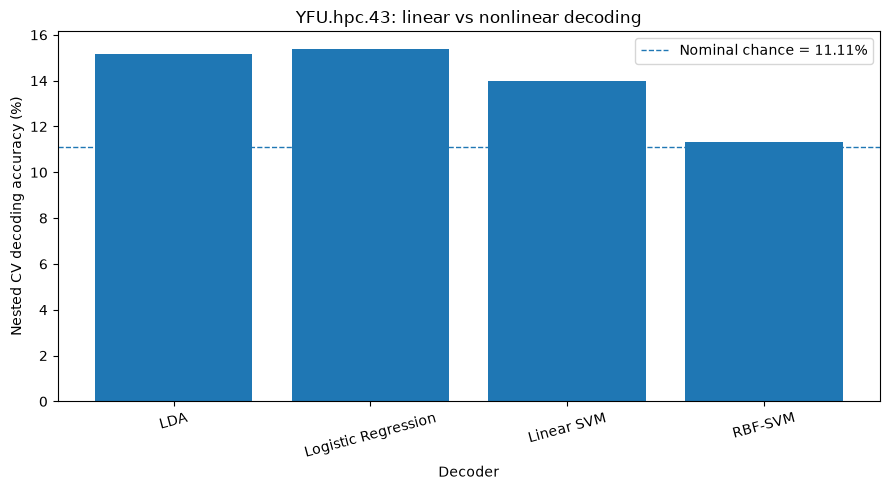


Saved:
C:\Users\shafi\number-simplex-reproduction\tables1\YFU_hpc43_four_decoder_nested_cv_summary.csv
C:\Users\shafi\number-simplex-reproduction\tables1\YFU_hpc43_four_decoder_nested_cv_folds.csv
C:\Users\shafi\number-simplex-reproduction\tables1\YFU_hpc43_four_decoder_nested_cv_predictions.csv


In [44]:
# ============================================================
# YFU.HPC.43
# FOUR INDEPENDENT DECODERS WITH NESTED CROSS-VALIDATION
#
# Linear:
#   1. LDA
#   2. Logistic Regression
#   3. Linear SVM
#
# Nonlinear:
#   4. RBF-SVM
#
# IMPORTANT:
# Each decoder independently selects:
#
#   LDA:
#       bin + gamma
#
#   Logistic:
#       bin + C
#
#   Linear SVM:
#       bin + C
#
#   RBF-SVM:
#       bin + C + RBF gamma
#
# Selection happens ONLY inside outer training data.
# Final accuracy is measured on untouched outer test data.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

from src.firing_rate_tuning import analyze_neuron
from src.number_decoding_analysis import make_temporal_features


# ============================================================
# 1. SETTINGS
# ============================================================

SUBJECT = "YFU"

# IMPORTANT:
# analyze_neuron expects the MATLAB/stored neuron number directly.
NEURON = 43


BIN_SIZES = [
    60, 75, 90, 100, 150,
    180, 225, 300, 450, 900
]


LDA_GAMMAS = [
    0.2,
    0.5,
    0.8,
]


C_VALUES = [
    0.01,
    0.1,
    1.0,
    10.0,
    100.0,
]


RBF_GAMMAS = [
    "scale",
    0.001,
    0.01,
    0.1,
    1.0,
]


MAX_OUTER_SPLITS = 10
MAX_INNER_SPLITS = 5

RANDOM_STATE = 42


DECODERS = [
    "LDA",
    "Logistic Regression",
    "Linear SVM",
    "RBF-SVM",
]


# ============================================================
# 2. LOAD YFU.HPC.43
# ============================================================

print("=" * 80)
print("YFU.HPC.43")
print("FOUR-DECODER NESTED CROSS-VALIDATION")
print("=" * 80)


result = analyze_neuron(
    SUBJECT,
    NEURON,
    root=ROOT,
    plot=False,
    verbose=False,
)


presentations = result[
    "presentations"
]

spike_times = result[
    "spike_times"
]


# ============================================================
# 3. BUILD ALL TEMPORAL REPRESENTATIONS ONCE
# ============================================================
#
# We build every candidate representation.
#
# This does NOT leak information because the spike counts
# themselves are computed independently of the labels/model.
#
# Model selection will still happen ONLY on outer training data.
# ============================================================

features_by_bin = {}

reference_y = None


for bin_size in BIN_SIZES:

    X, y_bin, _ = make_temporal_features(
        presentations,
        spike_times,
        bin_size=bin_size,
    )


    if reference_y is None:

        reference_y = (
            y_bin.copy()
        )

    else:

        if not np.array_equal(
            reference_y,
            y_bin,
        ):

            raise ValueError(
                "Labels differ between temporal bin sizes."
            )


    features_by_bin[
        bin_size
    ] = X


y = reference_y


print()
print(
    "Presentations:",
    len(y)
)

print(
    "Classes:",
    np.unique(y)
)


classes, counts = np.unique(
    y,
    return_counts=True,
)


class_table = pd.DataFrame({
    "number": classes,
    "n_presentations": counts,
})


print()
display(
    class_table
)


# ============================================================
# 4. MODEL BUILDERS
# ============================================================

def make_lda(gamma):

    return LinearDiscriminantAnalysis(
        solver="lsqr",
        shrinkage=gamma,
        priors=np.ones(9) / 9,
    )


def make_logistic(C):

    return Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                C=C,
                l1_ratio=0,
                solver="lbfgs",
                max_iter=5000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )
        ),
    ])


def make_linear_svm(C):

    return Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            SVC(
                kernel="linear",
                C=C,
                class_weight="balanced",
            )
        ),
    ])


def make_rbf_svm(
    C,
    gamma,
):

    return Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            SVC(
                kernel="rbf",
                C=C,
                gamma=gamma,
                class_weight="balanced",
            )
        ),
    ])


# ============================================================
# 5. INNER CV ACCURACY
# ============================================================
#
# Evaluate ONE candidate model on the OUTER TRAINING SET.
#
# X supplied here contains only outer-training observations.
# ============================================================

def inner_cv_accuracy(
    model,
    X,
    y_train,
    inner_splits,
):

    predictions = np.empty_like(
        y_train
    )


    for train_idx, validation_idx in inner_splits:

        fold_model = clone(
            model
        )


        fold_model.fit(
            X[train_idx],
            y_train[train_idx],
        )


        predictions[
            validation_idx
        ] = fold_model.predict(
            X[validation_idx]
        )


    return np.mean(
        predictions == y_train
    )


# ============================================================
# 6. SEARCH ONE DECODER INSIDE ONE OUTER TRAINING FOLD
# ============================================================
#
# This is the critical function.
#
# Every decoder independently searches its OWN:
#
#       temporal bin
#       hyperparameter(s)
#
# using ONLY the outer training observations.
# ============================================================

def search_decoder_inner(
    decoder_name,
    outer_train_idx,
    y,
    features_by_bin,
    inner_splits,
):

    y_train = y[
        outer_train_idx
    ]


    search_rows = []


    # ========================================================
    # LDA
    # ========================================================

    if decoder_name == "LDA":

        for bin_size in BIN_SIZES:

            X_train = features_by_bin[
                bin_size
            ][
                outer_train_idx
            ]


            for gamma in LDA_GAMMAS:

                model = make_lda(
                    gamma
                )


                accuracy = inner_cv_accuracy(
                    model,
                    X_train,
                    y_train,
                    inner_splits,
                )


                search_rows.append({

                    "decoder":
                        decoder_name,

                    "bin_ms":
                        bin_size,

                    "parameter_1_name":
                        "gamma",

                    "parameter_1":
                        gamma,

                    "parameter_2_name":
                        None,

                    "parameter_2":
                        None,

                    "inner_accuracy":
                        accuracy,
                })


    # ========================================================
    # LOGISTIC REGRESSION
    # ========================================================

    elif decoder_name == "Logistic Regression":

        for bin_size in BIN_SIZES:

            X_train = features_by_bin[
                bin_size
            ][
                outer_train_idx
            ]


            for C in C_VALUES:

                model = make_logistic(
                    C
                )


                accuracy = inner_cv_accuracy(
                    model,
                    X_train,
                    y_train,
                    inner_splits,
                )


                search_rows.append({

                    "decoder":
                        decoder_name,

                    "bin_ms":
                        bin_size,

                    "parameter_1_name":
                        "C",

                    "parameter_1":
                        C,

                    "parameter_2_name":
                        None,

                    "parameter_2":
                        None,

                    "inner_accuracy":
                        accuracy,
                })


    # ========================================================
    # LINEAR SVM
    # ========================================================

    elif decoder_name == "Linear SVM":

        for bin_size in BIN_SIZES:

            X_train = features_by_bin[
                bin_size
            ][
                outer_train_idx
            ]


            for C in C_VALUES:

                model = make_linear_svm(
                    C
                )


                accuracy = inner_cv_accuracy(
                    model,
                    X_train,
                    y_train,
                    inner_splits,
                )


                search_rows.append({

                    "decoder":
                        decoder_name,

                    "bin_ms":
                        bin_size,

                    "parameter_1_name":
                        "C",

                    "parameter_1":
                        C,

                    "parameter_2_name":
                        None,

                    "parameter_2":
                        None,

                    "inner_accuracy":
                        accuracy,
                })


    # ========================================================
    # NONLINEAR RBF-SVM
    # ========================================================

    elif decoder_name == "RBF-SVM":

        for bin_size in BIN_SIZES:

            X_train = features_by_bin[
                bin_size
            ][
                outer_train_idx
            ]


            for C in C_VALUES:

                for gamma in RBF_GAMMAS:

                    model = make_rbf_svm(
                        C,
                        gamma,
                    )


                    accuracy = inner_cv_accuracy(
                        model,
                        X_train,
                        y_train,
                        inner_splits,
                    )


                    search_rows.append({

                        "decoder":
                            decoder_name,

                        "bin_ms":
                            bin_size,

                        "parameter_1_name":
                            "C",

                        "parameter_1":
                            C,

                        "parameter_2_name":
                            "gamma",

                        "parameter_2":
                            gamma,

                        "inner_accuracy":
                            accuracy,
                    })


    else:

        raise ValueError(
            f"Unknown decoder: {decoder_name}"
        )


    search_df = pd.DataFrame(
        search_rows
    )


    # ========================================================
    # DETERMINISTIC TIE BREAK
    # ========================================================
    #
    # Primary criterion:
    #       highest inner CV accuracy
    #
    # Secondary:
    #       smaller temporal bin
    #
    # Then preserve deterministic search order.
    # ========================================================

    search_df[
        "_search_order"
    ] = np.arange(
        len(search_df)
    )


    search_df = search_df.sort_values(
        [
            "inner_accuracy",
            "bin_ms",
            "_search_order",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )


    best = search_df.iloc[0]


    return (
        best,
        search_df
    )


# ============================================================
# 7. BUILD MODEL FROM SELECTED SETTINGS
# ============================================================

def build_selected_model(
    decoder_name,
    best,
):

    if decoder_name == "LDA":

        return make_lda(
            float(
                best["parameter_1"]
            )
        )


    elif decoder_name == "Logistic Regression":

        return make_logistic(
            float(
                best["parameter_1"]
            )
        )


    elif decoder_name == "Linear SVM":

        return make_linear_svm(
            float(
                best["parameter_1"]
            )
        )


    elif decoder_name == "RBF-SVM":

        C = float(
            best["parameter_1"]
        )

        gamma = best[
            "parameter_2"
        ]


        if gamma != "scale":

            gamma = float(
                gamma
            )


        return make_rbf_svm(
            C,
            gamma,
        )


    else:

        raise ValueError(
            f"Unknown decoder: {decoder_name}"
        )


# ============================================================
# 8. OUTER CROSS-VALIDATION
# ============================================================
#
# Same outer held-out trials for all four decoders.
#
# But INSIDE each outer training fold:
#
#       each decoder performs its OWN model search.
#
# ============================================================

min_class_count = int(
    counts.min()
)


n_outer_splits = min(
    MAX_OUTER_SPLITS,
    min_class_count,
)


if n_outer_splits < 2:

    raise ValueError(
        "Not enough observations for outer CV."
    )


print()
print(
    "Outer CV folds:",
    n_outer_splits
)


outer_cv = StratifiedKFold(
    n_splits=n_outer_splits,
    shuffle=True,
    random_state=RANDOM_STATE,
)


outer_splits = list(
    outer_cv.split(
        np.zeros(len(y)),
        y,
    )
)


# ============================================================
# 9. STORAGE
# ============================================================

predictions = {

    decoder:
        np.empty_like(y)

    for decoder in DECODERS
}


fold_results = []

start_time = time.time()


# ============================================================
# 10. NESTED CV LOOP
# ============================================================

for outer_fold, (
    outer_train_idx,
    outer_test_idx,
) in enumerate(
    outer_splits,
    start=1,
):


    print()
    print("=" * 80)
    print(
        f"OUTER FOLD "
        f"{outer_fold}/{n_outer_splits}"
    )
    print("=" * 80)


    y_outer_train = y[
        outer_train_idx
    ]


    # ========================================================
    # INNER FOLD COUNT
    # ========================================================

    inner_classes, inner_counts = np.unique(
        y_outer_train,
        return_counts=True,
    )


    n_inner_splits = min(
        MAX_INNER_SPLITS,
        int(
            inner_counts.min()
        ),
    )


    if n_inner_splits < 2:

        raise ValueError(
            "Not enough observations for inner CV."
        )


    # ========================================================
    # COMMON INNER SPLITS
    # ========================================================
    #
    # Same validation partitions for all four decoders.
    #
    # This does NOT couple their model selection.
    #
    # Each decoder still independently searches its own
    # representation and hyperparameters.
    # ========================================================

    inner_cv = StratifiedKFold(
        n_splits=n_inner_splits,
        shuffle=True,
        random_state=(
            RANDOM_STATE
            + outer_fold
        ),
    )


    inner_splits = list(
        inner_cv.split(
            np.zeros(
                len(y_outer_train)
            ),
            y_outer_train,
        )
    )


    # ========================================================
    # RUN EACH DECODER INDEPENDENTLY
    # ========================================================

    for decoder_name in DECODERS:


        # ----------------------------------------------------
        # INDEPENDENT INNER SEARCH
        # ----------------------------------------------------

        best, search_table = (
            search_decoder_inner(
                decoder_name,
                outer_train_idx,
                y,
                features_by_bin,
                inner_splits,
            )
        )


        selected_bin = int(
            best["bin_ms"]
        )


        # ----------------------------------------------------
        # GET THIS DECODER'S OWN SELECTED REPRESENTATION
        # ----------------------------------------------------

        X_selected = features_by_bin[
            selected_bin
        ]


        X_outer_train = X_selected[
            outer_train_idx
        ]

        X_outer_test = X_selected[
            outer_test_idx
        ]


        # ----------------------------------------------------
        # BUILD THIS DECODER'S OWN SELECTED MODEL
        # ----------------------------------------------------

        final_model = build_selected_model(
            decoder_name,
            best,
        )


        # ----------------------------------------------------
        # TRAIN ONLY ON OUTER TRAINING DATA
        # ----------------------------------------------------

        final_model.fit(
            X_outer_train,
            y_outer_train,
        )


        # ----------------------------------------------------
        # TEST ON UNTOUCHED OUTER TEST DATA
        # ----------------------------------------------------

        fold_predictions = (
            final_model.predict(
                X_outer_test
            )
        )


        predictions[
            decoder_name
        ][
            outer_test_idx
        ] = fold_predictions


        fold_accuracy = np.mean(
            fold_predictions
            ==
            y[
                outer_test_idx
            ]
        )


        # ----------------------------------------------------
        # STORE
        # ----------------------------------------------------

        fold_results.append({

            "outer_fold":
                outer_fold,

            "decoder":
                decoder_name,

            "n_train":
                len(
                    outer_train_idx
                ),

            "n_test":
                len(
                    outer_test_idx
                ),

            "inner_folds":
                n_inner_splits,

            "selected_bin_ms":
                selected_bin,

            "parameter_1_name":
                best[
                    "parameter_1_name"
                ],

            "parameter_1":
                best[
                    "parameter_1"
                ],

            "parameter_2_name":
                best[
                    "parameter_2_name"
                ],

            "parameter_2":
                best[
                    "parameter_2"
                ],

            "inner_cv_accuracy":
                best[
                    "inner_accuracy"
                ],

            "outer_accuracy":
                fold_accuracy,
        })


        # ----------------------------------------------------
        # PRINT SELECTION
        # ----------------------------------------------------

        if decoder_name == "RBF-SVM":

            print(
                f"{decoder_name:<22} | "
                f"bin={selected_bin:>3} ms | "
                f"C={best['parameter_1']} | "
                f"gamma={best['parameter_2']} | "
                f"inner="
                f"{100*best['inner_accuracy']:.2f}% | "
                f"outer="
                f"{100*fold_accuracy:.2f}%"
            )


        else:

            print(
                f"{decoder_name:<22} | "
                f"bin={selected_bin:>3} ms | "
                f"{best['parameter_1_name']}="
                f"{best['parameter_1']} | "
                f"inner="
                f"{100*best['inner_accuracy']:.2f}% | "
                f"outer="
                f"{100*fold_accuracy:.2f}%"
            )


# ============================================================
# 11. FINAL OUTER-CV ACCURACY
# ============================================================

final_rows = []


for decoder_name in DECODERS:

    accuracy = np.mean(
        predictions[
            decoder_name
        ]
        ==
        y
    )


    final_rows.append({

        "decoder":
            decoder_name,

        "nested_cv_accuracy":
            accuracy,

        "nested_cv_accuracy_pct":
            100 * accuracy,

        "correct":
            np.sum(
                predictions[
                    decoder_name
                ]
                ==
                y
            ),

        "total":
            len(y),
    })


summary = pd.DataFrame(
    final_rows
)


# ============================================================
# 12. RESULTS
# ============================================================

elapsed = (
    time.time()
    - start_time
)


print()
print("=" * 80)
print("FINAL NESTED-CV RESULTS")
print("=" * 80)

display(
    summary.round(3)
)


print(
    f"Runtime: "
    f"{elapsed/60:.2f} minutes"
)


# ============================================================
# 13. OUTER-FOLD DETAILS
# ============================================================

fold_results_df = pd.DataFrame(
    fold_results
)


print()
print("=" * 80)
print("SELECTED SETTINGS IN EACH OUTER FOLD")
print("=" * 80)

display(
    fold_results_df
)


# ============================================================
# 14. SELECTED BIN FREQUENCY
# ============================================================
#
# With nested CV there is NOT necessarily one global
# "best bin".
#
# Every outer training fold can select a different bin.
# ============================================================

bin_selection = (
    fold_results_df
    .groupby(
        [
            "decoder",
            "selected_bin_ms",
        ]
    )
    .size()
    .reset_index(
        name="n_outer_folds"
    )
)


print()
print("=" * 80)
print("TEMPORAL BIN SELECTION FREQUENCY")
print("=" * 80)

display(
    bin_selection
)


# ============================================================
# 15. PREDICTION AGREEMENT
# ============================================================

prediction_table = pd.DataFrame({

    "true_number":
        y,

    "LDA":
        predictions["LDA"],

    "Logistic Regression":
        predictions[
            "Logistic Regression"
        ],

    "Linear SVM":
        predictions[
            "Linear SVM"
        ],

    "RBF-SVM":
        predictions[
            "RBF-SVM"
        ],
})


prediction_table[
    "n_decoders_correct"
] = (

    (
        prediction_table["LDA"]
        ==
        prediction_table["true_number"]
    ).astype(int)

    +

    (
        prediction_table[
            "Logistic Regression"
        ]
        ==
        prediction_table[
            "true_number"
        ]
    ).astype(int)

    +

    (
        prediction_table[
            "Linear SVM"
        ]
        ==
        prediction_table[
            "true_number"
        ]
    ).astype(int)

    +

    (
        prediction_table[
            "RBF-SVM"
        ]
        ==
        prediction_table[
            "true_number"
        ]
    ).astype(int)
)


print()
print("=" * 80)
print("PREDICTION AGREEMENT")
print("=" * 80)

display(
    prediction_table.head(20)
)


# ============================================================
# 16. PLOT FINAL NESTED-CV ACCURACY
# ============================================================

plt.figure(
    figsize=(9, 5)
)


plt.bar(
    summary[
        "decoder"
    ],
    summary[
        "nested_cv_accuracy_pct"
    ],
)


plt.axhline(
    100 / 9,
    linestyle="--",
    linewidth=1,
    label="Nominal chance = 11.11%",
)


plt.ylabel(
    "Nested CV decoding accuracy (%)"
)

plt.xlabel(
    "Decoder"
)

plt.title(
    "YFU.hpc.43: linear vs nonlinear decoding"
)

plt.xticks(
    rotation=15
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 17. SAVE RESULTS
# ============================================================

SUMMARY_FILE = (
    TABLES_DIR /
    "YFU_hpc43_four_decoder_nested_cv_summary.csv"
)

FOLD_FILE = (
    TABLES_DIR /
    "YFU_hpc43_four_decoder_nested_cv_folds.csv"
)

PREDICTION_FILE = (
    TABLES_DIR /
    "YFU_hpc43_four_decoder_nested_cv_predictions.csv"
)


summary.to_csv(
    SUMMARY_FILE,
    index=False,
)

fold_results_df.to_csv(
    FOLD_FILE,
    index=False,
)

prediction_table.to_csv(
    PREDICTION_FILE,
    index=False,
)


print()
print("Saved:")
print(SUMMARY_FILE)
print(FOLD_FILE)
print(PREDICTION_FILE)